Variasi c1, c2, w
Variasi jumlah partikel
Variasi kapasitas baterai
Variasi ketika mataharinya bergerak dan tidak bergerak

massa baterai yang dipakai yaitu variasi 7 kg dan massa panel surya variasi 5, 15, 30

### Percobaan Pertama
c1 = 1

c2 = 1,5

w = 0,5

jumlah partikel = 30

massa drone = 2,5

kapasitas baterai = 5000

Iterasi ke-1: Global Best Fitness = -0.998149454432735
Iterasi ke-2: Global Best Fitness = -0.9981494672254977
Iterasi ke-3: Global Best Fitness = -0.9981494800062265
Iterasi ke-4: Global Best Fitness = -0.9981494927749215
Iterasi ke-5: Global Best Fitness = -0.9981495055315827
Iterasi ke-6: Global Best Fitness = -0.9981495182762099
Iterasi ke-7: Global Best Fitness = -0.9981495310088033
Iterasi ke-8: Global Best Fitness = -0.9981495437293629
Iterasi ke-9: Global Best Fitness = -0.9981495564378886
Iterasi ke-10: Global Best Fitness = -0.9981495691343805
Iterasi ke-11: Global Best Fitness = -0.9981495818188385
Iterasi ke-12: Global Best Fitness = -0.9981495944912626
Iterasi ke-13: Global Best Fitness = -0.9984063784165318
Iterasi ke-14: Global Best Fitness = -0.9984677869016767
Iterasi ke-15: Global Best Fitness = -0.9986466585241226
Iterasi ke-16: Global Best Fitness = -0.9987460394530152
Iterasi ke-17: Global Best Fitness = -0.9987694732666546
Iterasi ke-18: Global Best Fitness = -0.9

<Figure size 640x480 with 0 Axes>

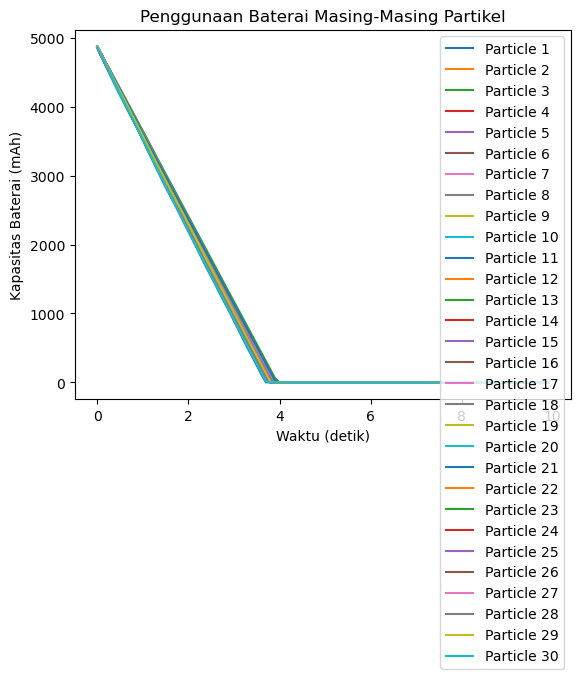

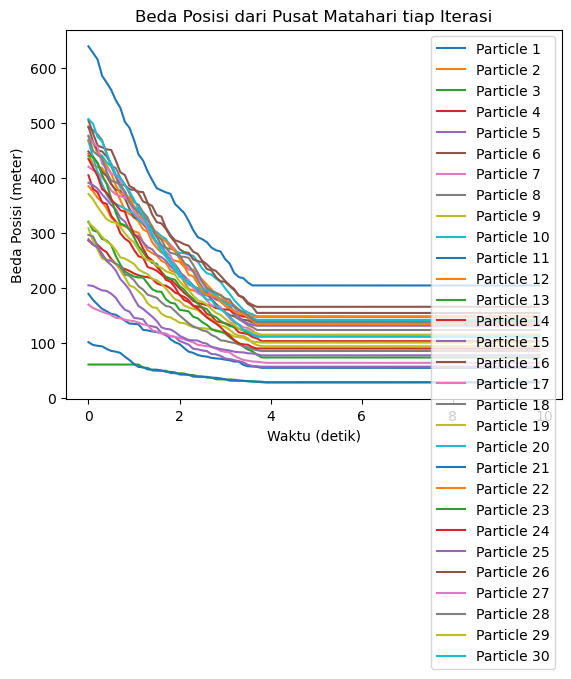

Posisi global terbaik: [491.19544265 472.9744717 ]
Kapasitas baterai akhir dan persentasenya: 
Drone 1: Kapasitas baterai = 0.002773619928318756 mAh (5.5472398566375115e-05%)
Drone 2: Kapasitas baterai = 0.0027535102444544383 mAh (5.507020488908877e-05%)
Drone 3: Kapasitas baterai = 0.0027766473540947758 mAh (5.5532947081895516e-05%)
Drone 4: Kapasitas baterai = 0.0027629985800162156 mAh (5.525997160032431e-05%)
Drone 5: Kapasitas baterai = 0.0027732572551743295 mAh (5.546514510348659e-05%)
Drone 6: Kapasitas baterai = 0.0027518395910123357 mAh (5.503679182024672e-05%)
Drone 7: Kapasitas baterai = 0.002747305373576432 mAh (5.4946107471528644e-05%)
Drone 8: Kapasitas baterai = 0.0027566380858175597 mAh (5.5132761716351195e-05%)
Drone 9: Kapasitas baterai = 0.0027636829217748825 mAh (5.527365843549765e-05%)
Drone 10: Kapasitas baterai = 0.002747888268189879 mAh (5.495776536379758e-05%)
Drone 11: Kapasitas baterai = 0.0027202453819799442 mAh (5.440490763959889e-05%)
Drone 12: Kapasitas ba

In [4]:
import os
import numpy as np
import matplotlib.pyplot as plt

def gauss_sun_intensity(x, y, sun_center, sun_std_dev):
    """Intensitas Gaussian berdasarkan jarak dari titik tengah."""
    return np.exp(-((x - sun_center[0])**2 + (y - sun_center[1])**2) / (2 * sun_std_dev**2))

def fitness_function(pos, sun_center, sun_std_dev, particles, index, min_distance, repulsion_factor):
    """Fitness function untuk memaksimalkan intensitas cahaya dan meminimalkan repulsi."""
    sun_intensity = gauss_sun_intensity(pos[0], pos[1], sun_center, sun_std_dev)

    repulsion = 0
    for j in range(len(particles)):
        if j != index:
            distance = np.linalg.norm(pos - particles[j])
            if distance < min_distance:
                repulsion += repulsion_factor / distance**2

    fitness = -sun_intensity + repulsion
    return fitness

def calculate_energy_consumption(mass, altitude, horizontal_distance, battery_voltage):
    """Menghitung parameter energi dari setiap drone."""
    drag_coefficient = 0.5
    frontal_area = 0.1  
    air_density = 1.225  
    horizontal_speed = 10.0  
    flight_efficiency = 0.8

    E_vertical_J = mass * 9.81 * altitude
    P_drag = 0.5 * drag_coefficient * frontal_area * air_density * horizontal_speed**2
    P_horizontal = (P_drag + mass * 9.81 * horizontal_speed) / flight_efficiency
    E_horizontal_J = P_horizontal * (horizontal_distance / horizontal_speed)
    E_total_J = E_vertical_J + E_horizontal_J
    E_total_Wh = E_total_J / 3600
    energy_consumed = (E_total_Wh * 1000) / battery_voltage
    return energy_consumed

def pso_drone_solar_chaser_with_battery():
    num_particles = 30
    num_iterations = 100
    dim = 2  
    c1 = 1.0
    c2 = 1.5  
    w = 0.1  
    timestep = 0.1  # seconds
    L = 1000  # meters

    drone_mass = 2.5 # massa baterai + massa panel surya (massa baterai yang dipakai yaitu variasi 7 kg dan massa panel surya variasi 5, 15, 30 ) 
    battery_capacity = 5000  
    solar_charge_rate = 100  
    altitude = 200  
    battery_voltage = 11.1  

    sun_center = np.array([L / 2, L / 2])  
    sun_std_dev = 1000  
    sun_speed = 1000 / 28800  # 1 km per 8 jam dalam meters per second

    min_distance = 3  
    repulsion_factor = 1000  

    particles = np.random.rand(num_particles, dim) * L  
    velocities = np.zeros((num_particles, dim))  
    personal_best_positions = particles.copy()
    global_best_position = particles[0, :].copy()
    global_best_fitness = float('inf')

    battery_levels = battery_capacity * np.ones(num_particles)  

    battery_levels_over_time = np.zeros((num_iterations, num_particles))
    position_diff_over_time = np.zeros((num_iterations, num_particles))

    # Folder untuk menyimpan hasil program
    folder_name = "Percobaan_111"
    if not os.path.exists(folder_name):
        os.makedirs(folder_name)

    for iter in range(num_iterations):
        for i in range(num_particles):
            fitness = fitness_function(particles[i, :], sun_center, sun_std_dev, particles, i, min_distance, repulsion_factor)
            if fitness < fitness_function(personal_best_positions[i, :], sun_center, sun_std_dev, particles, i, min_distance, repulsion_factor):
                personal_best_positions[i, :] = particles[i, :]
            if fitness < global_best_fitness:
                global_best_fitness = fitness
                global_best_position = particles[i, :]

        for i in range(num_particles):
            velocities[i, :] = (w * velocities[i, :] +
                                c1 * np.random.rand() * (personal_best_positions[i, :] - particles[i, :]) +
                                c2 * np.random.rand() * (global_best_position - particles[i, :]) / drone_mass * timestep)
            new_position = particles[i, :] + velocities[i, :]  
            new_position = np.clip(new_position, 0, L)
            horizontal_distance = np.linalg.norm(new_position - particles[i, :])
            energy_consumed = calculate_energy_consumption(drone_mass, altitude, horizontal_distance, battery_voltage)
            battery_levels[i] -= energy_consumed
            if battery_levels[i] > 0:
                particles[i, :] = new_position
            else:
                battery_levels[i] = 0

        for i in range(num_particles):
            solar_energy = (solar_charge_rate * 
                            max(0, gauss_sun_intensity(particles[i, 0], particles[i, 1], sun_center, sun_std_dev)) * 
                            timestep / 3600)
            battery_levels[i] = min(battery_levels[i] + solar_energy, battery_capacity)

        battery_levels_over_time[iter, :] = battery_levels
        position_diff_over_time[iter, :] = np.linalg.norm(particles - sun_center, axis=1)

        sun_center[0] += sun_speed * timestep  

        if sun_center[0] > L:
            sun_center[0] = 0

        X, Y = np.meshgrid(np.arange(0, L+1, 10), np.arange(0, L+1, 10))  
        Z = np.array([[gauss_sun_intensity(x, y, sun_center, sun_std_dev) for x in np.arange(0, L+1, 10)] for y in np.arange(0, L+1, 10)])
        
        plt.contourf(X, Y, Z)  
        plt.colorbar()
        plt.clim(0, 1)
        plt.title('Distribusi Matahari')
        plt.plot(particles[:, 0], particles[:, 1], '.r')
        plt.savefig(f'{folder_name}/frame_{iter+1}.png')  
        plt.clf()

        print(f'Iterasi ke-{iter + 1}: Global Best Fitness = {global_best_fitness}')

    time = np.arange(num_iterations) * timestep 
    
    plt.figure()
    for i in range(num_particles):
        plt.plot(time, battery_levels_over_time[:, i], label=f'Particle {i+1}')
    plt.title('Penggunaan Baterai Masing-Masing Partikel')
    plt.xlabel('Waktu (detik)')
    plt.ylabel('Kapasitas Baterai (mAh)')
    plt.legend(loc='best')
    plt.savefig(f'{folder_name}/Kapasitas Baterai Tiap Waktu.png')  
    plt.show()
    
    plt.figure()
    for i in range(num_particles):
        plt.plot(time, position_diff_over_time[:, i], label=f'Particle {i+1}')
    plt.title('Beda Posisi dari Pusat Matahari tiap Waktu')
    plt.xlabel('Waktu (detik)')
    plt.ylabel('Beda Posisi (meter)')
    plt.legend(loc='best')
    plt.savefig(f'{folder_name}/beda_posisi tiap waktu.png')  
    plt.show()


    print(f'Posisi global terbaik: {global_best_position}')
    print('Kapasitas baterai akhir dan persentasenya: ')
    for i in range(num_particles):
        battery_percentage = (battery_levels[i] / battery_capacity) * 100
        print(f'Drone {i + 1}: Kapasitas baterai = {battery_levels[i]} mAh ({battery_percentage}%)')

if __name__ == "__main__":
    pso_drone_solar_chaser_with_battery()


### Percobaan kedua
#### Variasi c1, c2, w
Nilai c1, c2 dan w memengaruhi seberapa cepat partikel dapat sampai ke daerah yang diinginkan 

Variasi c1 dan c2 berubah sementara w tetap

Percobaan 1.1 Nilai c1 = 0.1 dan c2 = 1 w = 0.1

Percobaan 1.2 Nilai c1 = 1 dan c2 = 10 w = 0.1

Percobaan 1.3 Nilai c1 = 10 dan c2 = 1 w = 0.1
 
Percobaan 1.4 Nilai c1 = 10 dan c2 = 10 w = 0.1

Percobaan 1.5 Nilai c1 = 5 dan c2 = 5 w = 0.1

#### Nilai c1 = 0.1 dan c2 = 1 massa 2,5 dan jumlah drone 30

Iterasi ke-1: Global Best Fitness = -0.9989153014860144
Iterasi ke-2: Global Best Fitness = -0.9989153014860144
Iterasi ke-3: Global Best Fitness = -0.9989153014860144
Iterasi ke-4: Global Best Fitness = -0.9989153014860144
Iterasi ke-5: Global Best Fitness = -0.9989153014860144
Iterasi ke-6: Global Best Fitness = -0.9989153014860144
Iterasi ke-7: Global Best Fitness = -0.9989153014860144
Iterasi ke-8: Global Best Fitness = -0.9989153014860144
Iterasi ke-9: Global Best Fitness = -0.9989153014860144
Iterasi ke-10: Global Best Fitness = -0.9989153014860144
Iterasi ke-11: Global Best Fitness = -0.9989153014860144
Iterasi ke-12: Global Best Fitness = -0.9989153014860144
Iterasi ke-13: Global Best Fitness = -0.9989153014860144
Iterasi ke-14: Global Best Fitness = -0.9989153014860144
Iterasi ke-15: Global Best Fitness = -0.9989159259303032
Iterasi ke-16: Global Best Fitness = -0.9989207232415412
Iterasi ke-17: Global Best Fitness = -0.9989289637594528
Iterasi ke-18: Global Best Fitness = -0.

<Figure size 640x480 with 0 Axes>

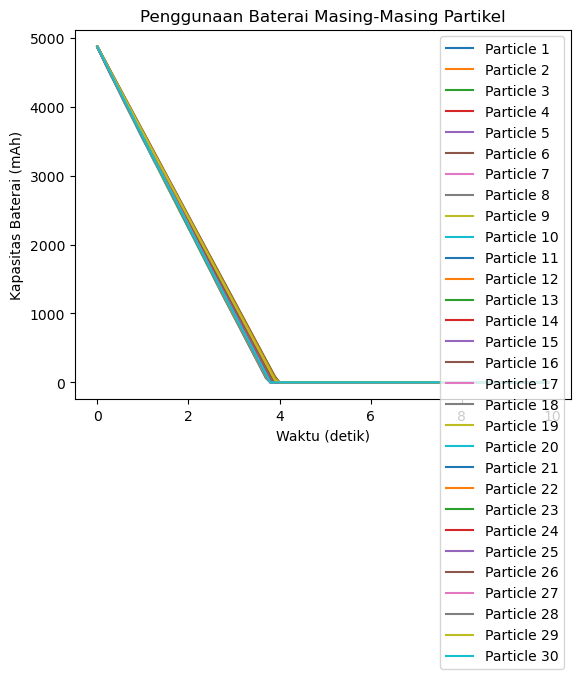

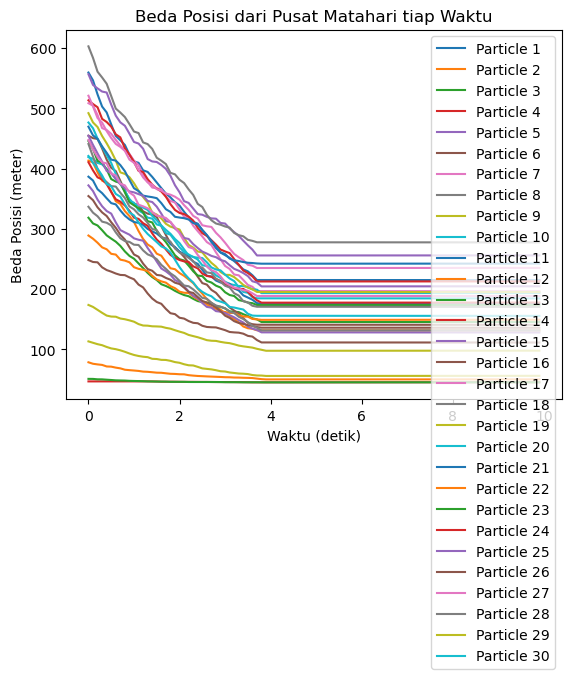

Posisi global terbaik: [471.52247071 465.25819178]
Kapasitas baterai akhir dan persentasenya: 
Drone 1: Kapasitas baterai = 0.002714385455466442 mAh (5.428770910932884e-05%)
Drone 2: Kapasitas baterai = 0.002753939811022489 mAh (5.5078796220449785e-05%)
Drone 3: Kapasitas baterai = 0.0027486081354508776 mAh (5.497216270901755e-05%)
Drone 4: Kapasitas baterai = 0.0027749403764018967 mAh (5.549880752803794e-05%)
Drone 5: Kapasitas baterai = 0.002688310466663416 mAh (5.3766209333268317e-05%)
Drone 6: Kapasitas baterai = 0.002750462023148225 mAh (5.5009240462964503e-05%)
Drone 7: Kapasitas baterai = 0.0027247116764482224 mAh (5.449423352896445e-05%)
Drone 8: Kapasitas baterai = 0.0026728786269424156 mAh (5.3457572538848315e-05%)
Drone 9: Kapasitas baterai = 0.0027734481417882725 mAh (5.546896283576545e-05%)
Drone 10: Kapasitas baterai = 0.00272633624136085 mAh (5.4526724827217e-05%)
Drone 11: Kapasitas baterai = 0.0027354466253450734 mAh (5.470893250690147e-05%)
Drone 12: Kapasitas baterai

In [10]:
import os
import numpy as np
import matplotlib.pyplot as plt

def gauss_sun_intensity(x, y, sun_center, sun_std_dev):
    """Intensitas Gaussian berdasarkan jarak dari titik tengah."""
    return np.exp(-((x - sun_center[0])**2 + (y - sun_center[1])**2) / (2 * sun_std_dev**2))

def fitness_function(pos, sun_center, sun_std_dev, particles, index, min_distance, repulsion_factor):
    """Fitness function untuk memaksimalkan intensitas cahaya dan meminimalkan repulsi."""
    sun_intensity = gauss_sun_intensity(pos[0], pos[1], sun_center, sun_std_dev)

    repulsion = 0
    for j in range(len(particles)):
        if j != index:
            distance = np.linalg.norm(pos - particles[j])
            if distance < min_distance:
                repulsion += repulsion_factor / distance**2

    fitness = -sun_intensity + repulsion
    return fitness

def calculate_energy_consumption(mass, altitude, horizontal_distance, battery_voltage):
    """Menghitung parameter energi dari setiap drone."""
    drag_coefficient = 0.5
    frontal_area = 0.1  
    air_density = 1.225  
    horizontal_speed = 10.0  
    flight_efficiency = 0.8

    E_vertical_J = mass * 9.81 * altitude
    P_drag = 0.5 * drag_coefficient * frontal_area * air_density * horizontal_speed**2
    P_horizontal = (P_drag + mass * 9.81 * horizontal_speed) / flight_efficiency
    E_horizontal_J = P_horizontal * (horizontal_distance / horizontal_speed)
    E_total_J = E_vertical_J + E_horizontal_J
    E_total_Wh = E_total_J / 3600
    energy_consumed = (E_total_Wh * 1000) / battery_voltage
    return energy_consumed

def pso_drone_solar_chaser_with_battery():
    num_particles = 30
    num_iterations = 100
    dim = 2  
    c1 = 0.1
    c2 = 1.0 
    w = 0.1  
    timestep = 0.1  # seconds
    L = 1000  # meters

    drone_mass = 2.5 # massa baterai + massa panel surya (massa baterai yang dipakai yaitu variasi 7 kg dan massa panel surya variasi 5, 15, 30 ) 
    battery_capacity = 5000  
    solar_charge_rate = 100  
    altitude = 200  
    battery_voltage = 11.1  

    sun_center = np.array([L / 2, L / 2])  
    sun_std_dev = 1000  
    sun_speed = 1000 / 28800  # 1 km per 8 jam dalam meters per second

    min_distance = 3  
    repulsion_factor = 1000  

    particles = np.random.rand(num_particles, dim) * L  
    velocities = np.zeros((num_particles, dim))  
    personal_best_positions = particles.copy()
    global_best_position = particles[0, :].copy()
    global_best_fitness = float('inf')

    battery_levels = battery_capacity * np.ones(num_particles)  

    battery_levels_over_time = np.zeros((num_iterations, num_particles))
    position_diff_over_time = np.zeros((num_iterations, num_particles))

    # Folder untuk menyimpan hasil program
    folder_name = "Percobaan_211"
    if not os.path.exists(folder_name):
        os.makedirs(folder_name)

    for iter in range(num_iterations):
        for i in range(num_particles):
            fitness = fitness_function(particles[i, :], sun_center, sun_std_dev, particles, i, min_distance, repulsion_factor)
            if fitness < fitness_function(personal_best_positions[i, :], sun_center, sun_std_dev, particles, i, min_distance, repulsion_factor):
                personal_best_positions[i, :] = particles[i, :]
            if fitness < global_best_fitness:
                global_best_fitness = fitness
                global_best_position = particles[i, :]

        for i in range(num_particles):
            velocities[i, :] = (w * velocities[i, :] +
                                c1 * np.random.rand() * (personal_best_positions[i, :] - particles[i, :]) +
                                c2 * np.random.rand() * (global_best_position - particles[i, :]) / drone_mass * timestep)
            new_position = particles[i, :] + velocities[i, :]  
            new_position = np.clip(new_position, 0, L)
            horizontal_distance = np.linalg.norm(new_position - particles[i, :])
            energy_consumed = calculate_energy_consumption(drone_mass, altitude, horizontal_distance, battery_voltage)
            battery_levels[i] -= energy_consumed
            if battery_levels[i] > 0:
                particles[i, :] = new_position
            else:
                battery_levels[i] = 0

        for i in range(num_particles):
            solar_energy = (solar_charge_rate * 
                            max(0, gauss_sun_intensity(particles[i, 0], particles[i, 1], sun_center, sun_std_dev)) * 
                            timestep / 3600)
            battery_levels[i] = min(battery_levels[i] + solar_energy, battery_capacity)

        battery_levels_over_time[iter, :] = battery_levels
        position_diff_over_time[iter, :] = np.linalg.norm(particles - sun_center, axis=1)

        sun_center[0] += sun_speed * timestep  

        if sun_center[0] > L:
            sun_center[0] = 0

        X, Y = np.meshgrid(np.arange(0, L+1, 10), np.arange(0, L+1, 10))  
        Z = np.array([[gauss_sun_intensity(x, y, sun_center, sun_std_dev) for x in np.arange(0, L+1, 10)] for y in np.arange(0, L+1, 10)])
        
        plt.contourf(X, Y, Z)  
        plt.colorbar()
        plt.clim(0, 1)
        plt.title('Distribusi Matahari')
        plt.plot(particles[:, 0], particles[:, 1], '.r')
        plt.savefig(f'{folder_name}/frame_{iter+1}.png')  
        plt.clf()

        print(f'Iterasi ke-{iter + 1}: Global Best Fitness = {global_best_fitness}')

    time = np.arange(num_iterations) * timestep 
    
    plt.figure()
    for i in range(num_particles):
        plt.plot(time, battery_levels_over_time[:, i], label=f'Particle {i+1}')
    plt.title('Penggunaan Baterai Masing-Masing Partikel')
    plt.xlabel('Waktu (detik)')
    plt.ylabel('Kapasitas Baterai (mAh)')
    plt.legend(loc='best')
    plt.savefig(f'{folder_name}/Kapasitas Baterai Tiap Waktu.png')  
    plt.show()
    
    plt.figure()
    for i in range(num_particles):
        plt.plot(time, position_diff_over_time[:, i], label=f'Particle {i+1}')
    plt.title('Beda Posisi dari Pusat Matahari tiap Waktu')
    plt.xlabel('Waktu (detik)')
    plt.ylabel('Beda Posisi (meter)')
    plt.legend(loc='best')
    plt.savefig(f'{folder_name}/beda_posisi tiap waktu.png')  
    plt.show()

    print(f'Posisi global terbaik: {global_best_position}')
    print('Kapasitas baterai akhir dan persentasenya: ')
    for i in range(num_particles):
        battery_percentage = (battery_levels[i] / battery_capacity) * 100
        print(f'Drone {i + 1}: Kapasitas baterai = {battery_levels[i]} mAh ({battery_percentage}%)')

if __name__ == "__main__":
    pso_drone_solar_chaser_with_battery()


#### Nilai c1 = 1.0 dan c2 = 10.0

Iterasi ke-1: Global Best Fitness = -0.9988089825883149
Iterasi ke-2: Global Best Fitness = -0.9988089825883149
Iterasi ke-3: Global Best Fitness = -0.9988089825883149
Iterasi ke-4: Global Best Fitness = -0.999204282594505
Iterasi ke-5: Global Best Fitness = -0.9995465447142071
Iterasi ke-6: Global Best Fitness = -0.9996952074039062
Iterasi ke-7: Global Best Fitness = -0.9998650607947032
Iterasi ke-8: Global Best Fitness = -0.9999293869245002
Iterasi ke-9: Global Best Fitness = -0.9999666739714222
Iterasi ke-10: Global Best Fitness = -0.9999928155987742
Iterasi ke-11: Global Best Fitness = -0.9999949292126495
Iterasi ke-12: Global Best Fitness = -0.999995123264093
Iterasi ke-13: Global Best Fitness = -0.9999956455245416
Iterasi ke-14: Global Best Fitness = -0.9999956455245416
Iterasi ke-15: Global Best Fitness = -0.9999956455245416
Iterasi ke-16: Global Best Fitness = -0.9999956455245416
Iterasi ke-17: Global Best Fitness = -0.9999956455245416
Iterasi ke-18: Global Best Fitness = -0.99

No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.


Iterasi ke-99: Global Best Fitness = -0.9999956455245416
Iterasi ke-100: Global Best Fitness = -0.9999956455245416


<Figure size 640x480 with 0 Axes>

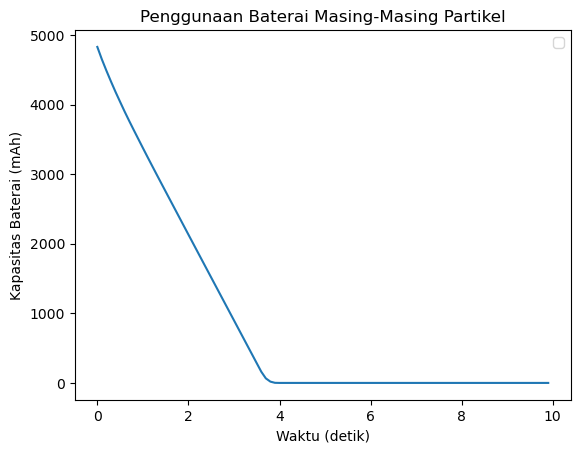

No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.


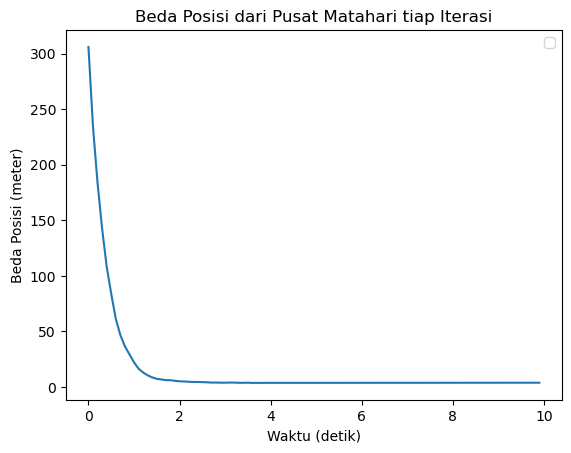

Posisi global terbaik: [497.17749449 499.63310955]
Kapasitas baterai akhir dan persentasenya: 
Drone 1: Kapasitas baterai = 0.002777771002205117 mAh (5.555542004410234e-05%)
Drone 2: Kapasitas baterai = 0.0027777715090556428 mAh (5.555543018111286e-05%)
Drone 3: Kapasitas baterai = 0.002777773115024194 mAh (5.5555462300483884e-05%)
Drone 4: Kapasitas baterai = 0.0027777583787684692 mAh (5.555516757536939e-05%)
Drone 5: Kapasitas baterai = 0.0027777582712081267 mAh (5.555516542416253e-05%)
Drone 6: Kapasitas baterai = 0.0027777417892985465 mAh (5.555483578597093e-05%)
Drone 7: Kapasitas baterai = 0.002777776970526722 mAh (5.555553941053444e-05%)
Drone 8: Kapasitas baterai = 0.002777725105224684 mAh (5.5554502104493674e-05%)
Drone 9: Kapasitas baterai = 0.0027777204968019355 mAh (5.555440993603871e-05%)
Drone 10: Kapasitas baterai = 0.002777771802266898 mAh (5.5555436045337966e-05%)
Drone 11: Kapasitas baterai = 0.0027776974468004213 mAh (5.555394893600843e-05%)
Drone 12: Kapasitas bater

In [18]:
import os
import numpy as np
import matplotlib.pyplot as plt

def gauss_sun_intensity(x, y, sun_center, sun_std_dev):
    """Intensitas Gaussian berdasarkan jarak dari titik tengah."""
    return np.exp(-((x - sun_center[0])**2 + (y - sun_center[1])**2) / (2 * sun_std_dev**2))

def fitness_function(pos, sun_center, sun_std_dev, particles, index, min_distance, repulsion_factor):
    """Fitness function untuk memaksimalkan intensitas cahaya dan meminimalkan repulsi."""
    sun_intensity = gauss_sun_intensity(pos[0], pos[1], sun_center, sun_std_dev)

    repulsion = 0
    for j in range(len(particles)):
        if j != index:
            distance = np.linalg.norm(pos - particles[j])
            if distance < min_distance:
                repulsion += repulsion_factor / distance**2

    fitness = -sun_intensity + repulsion
    return fitness

def calculate_energy_consumption(mass, altitude, horizontal_distance, battery_voltage):
    """Menghitung parameter energi dari setiap drone."""
    drag_coefficient = 0.5
    frontal_area = 0.1  
    air_density = 1.225  
    horizontal_speed = 10.0  
    flight_efficiency = 0.8

    E_vertical_J = mass * 9.81 * altitude
    P_drag = 0.5 * drag_coefficient * frontal_area * air_density * horizontal_speed**2
    P_horizontal = (P_drag + mass * 9.81 * horizontal_speed) / flight_efficiency
    E_horizontal_J = P_horizontal * (horizontal_distance / horizontal_speed)
    E_total_J = E_vertical_J + E_horizontal_J
    E_total_Wh = E_total_J / 3600
    energy_consumed = (E_total_Wh * 1000) / battery_voltage
    return energy_consumed

def pso_drone_solar_chaser_with_battery():
    num_particles = 30
    num_iterations = 100
    dim = 2  
    c1 = 1.0
    c2 = 10.0  
    w = 0.1  
    timestep = 0.1  # seconds
    L = 1000  # meters

    drone_mass = 2.5  
    battery_capacity = 5000  
    solar_charge_rate = 100  
    altitude = 200  
    battery_voltage = 11.1  

    sun_center = np.array([L / 2, L / 2])  
    sun_std_dev = 1000  
    sun_speed = 1000 / 28800  # 1 km per 8 jam dalam meters per second

    min_distance = 3  
    repulsion_factor = 1000  

    particles = np.random.rand(num_particles, dim) * L  
    velocities = np.zeros((num_particles, dim))  
    personal_best_positions = particles.copy()
    global_best_position = particles[0, :].copy()
    global_best_fitness = float('inf')

    battery_levels = battery_capacity * np.ones(num_particles)  

    battery_levels_over_time = np.zeros((num_iterations, num_particles))
    position_diff_over_time = np.zeros((num_iterations, num_particles))

    # Folder untuk menyimpan hasil program
    folder_name = "Percobaan_212"
    if not os.path.exists(folder_name):
        os.makedirs(folder_name)

    for iter in range(num_iterations):
        for i in range(num_particles):
            fitness = fitness_function(particles[i, :], sun_center, sun_std_dev, particles, i, min_distance, repulsion_factor)
            if fitness < fitness_function(personal_best_positions[i, :], sun_center, sun_std_dev, particles, i, min_distance, repulsion_factor):
                personal_best_positions[i, :] = particles[i, :]
            if fitness < global_best_fitness:
                global_best_fitness = fitness
                global_best_position = particles[i, :]

        for i in range(num_particles):
            velocities[i, :] = (w * velocities[i, :] +
                                c1 * np.random.rand() * (personal_best_positions[i, :] - particles[i, :]) +
                                c2 * np.random.rand() * (global_best_position - particles[i, :]) / drone_mass * timestep)
            new_position = particles[i, :] + velocities[i, :]  
            new_position = np.clip(new_position, 0, L)
            horizontal_distance = np.linalg.norm(new_position - particles[i, :])
            energy_consumed = calculate_energy_consumption(drone_mass, altitude, horizontal_distance, battery_voltage)
            battery_levels[i] -= energy_consumed
            if battery_levels[i] > 0:
                particles[i, :] = new_position
            else:
                battery_levels[i] = 0

        for i in range(num_particles):
            solar_energy = (solar_charge_rate * 
                            max(0, gauss_sun_intensity(particles[i, 0], particles[i, 1], sun_center, sun_std_dev)) * 
                            timestep / 3600)
            battery_levels[i] = min(battery_levels[i] + solar_energy, battery_capacity)

        battery_levels_over_time[iter, :] = battery_levels
        position_diff_over_time[iter, :] = np.linalg.norm(particles - sun_center, axis=1)

        sun_center[0] += sun_speed * timestep  

        if sun_center[0] > L:
            sun_center[0] = 0

        X, Y = np.meshgrid(np.arange(0, L+1, 10), np.arange(0, L+1, 10))  
        Z = np.array([[gauss_sun_intensity(x, y, sun_center, sun_std_dev) for x in np.arange(0, L+1, 10)] for y in np.arange(0, L+1, 10)])
        
        plt.contourf(X, Y, Z)  
        plt.colorbar()
        plt.clim(0, 1)
        plt.title('Distribusi Matahari')
        plt.plot(particles[:, 0], particles[:, 1], '.r')
        plt.savefig(f'{folder_name}/frame_{iter+1}.png')  
        plt.clf()

        print(f'Iterasi ke-{iter + 1}: Global Best Fitness = {global_best_fitness}')

    time = np.arange(num_iterations) * timestep 
    
    plt.figure()
    for i in range(num_particles):
        plt.plot(time, battery_levels_over_time[:, i], label=f'Particle {i+1}')
    plt.title('Penggunaan Baterai Masing-Masing Partikel')
    plt.xlabel('Waktu (detik)')
    plt.ylabel('Kapasitas Baterai (mAh)')
    plt.legend(loc='best')
    plt.savefig(f'{folder_name}/Kapasitas Baterai Tiap Waktu.png')  
    plt.show()
    
    plt.figure()
    for i in range(num_particles):
        plt.plot(time, position_diff_over_time[:, i], label=f'Particle {i+1}')
    plt.title('Beda Posisi dari Pusat Matahari tiap Waktu')
    plt.xlabel('Waktu (detik)')
    plt.ylabel('Beda Posisi (meter)')
    plt.legend(loc='best')
    plt.savefig(f'{folder_name}/beda_posisi tiap waktu.png')  
    plt.show()

    print(f'Posisi global terbaik: {global_best_position}')
    print('Kapasitas baterai akhir dan persentasenya: ')
    for i in range(num_particles):
        battery_percentage = (battery_levels[i] / battery_capacity) * 100
        print(f'Drone {i + 1}: Kapasitas baterai = {battery_levels[i]} mAh ({battery_percentage}%)')

if __name__ == "__main__":
    pso_drone_solar_chaser_with_battery()


#### Nilai c1 = 10.0 dan c2 = 1.0

Iterasi ke-1: Global Best Fitness = -0.9998206646543901
Iterasi ke-2: Global Best Fitness = -0.9998207031056007
Iterasi ke-3: Global Best Fitness = -0.9998207415447586
Iterasi ke-4: Global Best Fitness = -0.9998207799718638
Iterasi ke-5: Global Best Fitness = -0.9998208183869163
Iterasi ke-6: Global Best Fitness = -0.9998208567899162
Iterasi ke-7: Global Best Fitness = -0.9998208951808633
Iterasi ke-8: Global Best Fitness = -0.9998209335597578
Iterasi ke-9: Global Best Fitness = -0.9998209719265995
Iterasi ke-10: Global Best Fitness = -0.9998210102813885
Iterasi ke-11: Global Best Fitness = -0.9998210486241248
Iterasi ke-12: Global Best Fitness = -0.9998210869548085
Iterasi ke-13: Global Best Fitness = -0.9998211252734395
Iterasi ke-14: Global Best Fitness = -0.9998211635800177
Iterasi ke-15: Global Best Fitness = -0.9998212018745433
Iterasi ke-16: Global Best Fitness = -0.999821240157016
Iterasi ke-17: Global Best Fitness = -0.9998212784274362
Iterasi ke-18: Global Best Fitness = -0.9

No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.


Iterasi ke-100: Global Best Fitness = -0.9998244128564356


<Figure size 640x480 with 0 Axes>

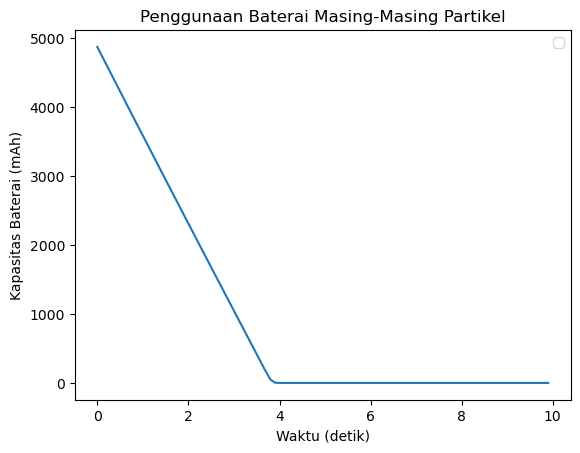

No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.


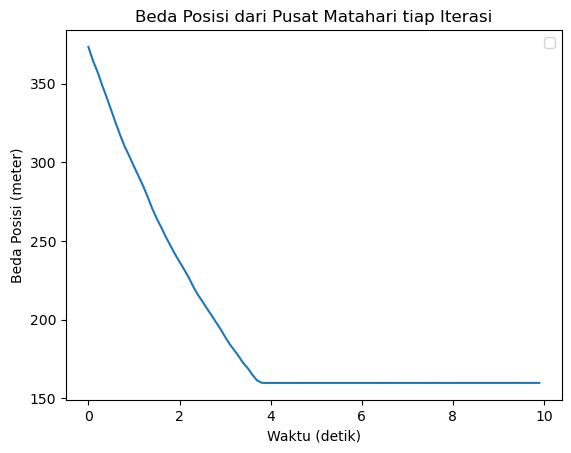

Posisi global terbaik: [511.07767085 484.63809697]
Kapasitas baterai akhir dan persentasenya: 
Drone 1: Kapasitas baterai = 0.0027737878066273927 mAh (5.547575613254785e-05%)
Drone 2: Kapasitas baterai = 0.00276891927536001 mAh (5.53783855072002e-05%)
Drone 3: Kapasitas baterai = 0.0027730185999616606 mAh (5.546037199923321e-05%)
Drone 4: Kapasitas baterai = 0.0027056777545667763 mAh (5.411355509133553e-05%)
Drone 5: Kapasitas baterai = 0.0027510021214356803 mAh (5.5020042428713603e-05%)
Drone 6: Kapasitas baterai = 0.0027413286265938657 mAh (5.482657253187731e-05%)
Drone 7: Kapasitas baterai = 0.0026427655448679676 mAh (5.285531089735935e-05%)
Drone 8: Kapasitas baterai = 0.0027679150343210604 mAh (5.535830068642121e-05%)
Drone 9: Kapasitas baterai = 0.0027111743888339167 mAh (5.4223487776678334e-05%)
Drone 10: Kapasitas baterai = 0.002713813617611825 mAh (5.42762723522365e-05%)
Drone 11: Kapasitas baterai = 0.0027282465801768564 mAh (5.456493160353712e-05%)
Drone 12: Kapasitas batera

In [19]:
import os
import numpy as np
import matplotlib.pyplot as plt

def gauss_sun_intensity(x, y, sun_center, sun_std_dev):
    """Intensitas Gaussian berdasarkan jarak dari titik tengah."""
    return np.exp(-((x - sun_center[0])**2 + (y - sun_center[1])**2) / (2 * sun_std_dev**2))

def fitness_function(pos, sun_center, sun_std_dev, particles, index, min_distance, repulsion_factor):
    """Fitness function untuk memaksimalkan intensitas cahaya dan meminimalkan repulsi."""
    sun_intensity = gauss_sun_intensity(pos[0], pos[1], sun_center, sun_std_dev)

    repulsion = 0
    for j in range(len(particles)):
        if j != index:
            distance = np.linalg.norm(pos - particles[j])
            if distance < min_distance:
                repulsion += repulsion_factor / distance**2

    fitness = -sun_intensity + repulsion
    return fitness

def calculate_energy_consumption(mass, altitude, horizontal_distance, battery_voltage):
    """Menghitung parameter energi dari setiap drone."""
    drag_coefficient = 0.5
    frontal_area = 0.1  
    air_density = 1.225  
    horizontal_speed = 10.0  
    flight_efficiency = 0.8

    E_vertical_J = mass * 9.81 * altitude
    P_drag = 0.5 * drag_coefficient * frontal_area * air_density * horizontal_speed**2
    P_horizontal = (P_drag + mass * 9.81 * horizontal_speed) / flight_efficiency
    E_horizontal_J = P_horizontal * (horizontal_distance / horizontal_speed)
    E_total_J = E_vertical_J + E_horizontal_J
    E_total_Wh = E_total_J / 3600
    energy_consumed = (E_total_Wh * 1000) / battery_voltage
    return energy_consumed

def pso_drone_solar_chaser_with_battery():
    num_particles = 30
    num_iterations = 100
    dim = 2  
    c1 = 10.0
    c2 = 1.0  
    w = 0.1  
    timestep = 0.1  # seconds
    L = 1000  # meters

    drone_mass = 2.5  
    battery_capacity = 5000  
    solar_charge_rate = 100  
    altitude = 200  
    battery_voltage = 11.1  

    sun_center = np.array([L / 2, L / 2])  
    sun_std_dev = 1000  
    sun_speed = 1000 / 28800  # 1 km per 8 jam dalam meters per second

    min_distance = 3  
    repulsion_factor = 1000  

    particles = np.random.rand(num_particles, dim) * L  
    velocities = np.zeros((num_particles, dim))  
    personal_best_positions = particles.copy()
    global_best_position = particles[0, :].copy()
    global_best_fitness = float('inf')

    battery_levels = battery_capacity * np.ones(num_particles)  

    battery_levels_over_time = np.zeros((num_iterations, num_particles))
    position_diff_over_time = np.zeros((num_iterations, num_particles))

    # Folder untuk menyimpan hasil program
    folder_name = "Percobaan_213"
    if not os.path.exists(folder_name):
        os.makedirs(folder_name)

    for iter in range(num_iterations):
        for i in range(num_particles):
            fitness = fitness_function(particles[i, :], sun_center, sun_std_dev, particles, i, min_distance, repulsion_factor)
            if fitness < fitness_function(personal_best_positions[i, :], sun_center, sun_std_dev, particles, i, min_distance, repulsion_factor):
                personal_best_positions[i, :] = particles[i, :]
            if fitness < global_best_fitness:
                global_best_fitness = fitness
                global_best_position = particles[i, :]

        for i in range(num_particles):
            velocities[i, :] = (w * velocities[i, :] +
                                c1 * np.random.rand() * (personal_best_positions[i, :] - particles[i, :]) +
                                c2 * np.random.rand() * (global_best_position - particles[i, :]) / drone_mass * timestep)
            new_position = particles[i, :] + velocities[i, :]  
            new_position = np.clip(new_position, 0, L)
            horizontal_distance = np.linalg.norm(new_position - particles[i, :])
            energy_consumed = calculate_energy_consumption(drone_mass, altitude, horizontal_distance, battery_voltage)
            battery_levels[i] -= energy_consumed
            if battery_levels[i] > 0:
                particles[i, :] = new_position
            else:
                battery_levels[i] = 0

        for i in range(num_particles):
            solar_energy = (solar_charge_rate * 
                            max(0, gauss_sun_intensity(particles[i, 0], particles[i, 1], sun_center, sun_std_dev)) * 
                            timestep / 3600)
            battery_levels[i] = min(battery_levels[i] + solar_energy, battery_capacity)

        battery_levels_over_time[iter, :] = battery_levels
        position_diff_over_time[iter, :] = np.linalg.norm(particles - sun_center, axis=1)

        sun_center[0] += sun_speed * timestep  

        if sun_center[0] > L:
            sun_center[0] = 0

        X, Y = np.meshgrid(np.arange(0, L+1, 10), np.arange(0, L+1, 10))  
        Z = np.array([[gauss_sun_intensity(x, y, sun_center, sun_std_dev) for x in np.arange(0, L+1, 10)] for y in np.arange(0, L+1, 10)])
        
        plt.contourf(X, Y, Z)  
        plt.colorbar()
        plt.clim(0, 1)
        plt.title('Distribusi Matahari')
        plt.plot(particles[:, 0], particles[:, 1], '.r')
        plt.savefig(f'{folder_name}/frame_{iter+1}.png')  
        plt.clf()

        print(f'Iterasi ke-{iter + 1}: Global Best Fitness = {global_best_fitness}')

    time = np.arange(num_iterations) * timestep 
    
    plt.figure()
    for i in range(num_particles):
        plt.plot(time, battery_levels_over_time[:, i], label=f'Particle {i+1}')
    plt.title('Penggunaan Baterai Masing-Masing Partikel')
    plt.xlabel('Waktu (detik)')
    plt.ylabel('Kapasitas Baterai (mAh)')
    plt.legend(loc='best')
    plt.savefig(f'{folder_name}/Kapasitas Baterai Tiap Waktu.png')  
    plt.show()
    
    plt.figure()
    for i in range(num_particles):
        plt.plot(time, position_diff_over_time[:, i], label=f'Particle {i+1}')
    plt.title('Beda Posisi dari Pusat Matahari tiap Waktu')
    plt.xlabel('Waktu (detik)')
    plt.ylabel('Beda Posisi (meter)')
    plt.legend(loc='best')
    plt.savefig(f'{folder_name}/beda_posisi tiap waktu.png')  
    plt.show()

    print(f'Posisi global terbaik: {global_best_position}')
    print('Kapasitas baterai akhir dan persentasenya: ')
    for i in range(num_particles):
        battery_percentage = (battery_levels[i] / battery_capacity) * 100
        print(f'Drone {i + 1}: Kapasitas baterai = {battery_levels[i]} mAh ({battery_percentage}%)')

if __name__ == "__main__":
    pso_drone_solar_chaser_with_battery()


#### Nilai c1 = 10.0 dan c2 = 10.0

Iterasi ke-1: Global Best Fitness = -0.9896278998197156
Iterasi ke-2: Global Best Fitness = -0.9960414656812345
Iterasi ke-3: Global Best Fitness = -0.9966509366976921
Iterasi ke-4: Global Best Fitness = -0.9977118981187109
Iterasi ke-5: Global Best Fitness = -0.998096390504224
Iterasi ke-6: Global Best Fitness = -0.9993138838597896
Iterasi ke-7: Global Best Fitness = -0.9995046335785852
Iterasi ke-8: Global Best Fitness = -0.999748082644023
Iterasi ke-9: Global Best Fitness = -0.999824197120092
Iterasi ke-10: Global Best Fitness = -0.9999137746048187
Iterasi ke-11: Global Best Fitness = -0.9999439178402193
Iterasi ke-12: Global Best Fitness = -0.9999899990447086
Iterasi ke-13: Global Best Fitness = -0.9999899990447086


C:\Users\ACER\AppData\Local\Temp\ipykernel_5964\1870160096.py:18: RuntimeWarning: divide by zero encountered in scalar divide
  repulsion += repulsion_factor / distance**2


Iterasi ke-14: Global Best Fitness = -0.999995935052208
Iterasi ke-15: Global Best Fitness = -0.9999964014924407
Iterasi ke-16: Global Best Fitness = -0.9999964014924407
Iterasi ke-17: Global Best Fitness = -0.9999964014924407
Iterasi ke-18: Global Best Fitness = -0.9999964014924407
Iterasi ke-19: Global Best Fitness = -0.9999982916737555
Iterasi ke-20: Global Best Fitness = -0.9999982916737555
Iterasi ke-21: Global Best Fitness = -0.9999982916737555
Iterasi ke-22: Global Best Fitness = -0.9999982916737555
Iterasi ke-23: Global Best Fitness = -0.9999982916737555
Iterasi ke-24: Global Best Fitness = -0.9999982916737555
Iterasi ke-25: Global Best Fitness = -0.9999982916737555
Iterasi ke-26: Global Best Fitness = -0.9999982916737555
Iterasi ke-27: Global Best Fitness = -0.9999982916737555
Iterasi ke-28: Global Best Fitness = -0.9999983067289719
Iterasi ke-29: Global Best Fitness = -0.9999983067289719
Iterasi ke-30: Global Best Fitness = -0.9999983067289719
Iterasi ke-31: Global Best Fitne

No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.


Iterasi ke-100: Global Best Fitness = -0.9999983176288728


<Figure size 640x480 with 0 Axes>

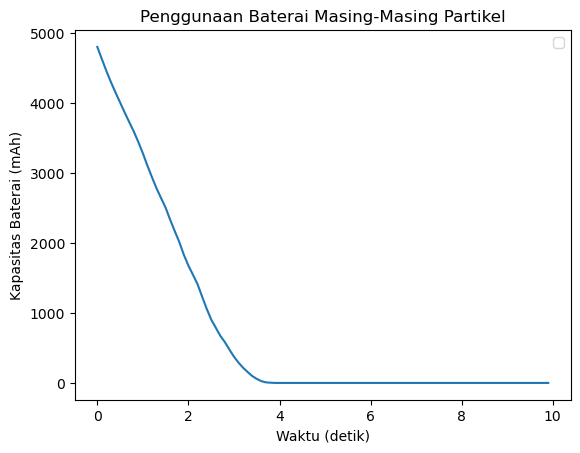

No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.


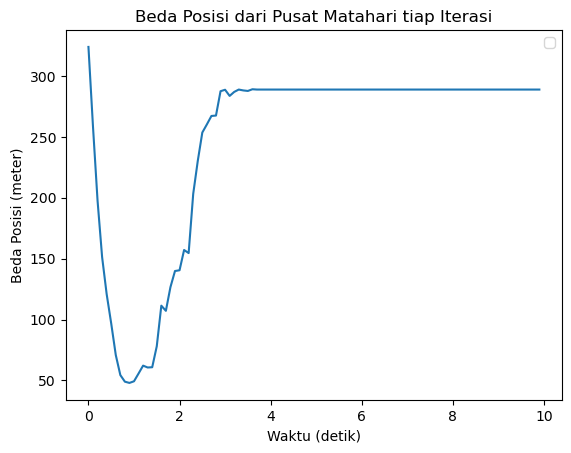

Posisi global terbaik: [500.5543425  501.78168426]
Kapasitas baterai akhir dan persentasenya: 
Drone 1: Kapasitas baterai = 0.0027777724352751 mAh (5.5555448705502e-05%)
Drone 2: Kapasitas baterai = 0.002163707235941382 mAh (4.327414471882764e-05%)
Drone 3: Kapasitas baterai = 0.002162963589400598 mAh (4.3259271788011964e-05%)
Drone 4: Kapasitas baterai = 0.0027776210920827894 mAh (5.555242184165579e-05%)
Drone 5: Kapasitas baterai = 0.002777773307298059 mAh (5.555546614596118e-05%)
Drone 6: Kapasitas baterai = 0.0023497741059959366 mAh (4.6995482119918735e-05%)
Drone 7: Kapasitas baterai = 0.0027777605342673875 mAh (5.5555210685347755e-05%)
Drone 8: Kapasitas baterai = 0.002732064261795873 mAh (5.464128523591746e-05%)
Drone 9: Kapasitas baterai = 0.0027772226822487707 mAh (5.5544453644975414e-05%)
Drone 10: Kapasitas baterai = 0.002163707235941382 mAh (4.327414471882764e-05%)
Drone 11: Kapasitas baterai = 0.0027766501050588196 mAh (5.553300210117639e-05%)
Drone 12: Kapasitas baterai =

In [20]:
import os
import numpy as np
import matplotlib.pyplot as plt

def gauss_sun_intensity(x, y, sun_center, sun_std_dev):
    """Intensitas Gaussian berdasarkan jarak dari titik tengah."""
    return np.exp(-((x - sun_center[0])**2 + (y - sun_center[1])**2) / (2 * sun_std_dev**2))

def fitness_function(pos, sun_center, sun_std_dev, particles, index, min_distance, repulsion_factor):
    """Fitness function untuk memaksimalkan intensitas cahaya dan meminimalkan repulsi."""
    sun_intensity = gauss_sun_intensity(pos[0], pos[1], sun_center, sun_std_dev)

    repulsion = 0
    for j in range(len(particles)):
        if j != index:
            distance = np.linalg.norm(pos - particles[j])
            if distance < min_distance:
                repulsion += repulsion_factor / distance**2

    fitness = -sun_intensity + repulsion
    return fitness

def calculate_energy_consumption(mass, altitude, horizontal_distance, battery_voltage):
    """Menghitung parameter energi dari setiap drone."""
    drag_coefficient = 0.5
    frontal_area = 0.1  
    air_density = 1.225  
    horizontal_speed = 10.0  
    flight_efficiency = 0.8

    E_vertical_J = mass * 9.81 * altitude
    P_drag = 0.5 * drag_coefficient * frontal_area * air_density * horizontal_speed**2
    P_horizontal = (P_drag + mass * 9.81 * horizontal_speed) / flight_efficiency
    E_horizontal_J = P_horizontal * (horizontal_distance / horizontal_speed)
    E_total_J = E_vertical_J + E_horizontal_J
    E_total_Wh = E_total_J / 3600
    energy_consumed = (E_total_Wh * 1000) / battery_voltage
    return energy_consumed

def pso_drone_solar_chaser_with_battery():
    num_particles = 30
    num_iterations = 100
    dim = 2  
    c1 = 10.0
    c2 = 10.0  
    w = 0.1  
    timestep = 0.1  # seconds
    L = 1000  # meters

    drone_mass = 2.5  
    battery_capacity = 5000  
    solar_charge_rate = 100  
    altitude = 200  
    battery_voltage = 11.1  

    sun_center = np.array([L / 2, L / 2])  
    sun_std_dev = 1000  
    sun_speed = 1000 / 28800  # 1 km per 8 jam dalam meters per second

    min_distance = 3  
    repulsion_factor = 1000  

    particles = np.random.rand(num_particles, dim) * L  
    velocities = np.zeros((num_particles, dim))  
    personal_best_positions = particles.copy()
    global_best_position = particles[0, :].copy()
    global_best_fitness = float('inf')

    battery_levels = battery_capacity * np.ones(num_particles)  

    battery_levels_over_time = np.zeros((num_iterations, num_particles))
    position_diff_over_time = np.zeros((num_iterations, num_particles))

    # Folder untuk menyimpan hasil program
    folder_name = "Percobaan_214"
    if not os.path.exists(folder_name):
        os.makedirs(folder_name)

    for iter in range(num_iterations):
        for i in range(num_particles):
            fitness = fitness_function(particles[i, :], sun_center, sun_std_dev, particles, i, min_distance, repulsion_factor)
            if fitness < fitness_function(personal_best_positions[i, :], sun_center, sun_std_dev, particles, i, min_distance, repulsion_factor):
                personal_best_positions[i, :] = particles[i, :]
            if fitness < global_best_fitness:
                global_best_fitness = fitness
                global_best_position = particles[i, :]

        for i in range(num_particles):
            velocities[i, :] = (w * velocities[i, :] +
                                c1 * np.random.rand() * (personal_best_positions[i, :] - particles[i, :]) +
                                c2 * np.random.rand() * (global_best_position - particles[i, :]) / drone_mass * timestep)
            new_position = particles[i, :] + velocities[i, :]  
            new_position = np.clip(new_position, 0, L)
            horizontal_distance = np.linalg.norm(new_position - particles[i, :])
            energy_consumed = calculate_energy_consumption(drone_mass, altitude, horizontal_distance, battery_voltage)
            battery_levels[i] -= energy_consumed
            if battery_levels[i] > 0:
                particles[i, :] = new_position
            else:
                battery_levels[i] = 0

        for i in range(num_particles):
            solar_energy = (solar_charge_rate * 
                            max(0, gauss_sun_intensity(particles[i, 0], particles[i, 1], sun_center, sun_std_dev)) * 
                            timestep / 3600)
            battery_levels[i] = min(battery_levels[i] + solar_energy, battery_capacity)

        battery_levels_over_time[iter, :] = battery_levels
        position_diff_over_time[iter, :] = np.linalg.norm(particles - sun_center, axis=1)

        sun_center[0] += sun_speed * timestep  

        if sun_center[0] > L:
            sun_center[0] = 0

        X, Y = np.meshgrid(np.arange(0, L+1, 10), np.arange(0, L+1, 10))  
        Z = np.array([[gauss_sun_intensity(x, y, sun_center, sun_std_dev) for x in np.arange(0, L+1, 10)] for y in np.arange(0, L+1, 10)])
        
        plt.contourf(X, Y, Z)  
        plt.colorbar()
        plt.clim(0, 1)
        plt.title('Distribusi Matahari')
        plt.plot(particles[:, 0], particles[:, 1], '.r')
        plt.savefig(f'{folder_name}/frame_{iter+1}.png')  
        plt.clf()

        print(f'Iterasi ke-{iter + 1}: Global Best Fitness = {global_best_fitness}')

    time = np.arange(num_iterations) * timestep 
    
    plt.figure()
    for i in range(num_particles):
        plt.plot(time, battery_levels_over_time[:, i], label=f'Particle {i+1}')
    plt.title('Penggunaan Baterai Masing-Masing Partikel')
    plt.xlabel('Waktu (detik)')
    plt.ylabel('Kapasitas Baterai (mAh)')
    plt.legend(loc='best')
    plt.savefig(f'{folder_name}/Kapasitas Baterai Tiap Waktu.png')  
    plt.show()
    
    plt.figure()
    for i in range(num_particles):
        plt.plot(time, position_diff_over_time[:, i], label=f'Particle {i+1}')
    plt.title('Beda Posisi dari Pusat Matahari tiap Waktu')
    plt.xlabel('Waktu (detik)')
    plt.ylabel('Beda Posisi (meter)')
    plt.legend(loc='best')
    plt.savefig(f'{folder_name}/beda_posisi tiap waktu.png')  
    plt.show()

    print(f'Posisi global terbaik: {global_best_position}')
    print('Kapasitas baterai akhir dan persentasenya: ')
    for i in range(num_particles):
        battery_percentage = (battery_levels[i] / battery_capacity) * 100
        print(f'Drone {i + 1}: Kapasitas baterai = {battery_levels[i]} mAh ({battery_percentage}%)')

if __name__ == "__main__":
    pso_drone_solar_chaser_with_battery()


#### Nilai c1 = 5.0 dan c2 = 5.0 w = 0.1

Iterasi ke-1: Global Best Fitness = -0.9934808777471971
Iterasi ke-2: Global Best Fitness = -0.9934811724778045
Iterasi ke-3: Global Best Fitness = -0.9934814671965216
Iterasi ke-4: Global Best Fitness = -0.9935710972380907
Iterasi ke-5: Global Best Fitness = -0.9960991606859823
Iterasi ke-6: Global Best Fitness = -0.9963664808831062
Iterasi ke-7: Global Best Fitness = -0.9963926541374262
Iterasi ke-8: Global Best Fitness = -0.9971125171017954
Iterasi ke-9: Global Best Fitness = -0.9975111512012471
Iterasi ke-10: Global Best Fitness = -0.9987090376186065
Iterasi ke-11: Global Best Fitness = -0.9988089617171565
Iterasi ke-12: Global Best Fitness = -0.9991456145929907
Iterasi ke-13: Global Best Fitness = -0.9992153872941789
Iterasi ke-14: Global Best Fitness = -0.9993502933245961
Iterasi ke-15: Global Best Fitness = -0.9995991396322753
Iterasi ke-16: Global Best Fitness = -0.9997023338064032
Iterasi ke-17: Global Best Fitness = -0.9997272088526826
Iterasi ke-18: Global Best Fitness = -0.

No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.


Iterasi ke-100: Global Best Fitness = -0.9999932783207346


<Figure size 640x480 with 0 Axes>

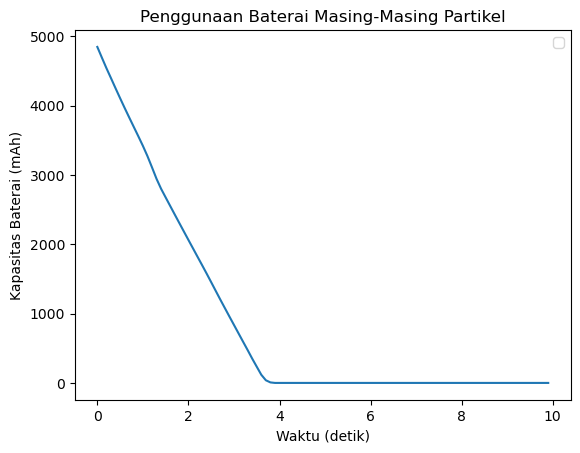

No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.


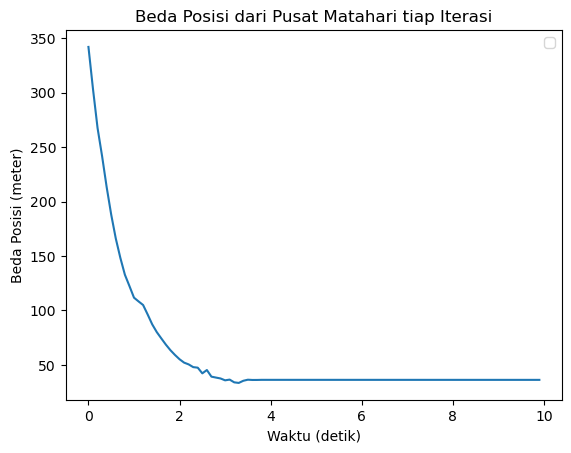

Posisi global terbaik: [497.15038232 497.59544927]
Kapasitas baterai akhir dan persentasenya: 
Drone 1: Kapasitas baterai = 0.0027777555841700737 mAh (5.555511168340147e-05%)
Drone 2: Kapasitas baterai = 0.002777573823459631 mAh (5.5551476469192616e-05%)
Drone 3: Kapasitas baterai = 0.002777695733331836 mAh (5.5553914666636724e-05%)
Drone 4: Kapasitas baterai = 0.0027776280581707363 mAh (5.5552561163414726e-05%)
Drone 5: Kapasitas baterai = 0.0027775353668419243 mAh (5.555070733683848e-05%)
Drone 6: Kapasitas baterai = 0.0027773517494238498 mAh (5.5547034988477e-05%)
Drone 7: Kapasitas baterai = 0.0027759348196074334 mAh (5.5518696392148665e-05%)
Drone 8: Kapasitas baterai = 0.002777671896743234 mAh (5.5553437934864684e-05%)
Drone 9: Kapasitas baterai = 0.0027774312198934844 mAh (5.554862439786969e-05%)
Drone 10: Kapasitas baterai = 0.0027775258685880507 mAh (5.5550517371761015e-05%)
Drone 11: Kapasitas baterai = 0.0027772276273401965 mAh (5.554455254680393e-05%)
Drone 12: Kapasitas ba

In [21]:
import os
import numpy as np
import matplotlib.pyplot as plt

def gauss_sun_intensity(x, y, sun_center, sun_std_dev):
    """Intensitas Gaussian berdasarkan jarak dari titik tengah."""
    return np.exp(-((x - sun_center[0])**2 + (y - sun_center[1])**2) / (2 * sun_std_dev**2))

def fitness_function(pos, sun_center, sun_std_dev, particles, index, min_distance, repulsion_factor):
    """Fitness function untuk memaksimalkan intensitas cahaya dan meminimalkan repulsi."""
    sun_intensity = gauss_sun_intensity(pos[0], pos[1], sun_center, sun_std_dev)

    repulsion = 0
    for j in range(len(particles)):
        if j != index:
            distance = np.linalg.norm(pos - particles[j])
            if distance < min_distance:
                repulsion += repulsion_factor / distance**2

    fitness = -sun_intensity + repulsion
    return fitness

def calculate_energy_consumption(mass, altitude, horizontal_distance, battery_voltage):
    """Menghitung parameter energi dari setiap drone."""
    drag_coefficient = 0.5
    frontal_area = 0.1  
    air_density = 1.225  
    horizontal_speed = 10.0  
    flight_efficiency = 0.8

    E_vertical_J = mass * 9.81 * altitude
    P_drag = 0.5 * drag_coefficient * frontal_area * air_density * horizontal_speed**2
    P_horizontal = (P_drag + mass * 9.81 * horizontal_speed) / flight_efficiency
    E_horizontal_J = P_horizontal * (horizontal_distance / horizontal_speed)
    E_total_J = E_vertical_J + E_horizontal_J
    E_total_Wh = E_total_J / 3600
    energy_consumed = (E_total_Wh * 1000) / battery_voltage
    return energy_consumed

def pso_drone_solar_chaser_with_battery():
    num_particles = 30
    num_iterations = 100
    dim = 2  
    c1 = 5.0
    c2 = 5.0  
    w = 0.1  
    timestep = 0.1  # seconds
    L = 1000  # meters

    drone_mass = 2.5  
    battery_capacity = 5000  
    solar_charge_rate = 100  
    altitude = 200  
    battery_voltage = 11.1  

    sun_center = np.array([L / 2, L / 2])  
    sun_std_dev = 1000  
    sun_speed = 1000 / 28800  # 1 km per 8 jam dalam meters per second

    min_distance = 3  
    repulsion_factor = 1000  

    particles = np.random.rand(num_particles, dim) * L  
    velocities = np.zeros((num_particles, dim))  
    personal_best_positions = particles.copy()
    global_best_position = particles[0, :].copy()
    global_best_fitness = float('inf')

    battery_levels = battery_capacity * np.ones(num_particles)  

    battery_levels_over_time = np.zeros((num_iterations, num_particles))
    position_diff_over_time = np.zeros((num_iterations, num_particles))

    # Folder untuk menyimpan hasil program
    folder_name = "Percobaan_215"
    if not os.path.exists(folder_name):
        os.makedirs(folder_name)

    for iter in range(num_iterations):
        for i in range(num_particles):
            fitness = fitness_function(particles[i, :], sun_center, sun_std_dev, particles, i, min_distance, repulsion_factor)
            if fitness < fitness_function(personal_best_positions[i, :], sun_center, sun_std_dev, particles, i, min_distance, repulsion_factor):
                personal_best_positions[i, :] = particles[i, :]
            if fitness < global_best_fitness:
                global_best_fitness = fitness
                global_best_position = particles[i, :]

        for i in range(num_particles):
            velocities[i, :] = (w * velocities[i, :] +
                                c1 * np.random.rand() * (personal_best_positions[i, :] - particles[i, :]) +
                                c2 * np.random.rand() * (global_best_position - particles[i, :]) / drone_mass * timestep)
            new_position = particles[i, :] + velocities[i, :]  
            new_position = np.clip(new_position, 0, L)
            horizontal_distance = np.linalg.norm(new_position - particles[i, :])
            energy_consumed = calculate_energy_consumption(drone_mass, altitude, horizontal_distance, battery_voltage)
            battery_levels[i] -= energy_consumed
            if battery_levels[i] > 0:
                particles[i, :] = new_position
            else:
                battery_levels[i] = 0

        for i in range(num_particles):
            solar_energy = (solar_charge_rate * 
                            max(0, gauss_sun_intensity(particles[i, 0], particles[i, 1], sun_center, sun_std_dev)) * 
                            timestep / 3600)
            battery_levels[i] = min(battery_levels[i] + solar_energy, battery_capacity)

        battery_levels_over_time[iter, :] = battery_levels
        position_diff_over_time[iter, :] = np.linalg.norm(particles - sun_center, axis=1)

        sun_center[0] += sun_speed * timestep  

        if sun_center[0] > L:
            sun_center[0] = 0

        X, Y = np.meshgrid(np.arange(0, L+1, 10), np.arange(0, L+1, 10))  
        Z = np.array([[gauss_sun_intensity(x, y, sun_center, sun_std_dev) for x in np.arange(0, L+1, 10)] for y in np.arange(0, L+1, 10)])
        
        plt.contourf(X, Y, Z)  
        plt.colorbar()
        plt.clim(0, 1)
        plt.title('Distribusi Matahari')
        plt.plot(particles[:, 0], particles[:, 1], '.r')
        plt.savefig(f'{folder_name}/frame_{iter+1}.png')  
        plt.clf()

        print(f'Iterasi ke-{iter + 1}: Global Best Fitness = {global_best_fitness}')

    time = np.arange(num_iterations) * timestep 
    
    plt.figure()
    for i in range(num_particles):
        plt.plot(time, battery_levels_over_time[:, i], label=f'Particle {i+1}')
    plt.title('Penggunaan Baterai Masing-Masing Partikel')
    plt.xlabel('Waktu (detik)')
    plt.ylabel('Kapasitas Baterai (mAh)')
    plt.legend(loc='best')
    plt.savefig(f'{folder_name}/Kapasitas Baterai Tiap Waktu.png')  
    plt.show()
    
    plt.figure()
    for i in range(num_particles):
        plt.plot(time, position_diff_over_time[:, i], label=f'Particle {i+1}')
    plt.title('Beda Posisi dari Pusat Matahari tiap Waktu')
    plt.xlabel('Waktu (detik)')
    plt.ylabel('Beda Posisi (meter)')
    plt.legend(loc='best')
    plt.savefig(f'{folder_name}/beda_posisi tiap waktu.png')  
    plt.show()

    print(f'Posisi global terbaik: {global_best_position}')
    print('Kapasitas baterai akhir dan persentasenya: ')
    for i in range(num_particles):
        battery_percentage = (battery_levels[i] / battery_capacity) * 100
        print(f'Drone {i + 1}: Kapasitas baterai = {battery_levels[i]} mAh ({battery_percentage}%)')

if __name__ == "__main__":
    pso_drone_solar_chaser_with_battery()


#### Variasi w


c1 = 1

c2 = 1,5

w = 0,1

jumlah partikel = 20

massa drone = 2,5

kapasitas baterai = 5000

Iterasi ke-1: Global Best Fitness = -0.9907273433778767
Iterasi ke-2: Global Best Fitness = -0.9907273433778767
Iterasi ke-3: Global Best Fitness = -0.9907273433778767
Iterasi ke-4: Global Best Fitness = -0.9915199442841076
Iterasi ke-5: Global Best Fitness = -0.9917571503919766
Iterasi ke-6: Global Best Fitness = -0.9929838180066983
Iterasi ke-7: Global Best Fitness = -0.9931073068990623
Iterasi ke-8: Global Best Fitness = -0.9937011812554838
Iterasi ke-9: Global Best Fitness = -0.9937708537823187
Iterasi ke-10: Global Best Fitness = -0.9942814226013769
Iterasi ke-11: Global Best Fitness = -0.994679764644482
Iterasi ke-12: Global Best Fitness = -0.9947641528163638
Iterasi ke-13: Global Best Fitness = -0.9952318864491201
Iterasi ke-14: Global Best Fitness = -0.9952925206805089
Iterasi ke-15: Global Best Fitness = -0.995391172989718
Iterasi ke-16: Global Best Fitness = -0.9954322035226231
Iterasi ke-17: Global Best Fitness = -0.9960005193656708
Iterasi ke-18: Global Best Fitness = -0.99

<Figure size 640x480 with 0 Axes>

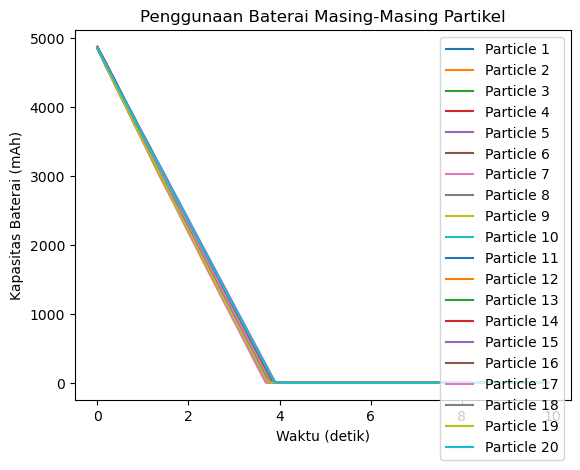

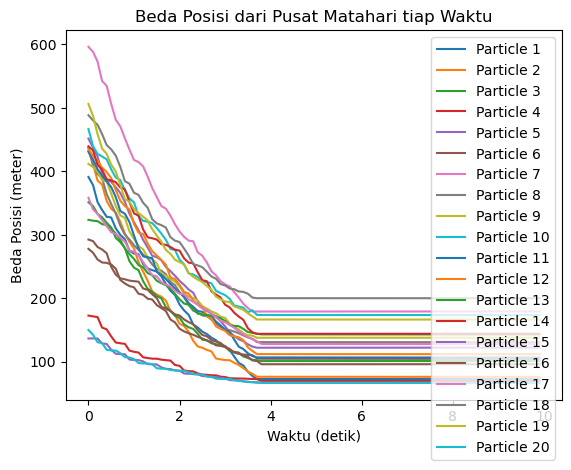

Posisi global terbaik: [543.43899376 550.86731293]
Kapasitas baterai akhir dan persentasenya: 
Drone 1: Kapasitas baterai = 0.0027704808444679752 mAh (5.5409616889359505e-05%)
Drone 2: Kapasitas baterai = 0.0027697665827242685 mAh (5.539533165448537e-05%)
Drone 3: Kapasitas baterai = 0.002763651916458557 mAh (5.527303832917114e-05%)
Drone 4: Kapasitas baterai = 0.0027710540891335315 mAh (5.5421081782670625e-05%)
Drone 5: Kapasitas baterai = 0.00275714579275631 mAh (5.5142915855126196e-05%)
Drone 6: Kapasitas baterai = 0.0027626877996355364 mAh (5.525375599271073e-05%)
Drone 7: Kapasitas baterai = 0.0027336034600878474 mAh (5.467206920175695e-05%)
Drone 8: Kapasitas baterai = 0.002754186204668131 mAh (5.5083724093362616e-05%)
Drone 9: Kapasitas baterai = 0.002751552574212082 mAh (5.5031051484241636e-05%)
Drone 10: Kapasitas baterai = 0.0027363388866021854 mAh (5.472677773204371e-05%)
Drone 11: Kapasitas baterai = 0.0027620913441749693 mAh (5.5241826883499384e-05%)
Drone 12: Kapasitas ba

In [11]:
import os
import numpy as np
import matplotlib.pyplot as plt

def gauss_sun_intensity(x, y, sun_center, sun_std_dev):
    """Intensitas Gaussian berdasarkan jarak dari titik tengah."""
    return np.exp(-((x - sun_center[0])**2 + (y - sun_center[1])**2) / (2 * sun_std_dev**2))

def fitness_function(pos, sun_center, sun_std_dev, particles, index, min_distance, repulsion_factor):
    """Fitness function untuk memaksimalkan intensitas cahaya dan meminimalkan repulsi."""
    sun_intensity = gauss_sun_intensity(pos[0], pos[1], sun_center, sun_std_dev)

    repulsion = 0
    for j in range(len(particles)):
        if j != index:
            distance = np.linalg.norm(pos - particles[j])
            if distance < min_distance:
                repulsion += repulsion_factor / distance**2

    fitness = -sun_intensity + repulsion
    return fitness

def calculate_energy_consumption(mass, altitude, horizontal_distance, battery_voltage):
    """Menghitung parameter energi dari setiap drone."""
    drag_coefficient = 0.5
    frontal_area = 0.1  
    air_density = 1.225  
    horizontal_speed = 10.0  
    flight_efficiency = 0.8

    E_vertical_J = mass * 9.81 * altitude
    P_drag = 0.5 * drag_coefficient * frontal_area * air_density * horizontal_speed**2
    P_horizontal = (P_drag + mass * 9.81 * horizontal_speed) / flight_efficiency
    E_horizontal_J = P_horizontal * (horizontal_distance / horizontal_speed)
    E_total_J = E_vertical_J + E_horizontal_J
    E_total_Wh = E_total_J / 3600
    energy_consumed = (E_total_Wh * 1000) / battery_voltage
    return energy_consumed

def pso_drone_solar_chaser_with_battery():
    num_particles = 20
    num_iterations = 100
    dim = 2  
    c1 = 1.0
    c2 = 1.5  
    w = 0.1  
    timestep = 0.1  # seconds
    L = 1000  # meters

    drone_mass = 2.5 # massa baterai + massa panel surya (massa baterai yang dipakai yaitu variasi 7 kg dan massa panel surya variasi 5, 15, 30 ) 
    battery_capacity = 5000  
    solar_charge_rate = 100  
    altitude = 200  
    battery_voltage = 11.1  

    sun_center = np.array([L / 2, L / 2])  
    sun_std_dev = 1000  
    sun_speed = 1000 / 28800  # 1 km per 8 jam dalam meters per second

    min_distance = 3  
    repulsion_factor = 1000  

    particles = np.random.rand(num_particles, dim) * L  
    velocities = np.zeros((num_particles, dim))  
    personal_best_positions = particles.copy()
    global_best_position = particles[0, :].copy()
    global_best_fitness = float('inf')

    battery_levels = battery_capacity * np.ones(num_particles)  

    battery_levels_over_time = np.zeros((num_iterations, num_particles))
    position_diff_over_time = np.zeros((num_iterations, num_particles))

    # Folder untuk menyimpan hasil program
    folder_name = "Percobaan_221"
    if not os.path.exists(folder_name):
        os.makedirs(folder_name)

    for iter in range(num_iterations):
        for i in range(num_particles):
            fitness = fitness_function(particles[i, :], sun_center, sun_std_dev, particles, i, min_distance, repulsion_factor)
            if fitness < fitness_function(personal_best_positions[i, :], sun_center, sun_std_dev, particles, i, min_distance, repulsion_factor):
                personal_best_positions[i, :] = particles[i, :]
            if fitness < global_best_fitness:
                global_best_fitness = fitness
                global_best_position = particles[i, :]

        for i in range(num_particles):
            velocities[i, :] = (w * velocities[i, :] +
                                c1 * np.random.rand() * (personal_best_positions[i, :] - particles[i, :]) +
                                c2 * np.random.rand() * (global_best_position - particles[i, :]) / drone_mass * timestep)
            new_position = particles[i, :] + velocities[i, :]  
            new_position = np.clip(new_position, 0, L)
            horizontal_distance = np.linalg.norm(new_position - particles[i, :])
            energy_consumed = calculate_energy_consumption(drone_mass, altitude, horizontal_distance, battery_voltage)
            battery_levels[i] -= energy_consumed
            if battery_levels[i] > 0:
                particles[i, :] = new_position
            else:
                battery_levels[i] = 0

        for i in range(num_particles):
            solar_energy = (solar_charge_rate * 
                            max(0, gauss_sun_intensity(particles[i, 0], particles[i, 1], sun_center, sun_std_dev)) * 
                            timestep / 3600)
            battery_levels[i] = min(battery_levels[i] + solar_energy, battery_capacity)

        battery_levels_over_time[iter, :] = battery_levels
        position_diff_over_time[iter, :] = np.linalg.norm(particles - sun_center, axis=1)

        sun_center[0] += sun_speed * timestep  

        if sun_center[0] > L:
            sun_center[0] = 0

        X, Y = np.meshgrid(np.arange(0, L+1, 10), np.arange(0, L+1, 10))  
        Z = np.array([[gauss_sun_intensity(x, y, sun_center, sun_std_dev) for x in np.arange(0, L+1, 10)] for y in np.arange(0, L+1, 10)])
        
        plt.contourf(X, Y, Z)  
        plt.colorbar()
        plt.clim(0, 1)
        plt.title('Distribusi Matahari')
        plt.plot(particles[:, 0], particles[:, 1], '.r')
        plt.savefig(f'{folder_name}/frame_{iter+1}.png')  
        plt.clf()

        print(f'Iterasi ke-{iter + 1}: Global Best Fitness = {global_best_fitness}')

    time = np.arange(num_iterations) * timestep 
    
    plt.figure()
    for i in range(num_particles):
        plt.plot(time, battery_levels_over_time[:, i], label=f'Particle {i+1}')
    plt.title('Penggunaan Baterai Masing-Masing Partikel')
    plt.xlabel('Waktu (detik)')
    plt.ylabel('Kapasitas Baterai (mAh)')
    plt.legend(loc='best')
    plt.savefig(f'{folder_name}/Kapasitas Baterai Tiap Waktu.png')  
    plt.show()
    
    plt.figure()
    for i in range(num_particles):
        plt.plot(time, position_diff_over_time[:, i], label=f'Particle {i+1}')
    plt.title('Beda Posisi dari Pusat Matahari tiap Waktu')
    plt.xlabel('Waktu (detik)')
    plt.ylabel('Beda Posisi (meter)')
    plt.legend(loc='best')
    plt.savefig(f'{folder_name}/beda_posisi tiap waktu.png')  
    plt.show()

    print(f'Posisi global terbaik: {global_best_position}')
    print('Kapasitas baterai akhir dan persentasenya: ')
    for i in range(num_particles):
        battery_percentage = (battery_levels[i] / battery_capacity) * 100
        print(f'Drone {i + 1}: Kapasitas baterai = {battery_levels[i]} mAh ({battery_percentage}%)')

if __name__ == "__main__":
    pso_drone_solar_chaser_with_battery()


c1 = 1

c2 = 1,5

w = 1,0

jumlah partikel = 20

massa drone = 2,5

kapasitas baterai = 5000

Iterasi ke-1: Global Best Fitness = -0.9947967874332689
Iterasi ke-2: Global Best Fitness = -0.9947967874332689
Iterasi ke-3: Global Best Fitness = -0.9947967874332689
Iterasi ke-4: Global Best Fitness = -0.9947967874332689
Iterasi ke-5: Global Best Fitness = -0.9947967874332689
Iterasi ke-6: Global Best Fitness = -0.9947967874332689
Iterasi ke-7: Global Best Fitness = -0.9947967874332689
Iterasi ke-8: Global Best Fitness = -0.9947967874332689
Iterasi ke-9: Global Best Fitness = -0.9947967874332689
Iterasi ke-10: Global Best Fitness = -0.9947967874332689
Iterasi ke-11: Global Best Fitness = -0.9947967874332689
Iterasi ke-12: Global Best Fitness = -0.9947967874332689
Iterasi ke-13: Global Best Fitness = -0.9947967874332689
Iterasi ke-14: Global Best Fitness = -0.9947967874332689
Iterasi ke-15: Global Best Fitness = -0.9952906577277932
Iterasi ke-16: Global Best Fitness = -0.9953725408095776
Iterasi ke-17: Global Best Fitness = -0.9953805932245884
Iterasi ke-18: Global Best Fitness = -0.

No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.


Iterasi ke-100: Global Best Fitness = -0.9990999911668637


<Figure size 640x480 with 0 Axes>

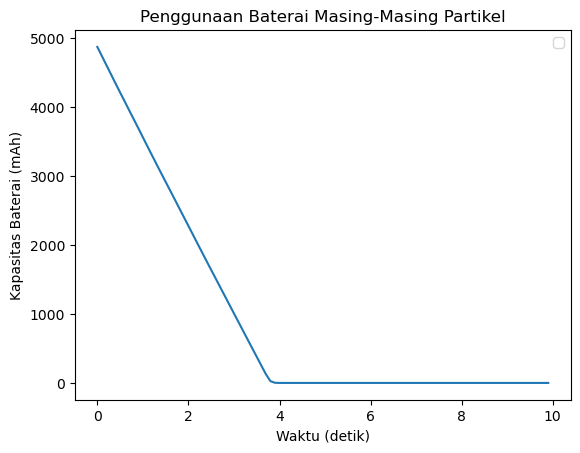

No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.


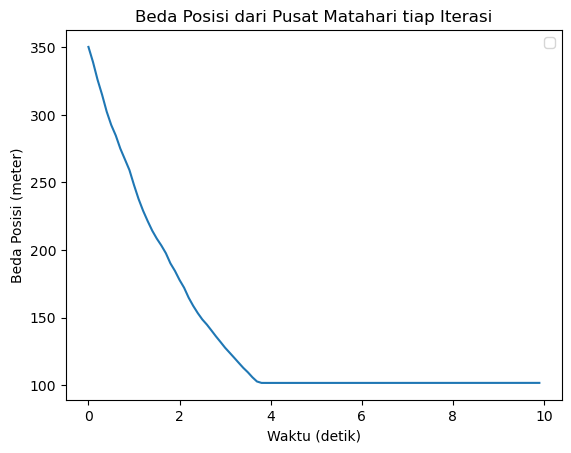

Posisi global terbaik: [467.16152195 526.70807815]
Kapasitas baterai akhir dan persentasenya: 
Drone 1: Kapasitas baterai = 0.0027749785738241323 mAh (5.549957147648265e-05%)
Drone 2: Kapasitas baterai = 0.0027571228869458803 mAh (5.5142457738917606e-05%)
Drone 3: Kapasitas baterai = 0.002767462574340325 mAh (5.53492514868065e-05%)
Drone 4: Kapasitas baterai = 0.002710919803812028 mAh (5.421839607624056e-05%)
Drone 5: Kapasitas baterai = 0.0027752589459024537 mAh (5.5505178918049075e-05%)
Drone 6: Kapasitas baterai = 0.0027662619214767386 mAh (5.532523842953477e-05%)
Drone 7: Kapasitas baterai = 0.002770164630057521 mAh (5.540329260115042e-05%)
Drone 8: Kapasitas baterai = 0.0027729618838308037 mAh (5.545923767661607e-05%)
Drone 9: Kapasitas baterai = 0.002738500091508802 mAh (5.477000183017604e-05%)
Drone 10: Kapasitas baterai = 0.0027577270858623196 mAh (5.5154541717246386e-05%)
Drone 11: Kapasitas baterai = 0.0027715400672711156 mAh (5.543080134542231e-05%)
Drone 12: Kapasitas bater

In [23]:
import os
import numpy as np
import matplotlib.pyplot as plt

def gauss_sun_intensity(x, y, sun_center, sun_std_dev):
    """Intensitas Gaussian berdasarkan jarak dari titik tengah."""
    return np.exp(-((x - sun_center[0])**2 + (y - sun_center[1])**2) / (2 * sun_std_dev**2))

def fitness_function(pos, sun_center, sun_std_dev, particles, index, min_distance, repulsion_factor):
    """Fitness function untuk memaksimalkan intensitas cahaya dan meminimalkan repulsi."""
    sun_intensity = gauss_sun_intensity(pos[0], pos[1], sun_center, sun_std_dev)

    repulsion = 0
    for j in range(len(particles)):
        if j != index:
            distance = np.linalg.norm(pos - particles[j])
            if distance < min_distance:
                repulsion += repulsion_factor / distance**2

    fitness = -sun_intensity + repulsion
    return fitness

def calculate_energy_consumption(mass, altitude, horizontal_distance, battery_voltage):
    """Menghitung parameter energi dari setiap drone."""
    drag_coefficient = 0.5
    frontal_area = 0.1  
    air_density = 1.225  
    horizontal_speed = 10.0  
    flight_efficiency = 0.8

    E_vertical_J = mass * 9.81 * altitude
    P_drag = 0.5 * drag_coefficient * frontal_area * air_density * horizontal_speed**2
    P_horizontal = (P_drag + mass * 9.81 * horizontal_speed) / flight_efficiency
    E_horizontal_J = P_horizontal * (horizontal_distance / horizontal_speed)
    E_total_J = E_vertical_J + E_horizontal_J
    E_total_Wh = E_total_J / 3600
    energy_consumed = (E_total_Wh * 1000) / battery_voltage
    return energy_consumed

def pso_drone_solar_chaser_with_battery():
    num_particles = 20
    num_iterations = 100
    dim = 2  
    c1 = 1.0
    c2 = 1.5  
    w = 0.1  
    timestep = 0.1  # seconds
    L = 1000  # meters

    drone_mass = 2.5 # massa baterai + massa panel surya (massa baterai yang dipakai yaitu variasi 7 kg dan massa panel surya variasi 5, 15, 30 ) 
    battery_capacity = 5000  
    solar_charge_rate = 100  
    altitude = 200  
    battery_voltage = 11.1  

    sun_center = np.array([L / 2, L / 2])  
    sun_std_dev = 1000  
    sun_speed = 1000 / 28800  # 1 km per 8 jam dalam meters per second

    min_distance = 3  
    repulsion_factor = 1000  

    particles = np.random.rand(num_particles, dim) * L  
    velocities = np.zeros((num_particles, dim))  
    personal_best_positions = particles.copy()
    global_best_position = particles[0, :].copy()
    global_best_fitness = float('inf')

    battery_levels = battery_capacity * np.ones(num_particles)  

    battery_levels_over_time = np.zeros((num_iterations, num_particles))
    position_diff_over_time = np.zeros((num_iterations, num_particles))

    # Folder untuk menyimpan hasil program
    folder_name = "Percobaan_222"
    if not os.path.exists(folder_name):
        os.makedirs(folder_name)

    for iter in range(num_iterations):
        for i in range(num_particles):
            fitness = fitness_function(particles[i, :], sun_center, sun_std_dev, particles, i, min_distance, repulsion_factor)
            if fitness < fitness_function(personal_best_positions[i, :], sun_center, sun_std_dev, particles, i, min_distance, repulsion_factor):
                personal_best_positions[i, :] = particles[i, :]
            if fitness < global_best_fitness:
                global_best_fitness = fitness
                global_best_position = particles[i, :]

        for i in range(num_particles):
            velocities[i, :] = (w * velocities[i, :] +
                                c1 * np.random.rand() * (personal_best_positions[i, :] - particles[i, :]) +
                                c2 * np.random.rand() * (global_best_position - particles[i, :]) / drone_mass * timestep)
            new_position = particles[i, :] + velocities[i, :]  
            new_position = np.clip(new_position, 0, L)
            horizontal_distance = np.linalg.norm(new_position - particles[i, :])
            energy_consumed = calculate_energy_consumption(drone_mass, altitude, horizontal_distance, battery_voltage)
            battery_levels[i] -= energy_consumed
            if battery_levels[i] > 0:
                particles[i, :] = new_position
            else:
                battery_levels[i] = 0

        for i in range(num_particles):
            solar_energy = (solar_charge_rate * 
                            max(0, gauss_sun_intensity(particles[i, 0], particles[i, 1], sun_center, sun_std_dev)) * 
                            timestep / 3600)
            battery_levels[i] = min(battery_levels[i] + solar_energy, battery_capacity)

        battery_levels_over_time[iter, :] = battery_levels
        position_diff_over_time[iter, :] = np.linalg.norm(particles - sun_center, axis=1)

        sun_center[0] += sun_speed * timestep  

        if sun_center[0] > L:
            sun_center[0] = 0

        X, Y = np.meshgrid(np.arange(0, L+1, 10), np.arange(0, L+1, 10))  
        Z = np.array([[gauss_sun_intensity(x, y, sun_center, sun_std_dev) for x in np.arange(0, L+1, 10)] for y in np.arange(0, L+1, 10)])
        
        plt.contourf(X, Y, Z)  
        plt.colorbar()
        plt.clim(0, 1)
        plt.title('Distribusi Matahari')
        plt.plot(particles[:, 0], particles[:, 1], '.r')
        plt.savefig(f'{folder_name}/frame_{iter+1}.png')  
        plt.clf()

        print(f'Iterasi ke-{iter + 1}: Global Best Fitness = {global_best_fitness}')

    time = np.arange(num_iterations) * timestep 
    
    plt.figure()
    for i in range(num_particles):
        plt.plot(time, battery_levels_over_time[:, i], label=f'Particle {i+1}')
    plt.title('Penggunaan Baterai Masing-Masing Partikel')
    plt.xlabel('Waktu (detik)')
    plt.ylabel('Kapasitas Baterai (mAh)')
    plt.legend(loc='best')
    plt.savefig(f'{folder_name}/Kapasitas Baterai Tiap Waktu.png')  
    plt.show()
    
    plt.figure()
    for i in range(num_particles):
        plt.plot(time, position_diff_over_time[:, i], label=f'Particle {i+1}')
    plt.title('Beda Posisi dari Pusat Matahari tiap Waktu')
    plt.xlabel('Waktu (detik)')
    plt.ylabel('Beda Posisi (meter)')
    plt.legend(loc='best')
    plt.savefig(f'{folder_name}/beda_posisi tiap waktu.png')  
    plt.show()

    print(f'Posisi global terbaik: {global_best_position}')
    print('Kapasitas baterai akhir dan persentasenya: ')
    for i in range(num_particles):
        battery_percentage = (battery_levels[i] / battery_capacity) * 100
        print(f'Drone {i + 1}: Kapasitas baterai = {battery_levels[i]} mAh ({battery_percentage}%)')

if __name__ == "__main__":
    pso_drone_solar_chaser_with_battery()


c1 = 1

c2 = 1,5

w = 1,5

jumlah partikel = 20

massa drone = 2,5

kapasitas baterai = 5000

Iterasi ke-1: Global Best Fitness = -0.9904381498064001
Iterasi ke-2: Global Best Fitness = -0.9904382560489826
Iterasi ke-3: Global Best Fitness = -0.9904383622796354
Iterasi ke-4: Global Best Fitness = -0.9904384684983587
Iterasi ke-5: Global Best Fitness = -0.9904385747051523
Iterasi ke-6: Global Best Fitness = -0.990723181415599
Iterasi ke-7: Global Best Fitness = -0.9913703079275077
Iterasi ke-8: Global Best Fitness = -0.9914608795635762
Iterasi ke-9: Global Best Fitness = -0.9922712471782452
Iterasi ke-10: Global Best Fitness = -0.9923774407500238
Iterasi ke-11: Global Best Fitness = -0.9923878041211445
Iterasi ke-12: Global Best Fitness = -0.9928321185407881
Iterasi ke-13: Global Best Fitness = -0.9928825158483552
Iterasi ke-14: Global Best Fitness = -0.9929839793202688
Iterasi ke-15: Global Best Fitness = -0.9934985962617885
Iterasi ke-16: Global Best Fitness = -0.993618526718848
Iterasi ke-17: Global Best Fitness = -0.9941731775761733
Iterasi ke-18: Global Best Fitness = -0.99

No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.


Iterasi ke-100: Global Best Fitness = -0.9981878189681176


<Figure size 640x480 with 0 Axes>

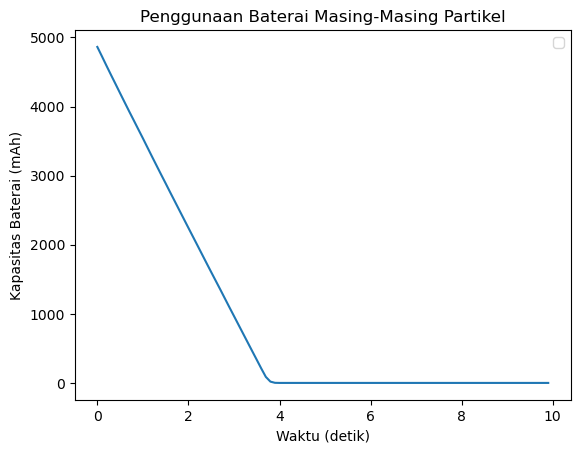

No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.


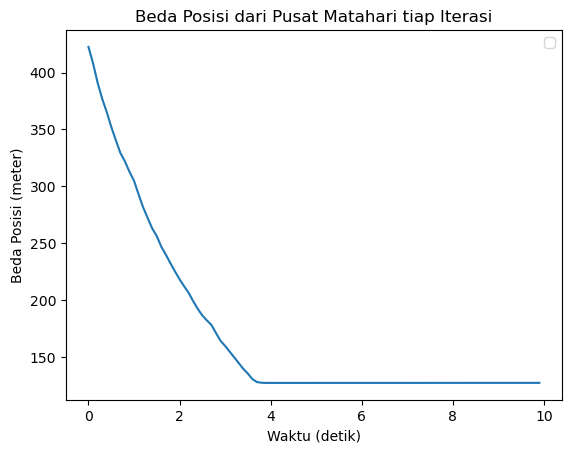

Posisi global terbaik: [456.5360048  541.55043364]
Kapasitas baterai akhir dan persentasenya: 
Drone 1: Kapasitas baterai = 0.0027359179293756954 mAh (5.471835858751391e-05%)
Drone 2: Kapasitas baterai = 0.0027385556202736997 mAh (5.477111240547399e-05%)
Drone 3: Kapasitas baterai = 0.002770823831002585 mAh (5.5416476620051693e-05%)
Drone 4: Kapasitas baterai = 0.0027424032058041207 mAh (5.484806411608241e-05%)
Drone 5: Kapasitas baterai = 0.002765617979394867 mAh (5.5312359587897336e-05%)
Drone 6: Kapasitas baterai = 0.002768387305067941 mAh (5.536774610135883e-05%)
Drone 7: Kapasitas baterai = 0.0027467542357254167 mAh (5.493508471450834e-05%)
Drone 8: Kapasitas baterai = 0.0027656565970824738 mAh (5.531313194164947e-05%)
Drone 9: Kapasitas baterai = 0.002761603072275921 mAh (5.523206144551842e-05%)
Drone 10: Kapasitas baterai = 0.0027671914327934348 mAh (5.53438286558687e-05%)
Drone 11: Kapasitas baterai = 0.00273470120425573 mAh (5.46940240851146e-05%)
Drone 12: Kapasitas baterai =

In [24]:
import os
import numpy as np
import matplotlib.pyplot as plt

def gauss_sun_intensity(x, y, sun_center, sun_std_dev):
    """Intensitas Gaussian berdasarkan jarak dari titik tengah."""
    return np.exp(-((x - sun_center[0])**2 + (y - sun_center[1])**2) / (2 * sun_std_dev**2))

def fitness_function(pos, sun_center, sun_std_dev, particles, index, min_distance, repulsion_factor):
    """Fitness function untuk memaksimalkan intensitas cahaya dan meminimalkan repulsi."""
    sun_intensity = gauss_sun_intensity(pos[0], pos[1], sun_center, sun_std_dev)

    repulsion = 0
    for j in range(len(particles)):
        if j != index:
            distance = np.linalg.norm(pos - particles[j])
            if distance < min_distance:
                repulsion += repulsion_factor / distance**2

    fitness = -sun_intensity + repulsion
    return fitness

def calculate_energy_consumption(mass, altitude, horizontal_distance, battery_voltage):
    """Menghitung parameter energi dari setiap drone."""
    drag_coefficient = 0.5
    frontal_area = 0.1  
    air_density = 1.225  
    horizontal_speed = 10.0  
    flight_efficiency = 0.8

    E_vertical_J = mass * 9.81 * altitude
    P_drag = 0.5 * drag_coefficient * frontal_area * air_density * horizontal_speed**2
    P_horizontal = (P_drag + mass * 9.81 * horizontal_speed) / flight_efficiency
    E_horizontal_J = P_horizontal * (horizontal_distance / horizontal_speed)
    E_total_J = E_vertical_J + E_horizontal_J
    E_total_Wh = E_total_J / 3600
    energy_consumed = (E_total_Wh * 1000) / battery_voltage
    return energy_consumed

def pso_drone_solar_chaser_with_battery():
    num_particles = 20
    num_iterations = 100
    dim = 2  
    c1 = 1.0
    c2 = 1.5  
    w = 0.1  
    timestep = 0.1  # seconds
    L = 1000  # meters

    drone_mass = 2.5 # massa baterai + massa panel surya (massa baterai yang dipakai yaitu variasi 7 kg dan massa panel surya variasi 5, 15, 30 ) 
    battery_capacity = 5000  
    solar_charge_rate = 100  
    altitude = 200  
    battery_voltage = 11.1  

    sun_center = np.array([L / 2, L / 2])  
    sun_std_dev = 1000  
    sun_speed = 1000 / 28800  # 1 km per 8 jam dalam meters per second

    min_distance = 3  
    repulsion_factor = 1000  

    particles = np.random.rand(num_particles, dim) * L  
    velocities = np.zeros((num_particles, dim))  
    personal_best_positions = particles.copy()
    global_best_position = particles[0, :].copy()
    global_best_fitness = float('inf')

    battery_levels = battery_capacity * np.ones(num_particles)  

    battery_levels_over_time = np.zeros((num_iterations, num_particles))
    position_diff_over_time = np.zeros((num_iterations, num_particles))

    # Folder untuk menyimpan hasil program
    folder_name = "Percobaan_223"
    if not os.path.exists(folder_name):
        os.makedirs(folder_name)

    for iter in range(num_iterations):
        for i in range(num_particles):
            fitness = fitness_function(particles[i, :], sun_center, sun_std_dev, particles, i, min_distance, repulsion_factor)
            if fitness < fitness_function(personal_best_positions[i, :], sun_center, sun_std_dev, particles, i, min_distance, repulsion_factor):
                personal_best_positions[i, :] = particles[i, :]
            if fitness < global_best_fitness:
                global_best_fitness = fitness
                global_best_position = particles[i, :]

        for i in range(num_particles):
            velocities[i, :] = (w * velocities[i, :] +
                                c1 * np.random.rand() * (personal_best_positions[i, :] - particles[i, :]) +
                                c2 * np.random.rand() * (global_best_position - particles[i, :]) / drone_mass * timestep)
            new_position = particles[i, :] + velocities[i, :]  
            new_position = np.clip(new_position, 0, L)
            horizontal_distance = np.linalg.norm(new_position - particles[i, :])
            energy_consumed = calculate_energy_consumption(drone_mass, altitude, horizontal_distance, battery_voltage)
            battery_levels[i] -= energy_consumed
            if battery_levels[i] > 0:
                particles[i, :] = new_position
            else:
                battery_levels[i] = 0

        for i in range(num_particles):
            solar_energy = (solar_charge_rate * 
                            max(0, gauss_sun_intensity(particles[i, 0], particles[i, 1], sun_center, sun_std_dev)) * 
                            timestep / 3600)
            battery_levels[i] = min(battery_levels[i] + solar_energy, battery_capacity)

        battery_levels_over_time[iter, :] = battery_levels
        position_diff_over_time[iter, :] = np.linalg.norm(particles - sun_center, axis=1)

        sun_center[0] += sun_speed * timestep  

        if sun_center[0] > L:
            sun_center[0] = 0

        X, Y = np.meshgrid(np.arange(0, L+1, 10), np.arange(0, L+1, 10))  
        Z = np.array([[gauss_sun_intensity(x, y, sun_center, sun_std_dev) for x in np.arange(0, L+1, 10)] for y in np.arange(0, L+1, 10)])
        
        plt.contourf(X, Y, Z)  
        plt.colorbar()
        plt.clim(0, 1)
        plt.title('Distribusi Matahari')
        plt.plot(particles[:, 0], particles[:, 1], '.r')
        plt.savefig(f'{folder_name}/frame_{iter+1}.png')  
        plt.clf()

        print(f'Iterasi ke-{iter + 1}: Global Best Fitness = {global_best_fitness}')


    time = np.arange(num_iterations) * timestep 
    
    plt.figure()
    for i in range(num_particles):
        plt.plot(time, battery_levels_over_time[:, i], label=f'Particle {i+1}')
    plt.title('Penggunaan Baterai Masing-Masing Partikel')
    plt.xlabel('Waktu (detik)')
    plt.ylabel('Kapasitas Baterai (mAh)')
    plt.legend(loc='best')
    plt.savefig(f'{folder_name}/Kapasitas Baterai Tiap Waktu.png')  
    plt.show()
    
    plt.figure()
    for i in range(num_particles):
        plt.plot(time, position_diff_over_time[:, i], label=f'Particle {i+1}')
    plt.title('Beda Posisi dari Pusat Matahari tiap Waktu')
    plt.xlabel('Waktu (detik)')
    plt.ylabel('Beda Posisi (meter)')
    plt.legend(loc='best')
    plt.savefig(f'{folder_name}/beda_posisi tiap waktu.png')  
    plt.show()

    print(f'Posisi global terbaik: {global_best_position}')
    print('Kapasitas baterai akhir dan persentasenya: ')
    for i in range(num_particles):
        battery_percentage = (battery_levels[i] / battery_capacity) * 100
        print(f'Drone {i + 1}: Kapasitas baterai = {battery_levels[i]} mAh ({battery_percentage}%)')

if __name__ == "__main__":
    pso_drone_solar_chaser_with_battery()


### Percobaan ketiga
#### Variasi Jumlah Partikel

c1 = 1

c2 = 1,5

w = 1,0

jumlah partikel = 10

massa drone = 2,5

kapasitas baterai = 5000

Iterasi ke-1: Global Best Fitness = -0.9968160136194603
Iterasi ke-2: Global Best Fitness = -0.9968161591822389
Iterasi ke-3: Global Best Fitness = -0.9968163047330209
Iterasi ke-4: Global Best Fitness = -0.9968164502718061
Iterasi ke-5: Global Best Fitness = -0.9968165957985946
Iterasi ke-6: Global Best Fitness = -0.9968167413133864
Iterasi ke-7: Global Best Fitness = -0.9968168868161815
Iterasi ke-8: Global Best Fitness = -0.9968170323069799
Iterasi ke-9: Global Best Fitness = -0.9968171777857816
Iterasi ke-10: Global Best Fitness = -0.9968173232525865
Iterasi ke-11: Global Best Fitness = -0.9968174687073948
Iterasi ke-12: Global Best Fitness = -0.9968176141502063
Iterasi ke-13: Global Best Fitness = -0.996817759581021
Iterasi ke-14: Global Best Fitness = -0.9968179049998391
Iterasi ke-15: Global Best Fitness = -0.9968180504066604
Iterasi ke-16: Global Best Fitness = -0.9968181958014849
Iterasi ke-17: Global Best Fitness = -0.9968183411843126
Iterasi ke-18: Global Best Fitness = -0.9

<Figure size 640x480 with 0 Axes>

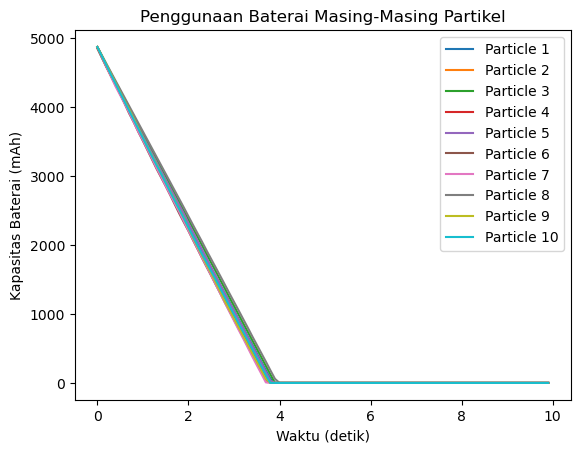

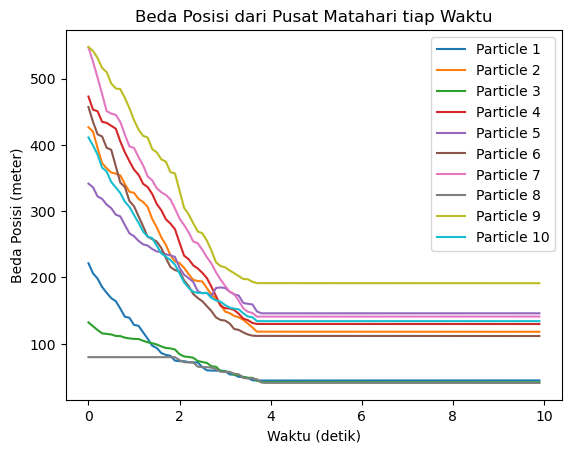

Posisi global terbaik: [518.42768262 463.19840069]
Kapasitas baterai akhir dan persentasenya: 
Drone 1: Kapasitas baterai = 0.002774992316283102 mAh (5.549984632566204e-05%)
Drone 2: Kapasitas baterai = 0.002758465257042702 mAh (5.5169305140854045e-05%)
Drone 3: Kapasitas baterai = 0.002775333044182792 mAh (5.550666088365584e-05%)
Drone 4: Kapasitas baterai = 0.0027544561276501276 mAh (5.508912255300255e-05%)
Drone 5: Kapasitas baterai = 0.002748335149309252 mAh (5.496670298618505e-05%)
Drone 6: Kapasitas baterai = 0.0027604917034751634 mAh (5.520983406950327e-05%)
Drone 7: Kapasitas baterai = 0.00275025579874392 mAh (5.50051159748784e-05%)
Drone 8: Kapasitas baterai = 0.0027754435003281715 mAh (5.550887000656343e-05%)
Drone 9: Kapasitas baterai = 0.0027273804406570327 mAh (5.454760881314065e-05%)
Drone 10: Kapasitas baterai = 0.0027528871899855836 mAh (5.505774379971167e-05%)


In [14]:
import os
import numpy as np
import matplotlib.pyplot as plt

def gauss_sun_intensity(x, y, sun_center, sun_std_dev):
    """Intensitas Gaussian berdasarkan jarak dari titik tengah."""
    return np.exp(-((x - sun_center[0])**2 + (y - sun_center[1])**2) / (2 * sun_std_dev**2))

def fitness_function(pos, sun_center, sun_std_dev, particles, index, min_distance, repulsion_factor):
    """Fitness function untuk memaksimalkan intensitas cahaya dan meminimalkan repulsi."""
    sun_intensity = gauss_sun_intensity(pos[0], pos[1], sun_center, sun_std_dev)

    repulsion = 0
    for j in range(len(particles)):
        if j != index:
            distance = np.linalg.norm(pos - particles[j])
            if distance < min_distance:
                repulsion += repulsion_factor / distance**2

    fitness = -sun_intensity + repulsion
    return fitness

def calculate_energy_consumption(mass, altitude, horizontal_distance, battery_voltage):
    """Menghitung parameter energi dari setiap drone."""
    drag_coefficient = 0.5
    frontal_area = 0.1  
    air_density = 1.225  
    horizontal_speed = 10.0  
    flight_efficiency = 0.8

    E_vertical_J = mass * 9.81 * altitude
    P_drag = 0.5 * drag_coefficient * frontal_area * air_density * horizontal_speed**2
    P_horizontal = (P_drag + mass * 9.81 * horizontal_speed) / flight_efficiency
    E_horizontal_J = P_horizontal * (horizontal_distance / horizontal_speed)
    E_total_J = E_vertical_J + E_horizontal_J
    E_total_Wh = E_total_J / 3600
    energy_consumed = (E_total_Wh * 1000) / battery_voltage
    return energy_consumed

def pso_drone_solar_chaser_with_battery():
    num_particles = 10
    num_iterations = 100
    dim = 2  
    c1 = 1.0
    c2 = 1.5  
    w = 0.1  
    timestep = 0.1  # seconds
    L = 1000  # meters

    drone_mass = 2.5 # massa baterai + massa panel surya (massa baterai yang dipakai yaitu variasi 7 kg dan massa panel surya variasi 5, 15, 30 ) 
    battery_capacity = 5000  
    solar_charge_rate = 100  
    altitude = 200  
    battery_voltage = 11.1  

    sun_center = np.array([L / 2, L / 2])  
    sun_std_dev = 1000  
    sun_speed = 1000 / 28800  # 1 km per 8 jam dalam meters per second

    min_distance = 3  
    repulsion_factor = 1000  

    particles = np.random.rand(num_particles, dim) * L  
    velocities = np.zeros((num_particles, dim))  
    personal_best_positions = particles.copy()
    global_best_position = particles[0, :].copy()
    global_best_fitness = float('inf')

    battery_levels = battery_capacity * np.ones(num_particles)  

    battery_levels_over_time = np.zeros((num_iterations, num_particles))
    position_diff_over_time = np.zeros((num_iterations, num_particles))

    # Folder untuk menyimpan hasil program
    folder_name = "Percobaan_311"
    if not os.path.exists(folder_name):
        os.makedirs(folder_name)

    for iter in range(num_iterations):
        for i in range(num_particles):
            fitness = fitness_function(particles[i, :], sun_center, sun_std_dev, particles, i, min_distance, repulsion_factor)
            if fitness < fitness_function(personal_best_positions[i, :], sun_center, sun_std_dev, particles, i, min_distance, repulsion_factor):
                personal_best_positions[i, :] = particles[i, :]
            if fitness < global_best_fitness:
                global_best_fitness = fitness
                global_best_position = particles[i, :]

        for i in range(num_particles):
            velocities[i, :] = (w * velocities[i, :] +
                                c1 * np.random.rand() * (personal_best_positions[i, :] - particles[i, :]) +
                                c2 * np.random.rand() * (global_best_position - particles[i, :]) / drone_mass * timestep)
            new_position = particles[i, :] + velocities[i, :]  
            new_position = np.clip(new_position, 0, L)
            horizontal_distance = np.linalg.norm(new_position - particles[i, :])
            energy_consumed = calculate_energy_consumption(drone_mass, altitude, horizontal_distance, battery_voltage)
            battery_levels[i] -= energy_consumed
            if battery_levels[i] > 0:
                particles[i, :] = new_position
            else:
                battery_levels[i] = 0

        for i in range(num_particles):
            solar_energy = (solar_charge_rate * 
                            max(0, gauss_sun_intensity(particles[i, 0], particles[i, 1], sun_center, sun_std_dev)) * 
                            timestep / 3600)
            battery_levels[i] = min(battery_levels[i] + solar_energy, battery_capacity)

        battery_levels_over_time[iter, :] = battery_levels
        position_diff_over_time[iter, :] = np.linalg.norm(particles - sun_center, axis=1)

        sun_center[0] += sun_speed * timestep  

        if sun_center[0] > L:
            sun_center[0] = 0

        X, Y = np.meshgrid(np.arange(0, L+1, 10), np.arange(0, L+1, 10))  
        Z = np.array([[gauss_sun_intensity(x, y, sun_center, sun_std_dev) for x in np.arange(0, L+1, 10)] for y in np.arange(0, L+1, 10)])
        
        plt.contourf(X, Y, Z)  
        plt.colorbar()
        plt.clim(0, 1)
        plt.title('Distribusi Matahari')
        plt.plot(particles[:, 0], particles[:, 1], '.r')
        plt.savefig(f'{folder_name}/frame_{iter+1}.png')  
        plt.clf()

        print(f'Iterasi ke-{iter + 1}: Global Best Fitness = {global_best_fitness}')

    time = np.arange(num_iterations) * timestep 
    
    plt.figure()
    for i in range(num_particles):
        plt.plot(time, battery_levels_over_time[:, i], label=f'Particle {i+1}')
    plt.title('Penggunaan Baterai Masing-Masing Partikel')
    plt.xlabel('Waktu (detik)')
    plt.ylabel('Kapasitas Baterai (mAh)')
    plt.legend(loc='best')
    plt.savefig(f'{folder_name}/Kapasitas Baterai Tiap Waktu.png')  
    plt.show()
    
    plt.figure()
    for i in range(num_particles):
        plt.plot(time, position_diff_over_time[:, i], label=f'Particle {i+1}')
    plt.title('Beda Posisi dari Pusat Matahari tiap Waktu')
    plt.xlabel('Waktu (detik)')
    plt.ylabel('Beda Posisi (meter)')
    plt.legend(loc='best')
    plt.savefig(f'{folder_name}/beda_posisi tiap waktu.png')  
    plt.show()

    print(f'Posisi global terbaik: {global_best_position}')
    print('Kapasitas baterai akhir dan persentasenya: ')
    for i in range(num_particles):
        battery_percentage = (battery_levels[i] / battery_capacity) * 100
        print(f'Drone {i + 1}: Kapasitas baterai = {battery_levels[i]} mAh ({battery_percentage}%)')

if __name__ == "__main__":
    pso_drone_solar_chaser_with_battery()


c1 = 1

c2 = 1,5

w = 1,0

jumlah partikel = 20

massa drone = 2,5

kapasitas baterai = 5000

Iterasi ke-1: Global Best Fitness = -0.9910398665691255
Iterasi ke-2: Global Best Fitness = -0.9910398665691255
Iterasi ke-3: Global Best Fitness = -0.9910398665691255
Iterasi ke-4: Global Best Fitness = -0.9910398665691255
Iterasi ke-5: Global Best Fitness = -0.9910398665691255
Iterasi ke-6: Global Best Fitness = -0.9910398665691255
Iterasi ke-7: Global Best Fitness = -0.9910398665691255
Iterasi ke-8: Global Best Fitness = -0.9910398665691255
Iterasi ke-9: Global Best Fitness = -0.9910398665691255
Iterasi ke-10: Global Best Fitness = -0.9910398665691255
Iterasi ke-11: Global Best Fitness = -0.9910398665691255
Iterasi ke-12: Global Best Fitness = -0.9910398665691255
Iterasi ke-13: Global Best Fitness = -0.9910398665691255
Iterasi ke-14: Global Best Fitness = -0.9910398665691255
Iterasi ke-15: Global Best Fitness = -0.9910398665691255
Iterasi ke-16: Global Best Fitness = -0.9910398665691255
Iterasi ke-17: Global Best Fitness = -0.9910398665691255
Iterasi ke-18: Global Best Fitness = -0.

No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.


Iterasi ke-99: Global Best Fitness = -0.9969819429130866
Iterasi ke-100: Global Best Fitness = -0.9969819429130866


<Figure size 640x480 with 0 Axes>

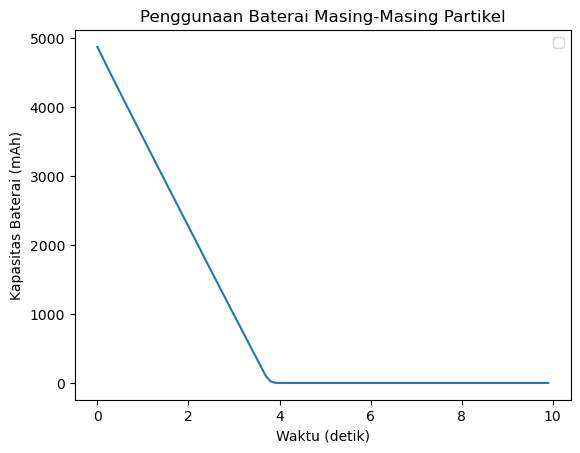

No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.


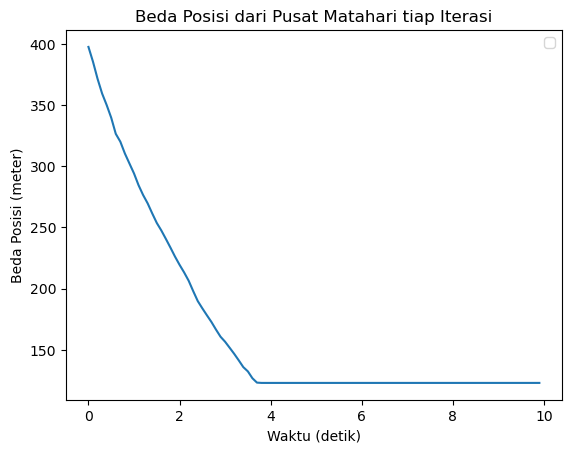

Posisi global terbaik: [475.28579731 426.32681879]
Kapasitas baterai akhir dan persentasenya: 
Drone 1: Kapasitas baterai = 0.0027593167360641948 mAh (5.518633472128389e-05%)
Drone 2: Kapasitas baterai = 0.002757753214758823 mAh (5.515506429517646e-05%)
Drone 3: Kapasitas baterai = 0.002758273659591328 mAh (5.516547319182656e-05%)
Drone 4: Kapasitas baterai = 0.0027693223567858125 mAh (5.538644713571625e-05%)
Drone 5: Kapasitas baterai = 0.0027504400176643884 mAh (5.500880035328777e-05%)
Drone 6: Kapasitas baterai = 0.002769379888642023 mAh (5.538759777284046e-05%)
Drone 7: Kapasitas baterai = 0.0027244403275078484 mAh (5.448880655015697e-05%)
Drone 8: Kapasitas baterai = 0.002765569560180993 mAh (5.531139120361986e-05%)
Drone 9: Kapasitas baterai = 0.0027683789693062682 mAh (5.536757938612536e-05%)
Drone 10: Kapasitas baterai = 0.0027410721737960004 mAh (5.4821443475920004e-05%)
Drone 11: Kapasitas baterai = 0.0027417166909561295 mAh (5.4834333819122596e-05%)
Drone 12: Kapasitas bater

In [26]:
import os
import numpy as np
import matplotlib.pyplot as plt

def gauss_sun_intensity(x, y, sun_center, sun_std_dev):
    """Intensitas Gaussian berdasarkan jarak dari titik tengah."""
    return np.exp(-((x - sun_center[0])**2 + (y - sun_center[1])**2) / (2 * sun_std_dev**2))

def fitness_function(pos, sun_center, sun_std_dev, particles, index, min_distance, repulsion_factor):
    """Fitness function untuk memaksimalkan intensitas cahaya dan meminimalkan repulsi."""
    sun_intensity = gauss_sun_intensity(pos[0], pos[1], sun_center, sun_std_dev)

    repulsion = 0
    for j in range(len(particles)):
        if j != index:
            distance = np.linalg.norm(pos - particles[j])
            if distance < min_distance:
                repulsion += repulsion_factor / distance**2

    fitness = -sun_intensity + repulsion
    return fitness

def calculate_energy_consumption(mass, altitude, horizontal_distance, battery_voltage):
    """Menghitung parameter energi dari setiap drone."""
    drag_coefficient = 0.5
    frontal_area = 0.1  
    air_density = 1.225  
    horizontal_speed = 10.0  
    flight_efficiency = 0.8

    E_vertical_J = mass * 9.81 * altitude
    P_drag = 0.5 * drag_coefficient * frontal_area * air_density * horizontal_speed**2
    P_horizontal = (P_drag + mass * 9.81 * horizontal_speed) / flight_efficiency
    E_horizontal_J = P_horizontal * (horizontal_distance / horizontal_speed)
    E_total_J = E_vertical_J + E_horizontal_J
    E_total_Wh = E_total_J / 3600
    energy_consumed = (E_total_Wh * 1000) / battery_voltage
    return energy_consumed

def pso_drone_solar_chaser_with_battery():
    num_particles = 20
    num_iterations = 100
    dim = 2  
    c1 = 1.0
    c2 = 1.5  
    w = 0.1  
    timestep = 0.1  # seconds
    L = 1000  # meters

    drone_mass = 2.5 # massa baterai + massa panel surya (massa baterai yang dipakai yaitu variasi 7 kg dan massa panel surya variasi 5, 15, 30 ) 
    battery_capacity = 5000  
    solar_charge_rate = 100  
    altitude = 200  
    battery_voltage = 11.1  

    sun_center = np.array([L / 2, L / 2])  
    sun_std_dev = 1000  
    sun_speed = 1000 / 28800  # 1 km per 8 jam dalam meters per second

    min_distance = 3  
    repulsion_factor = 1000  

    particles = np.random.rand(num_particles, dim) * L  
    velocities = np.zeros((num_particles, dim))  
    personal_best_positions = particles.copy()
    global_best_position = particles[0, :].copy()
    global_best_fitness = float('inf')

    battery_levels = battery_capacity * np.ones(num_particles)  

    battery_levels_over_time = np.zeros((num_iterations, num_particles))
    position_diff_over_time = np.zeros((num_iterations, num_particles))

    # Folder untuk menyimpan hasil program
    folder_name = "Percobaan_312"
    if not os.path.exists(folder_name):
        os.makedirs(folder_name)

    for iter in range(num_iterations):
        for i in range(num_particles):
            fitness = fitness_function(particles[i, :], sun_center, sun_std_dev, particles, i, min_distance, repulsion_factor)
            if fitness < fitness_function(personal_best_positions[i, :], sun_center, sun_std_dev, particles, i, min_distance, repulsion_factor):
                personal_best_positions[i, :] = particles[i, :]
            if fitness < global_best_fitness:
                global_best_fitness = fitness
                global_best_position = particles[i, :]

        for i in range(num_particles):
            velocities[i, :] = (w * velocities[i, :] +
                                c1 * np.random.rand() * (personal_best_positions[i, :] - particles[i, :]) +
                                c2 * np.random.rand() * (global_best_position - particles[i, :]) / drone_mass * timestep)
            new_position = particles[i, :] + velocities[i, :]  
            new_position = np.clip(new_position, 0, L)
            horizontal_distance = np.linalg.norm(new_position - particles[i, :])
            energy_consumed = calculate_energy_consumption(drone_mass, altitude, horizontal_distance, battery_voltage)
            battery_levels[i] -= energy_consumed
            if battery_levels[i] > 0:
                particles[i, :] = new_position
            else:
                battery_levels[i] = 0

        for i in range(num_particles):
            solar_energy = (solar_charge_rate * 
                            max(0, gauss_sun_intensity(particles[i, 0], particles[i, 1], sun_center, sun_std_dev)) * 
                            timestep / 3600)
            battery_levels[i] = min(battery_levels[i] + solar_energy, battery_capacity)

        battery_levels_over_time[iter, :] = battery_levels
        position_diff_over_time[iter, :] = np.linalg.norm(particles - sun_center, axis=1)

        sun_center[0] += sun_speed * timestep  

        if sun_center[0] > L:
            sun_center[0] = 0

        X, Y = np.meshgrid(np.arange(0, L+1, 10), np.arange(0, L+1, 10))  
        Z = np.array([[gauss_sun_intensity(x, y, sun_center, sun_std_dev) for x in np.arange(0, L+1, 10)] for y in np.arange(0, L+1, 10)])
        
        plt.contourf(X, Y, Z)  
        plt.colorbar()
        plt.clim(0, 1)
        plt.title('Distribusi Matahari')
        plt.plot(particles[:, 0], particles[:, 1], '.r')
        plt.savefig(f'{folder_name}/frame_{iter+1}.png')  
        plt.clf()

        print(f'Iterasi ke-{iter + 1}: Global Best Fitness = {global_best_fitness}')

    time = np.arange(num_iterations) * timestep 
    
    plt.figure()
    for i in range(num_particles):
        plt.plot(time, battery_levels_over_time[:, i], label=f'Particle {i+1}')
    plt.title('Penggunaan Baterai Masing-Masing Partikel')
    plt.xlabel('Waktu (detik)')
    plt.ylabel('Kapasitas Baterai (mAh)')
    plt.legend(loc='best')
    plt.savefig(f'{folder_name}/Kapasitas Baterai Tiap Waktu.png')  
    plt.show()
    
    plt.figure()
    for i in range(num_particles):
        plt.plot(time, position_diff_over_time[:, i], label=f'Particle {i+1}')
    plt.title('Beda Posisi dari Pusat Matahari tiap Waktu')
    plt.xlabel('Waktu (detik)')
    plt.ylabel('Beda Posisi (meter)')
    plt.legend(loc='best')
    plt.savefig(f'{folder_name}/beda_posisi tiap waktu.png')  
    plt.show()

    print(f'Posisi global terbaik: {global_best_position}')
    print('Kapasitas baterai akhir dan persentasenya: ')
    for i in range(num_particles):
        battery_percentage = (battery_levels[i] / battery_capacity) * 100
        print(f'Drone {i + 1}: Kapasitas baterai = {battery_levels[i]} mAh ({battery_percentage}%)')

if __name__ == "__main__":
    pso_drone_solar_chaser_with_battery()


c1 = 1

c2 = 1,5

w = 1,0

jumlah partikel = 30

massa drone = 2,5

kapasitas baterai = 5000

Iterasi ke-1: Global Best Fitness = -0.9867945739233395
Iterasi ke-2: Global Best Fitness = -0.9884236624465522
Iterasi ke-3: Global Best Fitness = -0.9886327816493349
Iterasi ke-4: Global Best Fitness = -0.9891397486124991
Iterasi ke-5: Global Best Fitness = -0.9897977168339819
Iterasi ke-6: Global Best Fitness = -0.9904030317312839
Iterasi ke-7: Global Best Fitness = -0.990516629509702
Iterasi ke-8: Global Best Fitness = -0.9909304810334967
Iterasi ke-9: Global Best Fitness = -0.9918246342102556
Iterasi ke-10: Global Best Fitness = -0.9922784659302157
Iterasi ke-11: Global Best Fitness = -0.9929608598984837
Iterasi ke-12: Global Best Fitness = -0.9930587587682361
Iterasi ke-13: Global Best Fitness = -0.9942622451190605
Iterasi ke-14: Global Best Fitness = -0.9944091905261139
Iterasi ke-15: Global Best Fitness = -0.9944235369115306
Iterasi ke-16: Global Best Fitness = -0.9946919215664571
Iterasi ke-17: Global Best Fitness = -0.9950847505935877
Iterasi ke-18: Global Best Fitness = -0.9

No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.


Iterasi ke-100: Global Best Fitness = -0.9989637557015729


<Figure size 640x480 with 0 Axes>

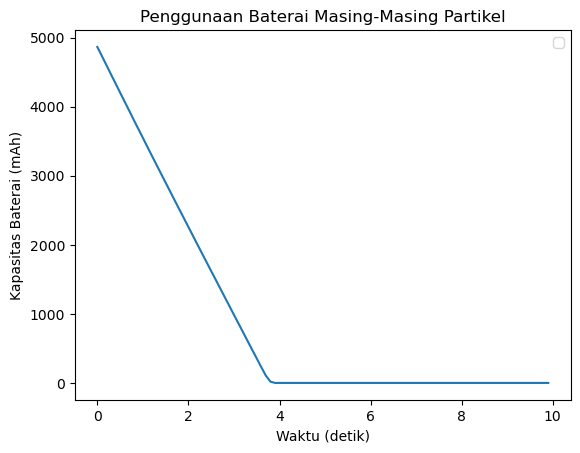

No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.


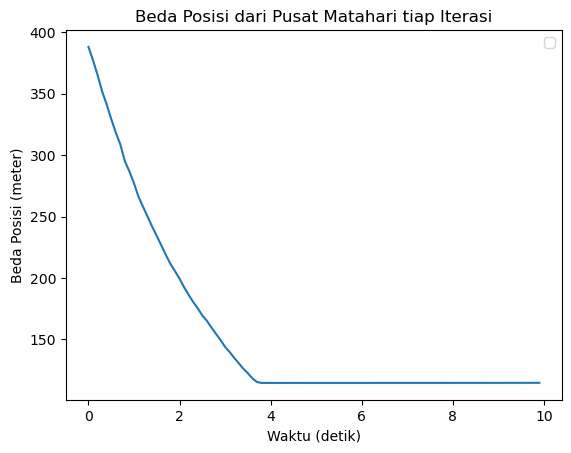

Posisi global terbaik: [515.00966257 543.11002378]
Kapasitas baterai akhir dan persentasenya: 
Drone 1: Kapasitas baterai = 0.0027472057348461366 mAh (5.494411469692274e-05%)
Drone 2: Kapasitas baterai = 0.0027748558541564115 mAh (5.549711708312823e-05%)
Drone 3: Kapasitas baterai = 0.002764012713282783 mAh (5.5280254265655656e-05%)
Drone 4: Kapasitas baterai = 0.0027704382093898215 mAh (5.540876418779643e-05%)
Drone 5: Kapasitas baterai = 0.0027302512807650605 mAh (5.460502561530121e-05%)
Drone 6: Kapasitas baterai = 0.002752619299896269 mAh (5.5052385997925376e-05%)
Drone 7: Kapasitas baterai = 0.0027614087560600947 mAh (5.5228175121201896e-05%)
Drone 8: Kapasitas baterai = 0.0027700153069257554 mAh (5.540030613851511e-05%)
Drone 9: Kapasitas baterai = 0.002750959111947498 mAh (5.501918223894997e-05%)
Drone 10: Kapasitas baterai = 0.0027700932856426974 mAh (5.540186571285395e-05%)
Drone 11: Kapasitas baterai = 0.0027695042299562163 mAh (5.5390084599124327e-05%)
Drone 12: Kapasitas ba

In [27]:
import os
import numpy as np
import matplotlib.pyplot as plt

def gauss_sun_intensity(x, y, sun_center, sun_std_dev):
    """Intensitas Gaussian berdasarkan jarak dari titik tengah."""
    return np.exp(-((x - sun_center[0])**2 + (y - sun_center[1])**2) / (2 * sun_std_dev**2))

def fitness_function(pos, sun_center, sun_std_dev, particles, index, min_distance, repulsion_factor):
    """Fitness function untuk memaksimalkan intensitas cahaya dan meminimalkan repulsi."""
    sun_intensity = gauss_sun_intensity(pos[0], pos[1], sun_center, sun_std_dev)

    repulsion = 0
    for j in range(len(particles)):
        if j != index:
            distance = np.linalg.norm(pos - particles[j])
            if distance < min_distance:
                repulsion += repulsion_factor / distance**2

    fitness = -sun_intensity + repulsion
    return fitness

def calculate_energy_consumption(mass, altitude, horizontal_distance, battery_voltage):
    """Menghitung parameter energi dari setiap drone."""
    drag_coefficient = 0.5
    frontal_area = 0.1  
    air_density = 1.225  
    horizontal_speed = 10.0  
    flight_efficiency = 0.8

    E_vertical_J = mass * 9.81 * altitude
    P_drag = 0.5 * drag_coefficient * frontal_area * air_density * horizontal_speed**2
    P_horizontal = (P_drag + mass * 9.81 * horizontal_speed) / flight_efficiency
    E_horizontal_J = P_horizontal * (horizontal_distance / horizontal_speed)
    E_total_J = E_vertical_J + E_horizontal_J
    E_total_Wh = E_total_J / 3600
    energy_consumed = (E_total_Wh * 1000) / battery_voltage
    return energy_consumed

def pso_drone_solar_chaser_with_battery():
    num_particles = 30
    num_iterations = 100
    dim = 2  
    c1 = 1.0
    c2 = 1.5  
    w = 0.1  
    timestep = 0.1  # seconds
    L = 1000  # meters

    drone_mass = 2.5 # massa baterai + massa panel surya (massa baterai yang dipakai yaitu variasi 7 kg dan massa panel surya variasi 5, 15, 30 ) 
    battery_capacity = 5000  
    solar_charge_rate = 100  
    altitude = 200  
    battery_voltage = 11.1  

    sun_center = np.array([L / 2, L / 2])  
    sun_std_dev = 1000  
    sun_speed = 1000 / 28800  # 1 km per 8 jam dalam meters per second

    min_distance = 3  
    repulsion_factor = 1000  

    particles = np.random.rand(num_particles, dim) * L  
    velocities = np.zeros((num_particles, dim))  
    personal_best_positions = particles.copy()
    global_best_position = particles[0, :].copy()
    global_best_fitness = float('inf')

    battery_levels = battery_capacity * np.ones(num_particles)  

    battery_levels_over_time = np.zeros((num_iterations, num_particles))
    position_diff_over_time = np.zeros((num_iterations, num_particles))

    # Folder untuk menyimpan hasil program
    folder_name = "Percobaan_313"
    if not os.path.exists(folder_name):
        os.makedirs(folder_name)

    for iter in range(num_iterations):
        for i in range(num_particles):
            fitness = fitness_function(particles[i, :], sun_center, sun_std_dev, particles, i, min_distance, repulsion_factor)
            if fitness < fitness_function(personal_best_positions[i, :], sun_center, sun_std_dev, particles, i, min_distance, repulsion_factor):
                personal_best_positions[i, :] = particles[i, :]
            if fitness < global_best_fitness:
                global_best_fitness = fitness
                global_best_position = particles[i, :]

        for i in range(num_particles):
            velocities[i, :] = (w * velocities[i, :] +
                                c1 * np.random.rand() * (personal_best_positions[i, :] - particles[i, :]) +
                                c2 * np.random.rand() * (global_best_position - particles[i, :]) / drone_mass * timestep)
            new_position = particles[i, :] + velocities[i, :]  
            new_position = np.clip(new_position, 0, L)
            horizontal_distance = np.linalg.norm(new_position - particles[i, :])
            energy_consumed = calculate_energy_consumption(drone_mass, altitude, horizontal_distance, battery_voltage)
            battery_levels[i] -= energy_consumed
            if battery_levels[i] > 0:
                particles[i, :] = new_position
            else:
                battery_levels[i] = 0

        for i in range(num_particles):
            solar_energy = (solar_charge_rate * 
                            max(0, gauss_sun_intensity(particles[i, 0], particles[i, 1], sun_center, sun_std_dev)) * 
                            timestep / 3600)
            battery_levels[i] = min(battery_levels[i] + solar_energy, battery_capacity)

        battery_levels_over_time[iter, :] = battery_levels
        position_diff_over_time[iter, :] = np.linalg.norm(particles - sun_center, axis=1)

        sun_center[0] += sun_speed * timestep  

        if sun_center[0] > L:
            sun_center[0] = 0

        X, Y = np.meshgrid(np.arange(0, L+1, 10), np.arange(0, L+1, 10))  
        Z = np.array([[gauss_sun_intensity(x, y, sun_center, sun_std_dev) for x in np.arange(0, L+1, 10)] for y in np.arange(0, L+1, 10)])
        
        plt.contourf(X, Y, Z)  
        plt.colorbar()
        plt.clim(0, 1)
        plt.title('Distribusi Matahari')
        plt.plot(particles[:, 0], particles[:, 1], '.r')
        plt.savefig(f'{folder_name}/frame_{iter+1}.png')  
        plt.clf()

        print(f'Iterasi ke-{iter + 1}: Global Best Fitness = {global_best_fitness}')

    time = np.arange(num_iterations) * timestep 
    
    plt.figure()
    for i in range(num_particles):
        plt.plot(time, battery_levels_over_time[:, i], label=f'Particle {i+1}')
    plt.title('Penggunaan Baterai Masing-Masing Partikel')
    plt.xlabel('Waktu (detik)')
    plt.ylabel('Kapasitas Baterai (mAh)')
    plt.legend(loc='best')
    plt.savefig(f'{folder_name}/Kapasitas Baterai Tiap Waktu.png')  
    plt.show()
    
    plt.figure()
    for i in range(num_particles):
        plt.plot(time, position_diff_over_time[:, i], label=f'Particle {i+1}')
    plt.title('Beda Posisi dari Pusat Matahari tiap Waktu')
    plt.xlabel('Waktu (detik)')
    plt.ylabel('Beda Posisi (meter)')
    plt.legend(loc='best')
    plt.savefig(f'{folder_name}/beda_posisi tiap waktu.png')  
    plt.show()

    print(f'Posisi global terbaik: {global_best_position}')
    print('Kapasitas baterai akhir dan persentasenya: ')
    for i in range(num_particles):
        battery_percentage = (battery_levels[i] / battery_capacity) * 100
        print(f'Drone {i + 1}: Kapasitas baterai = {battery_levels[i]} mAh ({battery_percentage}%)')

if __name__ == "__main__":
    pso_drone_solar_chaser_with_battery()


c1 = 1

c2 = 1,5

w = 1,0

jumlah partikel = 40

massa drone = 2,5

kapasitas baterai = 5000

Iterasi ke-1: Global Best Fitness = -0.9991935853351388
Iterasi ke-2: Global Best Fitness = -0.9991936604290791
Iterasi ke-3: Global Best Fitness = -0.9991937355109785
Iterasi ke-4: Global Best Fitness = -0.9991938105808368
Iterasi ke-5: Global Best Fitness = -0.9991938856386542
Iterasi ke-6: Global Best Fitness = -0.9991939606844307
Iterasi ke-7: Global Best Fitness = -0.9991940357181661
Iterasi ke-8: Global Best Fitness = -0.9991941107398606
Iterasi ke-9: Global Best Fitness = -0.9991941857495141
Iterasi ke-10: Global Best Fitness = -0.9991942607471266
Iterasi ke-11: Global Best Fitness = -0.9991943357326981
Iterasi ke-12: Global Best Fitness = -0.9991944107062287
Iterasi ke-13: Global Best Fitness = -0.9992642898658382
Iterasi ke-14: Global Best Fitness = -0.9992866350426289
Iterasi ke-15: Global Best Fitness = -0.9993611525592806
Iterasi ke-16: Global Best Fitness = -0.9993692188235623
Iterasi ke-17: Global Best Fitness = -0.9994095907374274
Iterasi ke-18: Global Best Fitness = -0.

No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.


Iterasi ke-100: Global Best Fitness = -0.999856887856526


<Figure size 640x480 with 0 Axes>

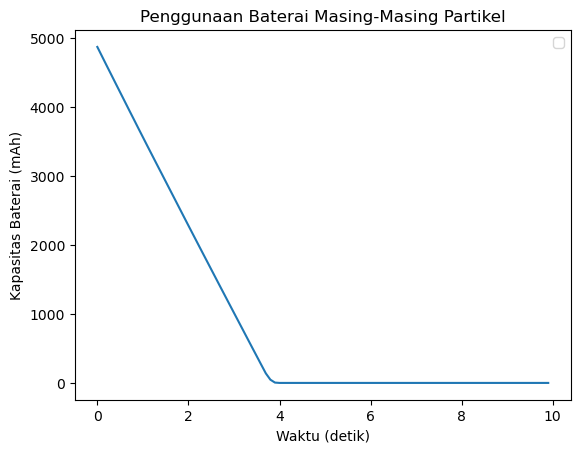

No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.


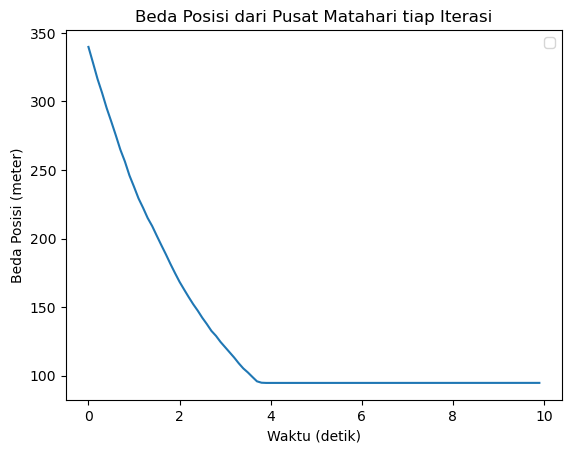

Posisi global terbaik: [505.52390659 483.89376681]
Kapasitas baterai akhir dan persentasenya: 
Drone 1: Kapasitas baterai = 0.002763394021810548 mAh (5.5267880436210955e-05%)
Drone 2: Kapasitas baterai = 0.0027749021851858073 mAh (5.549804370371615e-05%)
Drone 3: Kapasitas baterai = 0.0027579192559409028 mAh (5.515838511881806e-05%)
Drone 4: Kapasitas baterai = 0.002734389900386909 mAh (5.4687798007738184e-05%)
Drone 5: Kapasitas baterai = 0.0027705600099167367 mAh (5.541120019833474e-05%)
Drone 6: Kapasitas baterai = 0.002769131184933613 mAh (5.538262369867225e-05%)
Drone 7: Kapasitas baterai = 0.0027446832745312384 mAh (5.489366549062477e-05%)
Drone 8: Kapasitas baterai = 0.0027703066481408628 mAh (5.540613296281726e-05%)
Drone 9: Kapasitas baterai = 0.0027404219140994605 mAh (5.480843828198921e-05%)
Drone 10: Kapasitas baterai = 0.002763797283749398 mAh (5.527594567498796e-05%)
Drone 11: Kapasitas baterai = 0.0027449039192727594 mAh (5.4898078385455186e-05%)
Drone 12: Kapasitas bate

In [28]:
import os
import numpy as np
import matplotlib.pyplot as plt

def gauss_sun_intensity(x, y, sun_center, sun_std_dev):
    """Intensitas Gaussian berdasarkan jarak dari titik tengah."""
    return np.exp(-((x - sun_center[0])**2 + (y - sun_center[1])**2) / (2 * sun_std_dev**2))

def fitness_function(pos, sun_center, sun_std_dev, particles, index, min_distance, repulsion_factor):
    """Fitness function untuk memaksimalkan intensitas cahaya dan meminimalkan repulsi."""
    sun_intensity = gauss_sun_intensity(pos[0], pos[1], sun_center, sun_std_dev)

    repulsion = 0
    for j in range(len(particles)):
        if j != index:
            distance = np.linalg.norm(pos - particles[j])
            if distance < min_distance:
                repulsion += repulsion_factor / distance**2

    fitness = -sun_intensity + repulsion
    return fitness

def calculate_energy_consumption(mass, altitude, horizontal_distance, battery_voltage):
    """Menghitung parameter energi dari setiap drone."""
    drag_coefficient = 0.5
    frontal_area = 0.1  
    air_density = 1.225  
    horizontal_speed = 10.0  
    flight_efficiency = 0.8

    E_vertical_J = mass * 9.81 * altitude
    P_drag = 0.5 * drag_coefficient * frontal_area * air_density * horizontal_speed**2
    P_horizontal = (P_drag + mass * 9.81 * horizontal_speed) / flight_efficiency
    E_horizontal_J = P_horizontal * (horizontal_distance / horizontal_speed)
    E_total_J = E_vertical_J + E_horizontal_J
    E_total_Wh = E_total_J / 3600
    energy_consumed = (E_total_Wh * 1000) / battery_voltage
    return energy_consumed

def pso_drone_solar_chaser_with_battery():
    num_particles = 40
    num_iterations = 100
    dim = 2  
    c1 = 1.0
    c2 = 1.5  
    w = 0.1  
    timestep = 0.1  # seconds
    L = 1000  # meters

    drone_mass = 2.5 # massa baterai + massa panel surya (massa baterai yang dipakai yaitu variasi 7 kg dan massa panel surya variasi 5, 15, 30 ) 
    battery_capacity = 5000  
    solar_charge_rate = 100  
    altitude = 200  
    battery_voltage = 11.1  

    sun_center = np.array([L / 2, L / 2])  
    sun_std_dev = 1000  
    sun_speed = 1000 / 28800  # 1 km per 8 jam dalam meters per second

    min_distance = 3  
    repulsion_factor = 1000  

    particles = np.random.rand(num_particles, dim) * L  
    velocities = np.zeros((num_particles, dim))  
    personal_best_positions = particles.copy()
    global_best_position = particles[0, :].copy()
    global_best_fitness = float('inf')

    battery_levels = battery_capacity * np.ones(num_particles)  

    battery_levels_over_time = np.zeros((num_iterations, num_particles))
    position_diff_over_time = np.zeros((num_iterations, num_particles))

    # Folder untuk menyimpan hasil program
    folder_name = "Percobaan_314"
    if not os.path.exists(folder_name):
        os.makedirs(folder_name)

    for iter in range(num_iterations):
        for i in range(num_particles):
            fitness = fitness_function(particles[i, :], sun_center, sun_std_dev, particles, i, min_distance, repulsion_factor)
            if fitness < fitness_function(personal_best_positions[i, :], sun_center, sun_std_dev, particles, i, min_distance, repulsion_factor):
                personal_best_positions[i, :] = particles[i, :]
            if fitness < global_best_fitness:
                global_best_fitness = fitness
                global_best_position = particles[i, :]

        for i in range(num_particles):
            velocities[i, :] = (w * velocities[i, :] +
                                c1 * np.random.rand() * (personal_best_positions[i, :] - particles[i, :]) +
                                c2 * np.random.rand() * (global_best_position - particles[i, :]) / drone_mass * timestep)
            new_position = particles[i, :] + velocities[i, :]  
            new_position = np.clip(new_position, 0, L)
            horizontal_distance = np.linalg.norm(new_position - particles[i, :])
            energy_consumed = calculate_energy_consumption(drone_mass, altitude, horizontal_distance, battery_voltage)
            battery_levels[i] -= energy_consumed
            if battery_levels[i] > 0:
                particles[i, :] = new_position
            else:
                battery_levels[i] = 0

        for i in range(num_particles):
            solar_energy = (solar_charge_rate * 
                            max(0, gauss_sun_intensity(particles[i, 0], particles[i, 1], sun_center, sun_std_dev)) * 
                            timestep / 3600)
            battery_levels[i] = min(battery_levels[i] + solar_energy, battery_capacity)

        battery_levels_over_time[iter, :] = battery_levels
        position_diff_over_time[iter, :] = np.linalg.norm(particles - sun_center, axis=1)

        sun_center[0] += sun_speed * timestep  

        if sun_center[0] > L:
            sun_center[0] = 0

        X, Y = np.meshgrid(np.arange(0, L+1, 10), np.arange(0, L+1, 10))  
        Z = np.array([[gauss_sun_intensity(x, y, sun_center, sun_std_dev) for x in np.arange(0, L+1, 10)] for y in np.arange(0, L+1, 10)])
        
        plt.contourf(X, Y, Z)  
        plt.colorbar()
        plt.clim(0, 1)
        plt.title('Distribusi Matahari')
        plt.plot(particles[:, 0], particles[:, 1], '.r')
        plt.savefig(f'{folder_name}/frame_{iter+1}.png')  
        plt.clf()

        print(f'Iterasi ke-{iter + 1}: Global Best Fitness = {global_best_fitness}')

    time = np.arange(num_iterations) * timestep 
    
    plt.figure()
    for i in range(num_particles):
        plt.plot(time, battery_levels_over_time[:, i], label=f'Particle {i+1}')
    plt.title('Penggunaan Baterai Masing-Masing Partikel')
    plt.xlabel('Waktu (detik)')
    plt.ylabel('Kapasitas Baterai (mAh)')
    plt.legend(loc='best')
    plt.savefig(f'{folder_name}/Kapasitas Baterai Tiap Waktu.png')  
    plt.show()
    
    plt.figure()
    for i in range(num_particles):
        plt.plot(time, position_diff_over_time[:, i], label=f'Particle {i+1}')
    plt.title('Beda Posisi dari Pusat Matahari tiap Waktu')
    plt.xlabel('Waktu (detik)')
    plt.ylabel('Beda Posisi (meter)')
    plt.legend(loc='best')
    plt.savefig(f'{folder_name}/beda_posisi tiap waktu.png')  
    plt.show()

    print(f'Posisi global terbaik: {global_best_position}')
    print('Kapasitas baterai akhir dan persentasenya: ')
    for i in range(num_particles):
        battery_percentage = (battery_levels[i] / battery_capacity) * 100
        print(f'Drone {i + 1}: Kapasitas baterai = {battery_levels[i]} mAh ({battery_percentage}%)')

if __name__ == "__main__":
    pso_drone_solar_chaser_with_battery()


### Percobaan keempat
#### Variasi Kapasitas Baterai
Percobaan keempat terbagi menjadi dua bagian. Bagian pertama adalah percobaan baterai dengan massa 5 kg yang mempunyai variasi kapasitas 5000, 10000, 15000, dan 20000 mAh. 

Bagian kedua berupa percobaan massa baterai 10 kg dengan variasi baterai yang sama. 

c1 = 1
c2 = 1,5
w = 0,1

total massa 8,5 kg = massa panel surya (5 kg) + massa baterai (3,5 kg)
kapasitas 5000 mAH

Iterasi ke-1: Global Best Fitness = -0.9837696012440107
Iterasi ke-2: Global Best Fitness = -0.9837701444296307
Iterasi ke-3: Global Best Fitness = -0.98377068760369
Iterasi ke-4: Global Best Fitness = -0.9837712307661886
Iterasi ke-5: Global Best Fitness = -0.9837717739171262
Iterasi ke-6: Global Best Fitness = -0.9837723170565031
Iterasi ke-7: Global Best Fitness = -0.9837728601843193
Iterasi ke-8: Global Best Fitness = -0.9837734033005746
Iterasi ke-9: Global Best Fitness = -0.9837739464052689
Iterasi ke-10: Global Best Fitness = -0.9837744894984025
Iterasi ke-11: Global Best Fitness = -0.9837750325799751
Iterasi ke-12: Global Best Fitness = -0.9837755756499869
Iterasi ke-13: Global Best Fitness = -0.9837761187084376


KeyboardInterrupt: 

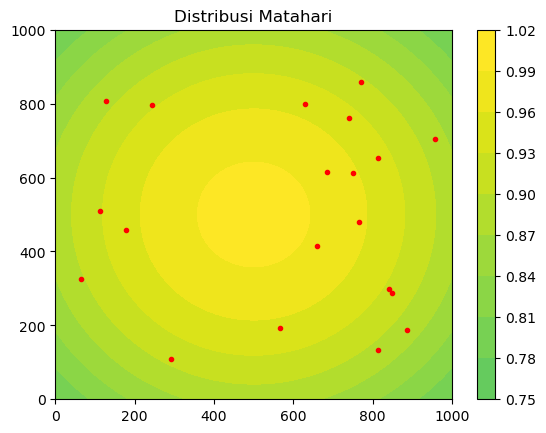

In [15]:
import os
import numpy as np
import matplotlib.pyplot as plt

def gauss_sun_intensity(x, y, sun_center, sun_std_dev):
    """Intensitas Gaussian berdasarkan jarak dari titik tengah."""
    return np.exp(-((x - sun_center[0])**2 + (y - sun_center[1])**2) / (2 * sun_std_dev**2))

def fitness_function(pos, sun_center, sun_std_dev, particles, index, min_distance, repulsion_factor):
    """Fitness function untuk memaksimalkan intensitas cahaya dan meminimalkan repulsi."""
    sun_intensity = gauss_sun_intensity(pos[0], pos[1], sun_center, sun_std_dev)

    repulsion = 0
    for j in range(len(particles)):
        if j != index:
            distance = np.linalg.norm(pos - particles[j])
            if distance < min_distance:
                repulsion += repulsion_factor / distance**2

    fitness = -sun_intensity + repulsion
    return fitness

def calculate_energy_consumption(mass, altitude, horizontal_distance, battery_voltage):
    """Menghitung parameter energi dari setiap drone."""
    drag_coefficient = 0.5
    frontal_area = 0.1  
    air_density = 1.225  
    horizontal_speed = 10.0  
    flight_efficiency = 0.8

    E_vertical_J = mass * 9.81 * altitude
    P_drag = 0.5 * drag_coefficient * frontal_area * air_density * horizontal_speed**2
    P_horizontal = (P_drag + mass * 9.81 * horizontal_speed) / flight_efficiency
    E_horizontal_J = P_horizontal * (horizontal_distance / horizontal_speed)
    E_total_J = E_vertical_J + E_horizontal_J
    E_total_Wh = E_total_J / 3600
    energy_consumed = (E_total_Wh * 1000) / battery_voltage
    return energy_consumed

def pso_drone_solar_chaser_with_battery():
    num_particles = 20
    num_iterations = 100
    dim = 2  
    c1 = 1.0
    c2 = 1.5  
    w = 0.1  
    timestep = 0.1  # seconds
    L = 1000  # meters

    drone_mass = 58.28 # massa baterai + massa panel surya (massa baterai yang dipakai yaitu variasi 7 kg dan massa panel surya variasi 5, 15, 30 ) 
    battery_capacity = 5000  
    solar_charge_rate = 100  
    altitude = 200  
    battery_voltage = 11.1  

    sun_center = np.array([L / 2, L / 2])  
    sun_std_dev = 1000  
    sun_speed = 1000 / 28800  # 1 km per 8 jam dalam meters per second

    min_distance = 3  
    repulsion_factor = 1000  

    particles = np.random.rand(num_particles, dim) * L  
    velocities = np.zeros((num_particles, dim))  
    personal_best_positions = particles.copy()
    global_best_position = particles[0, :].copy()
    global_best_fitness = float('inf')

    battery_levels = battery_capacity * np.ones(num_particles)  

    battery_levels_over_time = np.zeros((num_iterations, num_particles))
    position_diff_over_time = np.zeros((num_iterations, num_particles))

    # Folder untuk menyimpan hasil program
    folder_name = "Percobaan_411"
    if not os.path.exists(folder_name):
        os.makedirs(folder_name)

    for iter in range(num_iterations):
        for i in range(num_particles):
            fitness = fitness_function(particles[i, :], sun_center, sun_std_dev, particles, i, min_distance, repulsion_factor)
            if fitness < fitness_function(personal_best_positions[i, :], sun_center, sun_std_dev, particles, i, min_distance, repulsion_factor):
                personal_best_positions[i, :] = particles[i, :]
            if fitness < global_best_fitness:
                global_best_fitness = fitness
                global_best_position = particles[i, :]

        for i in range(num_particles):
            velocities[i, :] = (w * velocities[i, :] +
                                c1 * np.random.rand() * (personal_best_positions[i, :] - particles[i, :]) +
                                c2 * np.random.rand() * (global_best_position - particles[i, :]) / drone_mass * timestep)
            new_position = particles[i, :] + velocities[i, :]  
            new_position = np.clip(new_position, 0, L)
            horizontal_distance = np.linalg.norm(new_position - particles[i, :])
            energy_consumed = calculate_energy_consumption(drone_mass, altitude, horizontal_distance, battery_voltage)
            battery_levels[i] -= energy_consumed
            if battery_levels[i] > 0:
                particles[i, :] = new_position
            else:
                battery_levels[i] = 0

        for i in range(num_particles):
            solar_energy = (solar_charge_rate * 
                            max(0, gauss_sun_intensity(particles[i, 0], particles[i, 1], sun_center, sun_std_dev)) * 
                            timestep / 3600)
            battery_levels[i] = min(battery_levels[i] + solar_energy, battery_capacity)

        battery_levels_over_time[iter, :] = battery_levels
        position_diff_over_time[iter, :] = np.linalg.norm(particles - sun_center, axis=1)

        sun_center[0] += sun_speed * timestep  

        if sun_center[0] > L:
            sun_center[0] = 0

        X, Y = np.meshgrid(np.arange(0, L+1, 10), np.arange(0, L+1, 10))  
        Z = np.array([[gauss_sun_intensity(x, y, sun_center, sun_std_dev) for x in np.arange(0, L+1, 10)] for y in np.arange(0, L+1, 10)])
        
        plt.contourf(X, Y, Z)  
        plt.colorbar()
        plt.clim(0, 1)
        plt.title('Distribusi Matahari')
        plt.plot(particles[:, 0], particles[:, 1], '.r')
        plt.savefig(f'{folder_name}/frame_{iter+1}.png')  
        plt.clf()

        print(f'Iterasi ke-{iter + 1}: Global Best Fitness = {global_best_fitness}')

    time = np.arange(num_iterations) * timestep 
    
    plt.figure()
    for i in range(num_particles):
        plt.plot(time, battery_levels_over_time[:, i], label=f'Particle {i+1}')
    plt.title('Penggunaan Baterai Masing-Masing Partikel')
    plt.xlabel('Waktu (detik)')
    plt.ylabel('Kapasitas Baterai (mAh)')
    plt.legend(loc='best')
    plt.savefig(f'{folder_name}/Kapasitas Baterai Tiap Waktu.png')  
    plt.show()
    
    plt.figure()
    for i in range(num_particles):
        plt.plot(time, position_diff_over_time[:, i], label=f'Particle {i+1}')
    plt.title('Beda Posisi dari Pusat Matahari tiap Waktu')
    plt.xlabel('Waktu (detik)')
    plt.ylabel('Beda Posisi (meter)')
    plt.legend(loc='best')
    plt.savefig(f'{folder_name}/beda_posisi tiap waktu.png')  
    plt.show()

    print(f'Posisi global terbaik: {global_best_position}')
    print('Kapasitas baterai akhir dan persentasenya: ')
    for i in range(num_particles):
        battery_percentage = (battery_levels[i] / battery_capacity) * 100
        print(f'Drone {i + 1}: Kapasitas baterai = {battery_levels[i]} mAh ({battery_percentage}%)')

if __name__ == "__main__":
    pso_drone_solar_chaser_with_battery()


total massa 12 kg = massa panel surya (5 kg) + massa baterai (7 kg)
kapasitas 5000 mAH

Iterasi ke-1: Global Best Fitness = -0.9859967163240096
Iterasi ke-2: Global Best Fitness = -0.9859972910707656
Iterasi ke-3: Global Best Fitness = -0.9859978658059693
Iterasi ke-4: Global Best Fitness = -0.9859984405296203
Iterasi ke-5: Global Best Fitness = -0.9859990152417187
Iterasi ke-6: Global Best Fitness = -0.9859995899422648
Iterasi ke-7: Global Best Fitness = -0.9860001646312582
Iterasi ke-8: Global Best Fitness = -0.9860007393086989
Iterasi ke-9: Global Best Fitness = -0.9860013139745871
Iterasi ke-10: Global Best Fitness = -0.9860018886289227
Iterasi ke-11: Global Best Fitness = -0.9860024632717056
Iterasi ke-12: Global Best Fitness = -0.9860030379029359
Iterasi ke-13: Global Best Fitness = -0.9860036125226134
Iterasi ke-14: Global Best Fitness = -0.9860041871307382
Iterasi ke-15: Global Best Fitness = -0.9860047617273103
Iterasi ke-16: Global Best Fitness = -0.9860053363123297
Iterasi ke-17: Global Best Fitness = -0.9860059108857961
Iterasi ke-18: Global Best Fitness = -0.

No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.


Iterasi ke-100: Global Best Fitness = -0.986053560208512


<Figure size 640x480 with 0 Axes>

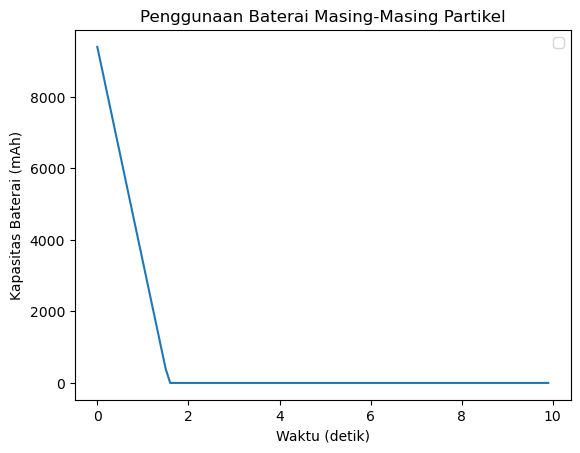

No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.


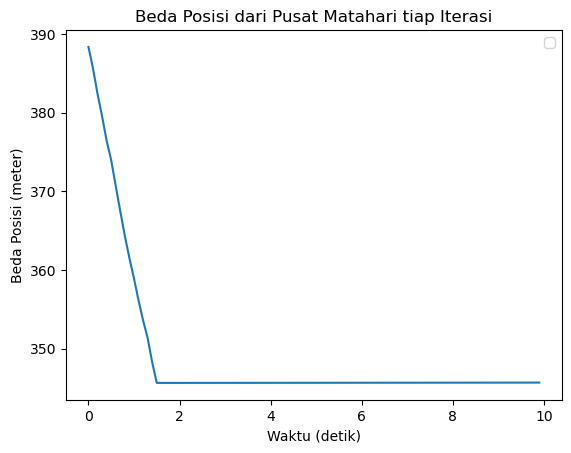

Posisi global terbaik: [667.87959489 495.42277469]
Kapasitas baterai akhir dan persentasenya: 
Drone 1: Kapasitas baterai = 0.0026233627209356807 mAh (2.6233627209356806e-05%)
Drone 2: Kapasitas baterai = 0.0024602848938171436 mAh (2.4602848938171435e-05%)
Drone 3: Kapasitas baterai = 0.0025289026113111167 mAh (2.5289026113111166e-05%)
Drone 4: Kapasitas baterai = 0.002683115808576816 mAh (2.683115808576816e-05%)
Drone 5: Kapasitas baterai = 0.002444419091228123 mAh (2.4444190912281228e-05%)
Drone 6: Kapasitas baterai = 0.0026943827000948744 mAh (2.6943827000948743e-05%)
Drone 7: Kapasitas baterai = 0.0027129417777538153 mAh (2.7129417777538154e-05%)
Drone 8: Kapasitas baterai = 0.0025860631304503636 mAh (2.5860631304503634e-05%)
Drone 9: Kapasitas baterai = 0.002680622545489195 mAh (2.680622545489195e-05%)
Drone 10: Kapasitas baterai = 0.002676978161435115 mAh (2.6769781614351147e-05%)
Drone 11: Kapasitas baterai = 0.0026678052805508947 mAh (2.6678052805508946e-05%)
Drone 12: Kapasita

In [30]:
import os
import numpy as np
import matplotlib.pyplot as plt

def gauss_sun_intensity(x, y, sun_center, sun_std_dev):
    """Intensitas Gaussian berdasarkan jarak dari titik tengah."""
    return np.exp(-((x - sun_center[0])**2 + (y - sun_center[1])**2) / (2 * sun_std_dev**2))

def fitness_function(pos, sun_center, sun_std_dev, particles, index, min_distance, repulsion_factor):
    """Fitness function untuk memaksimalkan intensitas cahaya dan meminimalkan repulsi."""
    sun_intensity = gauss_sun_intensity(pos[0], pos[1], sun_center, sun_std_dev)

    repulsion = 0
    for j in range(len(particles)):
        if j != index:
            distance = np.linalg.norm(pos - particles[j])
            if distance < min_distance:
                repulsion += repulsion_factor / distance**2

    fitness = -sun_intensity + repulsion
    return fitness

def calculate_energy_consumption(mass, altitude, horizontal_distance, battery_voltage):
    """Menghitung parameter energi dari setiap drone."""
    drag_coefficient = 0.5
    frontal_area = 0.1  
    air_density = 1.225  
    horizontal_speed = 10.0  
    flight_efficiency = 0.8

    E_vertical_J = mass * 9.81 * altitude
    P_drag = 0.5 * drag_coefficient * frontal_area * air_density * horizontal_speed**2
    P_horizontal = (P_drag + mass * 9.81 * horizontal_speed) / flight_efficiency
    E_horizontal_J = P_horizontal * (horizontal_distance / horizontal_speed)
    E_total_J = E_vertical_J + E_horizontal_J
    E_total_Wh = E_total_J / 3600
    energy_consumed = (E_total_Wh * 1000) / battery_voltage
    return energy_consumed

def pso_drone_solar_chaser_with_battery():
    num_particles = 20
    num_iterations = 100
    dim = 2  
    c1 = 1.0
    c2 = 1.5  
    w = 0.1  
    timestep = 0.1  # seconds
    L = 1000  # meters

    drone_mass = 12 # massa baterai + massa panel surya (massa baterai yang dipakai yaitu variasi 7 kg dan massa panel surya variasi 5, 15, 30 ) 
    battery_capacity = 10000  
    solar_charge_rate = 100  
    altitude = 200  
    battery_voltage = 11.1  

    sun_center = np.array([L / 2, L / 2])  
    sun_std_dev = 1000  
    sun_speed = 1000 / 28800  # 1 km per 8 jam dalam meters per second

    min_distance = 3  
    repulsion_factor = 1000  

    particles = np.random.rand(num_particles, dim) * L  
    velocities = np.zeros((num_particles, dim))  
    personal_best_positions = particles.copy()
    global_best_position = particles[0, :].copy()
    global_best_fitness = float('inf')

    battery_levels = battery_capacity * np.ones(num_particles)  

    battery_levels_over_time = np.zeros((num_iterations, num_particles))
    position_diff_over_time = np.zeros((num_iterations, num_particles))

    # Folder untuk menyimpan hasil program
    folder_name = "Percobaan_412"
    if not os.path.exists(folder_name):
        os.makedirs(folder_name)

    for iter in range(num_iterations):
        for i in range(num_particles):
            fitness = fitness_function(particles[i, :], sun_center, sun_std_dev, particles, i, min_distance, repulsion_factor)
            if fitness < fitness_function(personal_best_positions[i, :], sun_center, sun_std_dev, particles, i, min_distance, repulsion_factor):
                personal_best_positions[i, :] = particles[i, :]
            if fitness < global_best_fitness:
                global_best_fitness = fitness
                global_best_position = particles[i, :]

        for i in range(num_particles):
            velocities[i, :] = (w * velocities[i, :] +
                                c1 * np.random.rand() * (personal_best_positions[i, :] - particles[i, :]) +
                                c2 * np.random.rand() * (global_best_position - particles[i, :]) / drone_mass * timestep)
            new_position = particles[i, :] + velocities[i, :]  
            new_position = np.clip(new_position, 0, L)
            horizontal_distance = np.linalg.norm(new_position - particles[i, :])
            energy_consumed = calculate_energy_consumption(drone_mass, altitude, horizontal_distance, battery_voltage)
            battery_levels[i] -= energy_consumed
            if battery_levels[i] > 0:
                particles[i, :] = new_position
            else:
                battery_levels[i] = 0

        for i in range(num_particles):
            solar_energy = (solar_charge_rate * 
                            max(0, gauss_sun_intensity(particles[i, 0], particles[i, 1], sun_center, sun_std_dev)) * 
                            timestep / 3600)
            battery_levels[i] = min(battery_levels[i] + solar_energy, battery_capacity)

        battery_levels_over_time[iter, :] = battery_levels
        position_diff_over_time[iter, :] = np.linalg.norm(particles - sun_center, axis=1)

        sun_center[0] += sun_speed * timestep  

        if sun_center[0] > L:
            sun_center[0] = 0

        X, Y = np.meshgrid(np.arange(0, L+1, 10), np.arange(0, L+1, 10))  
        Z = np.array([[gauss_sun_intensity(x, y, sun_center, sun_std_dev) for x in np.arange(0, L+1, 10)] for y in np.arange(0, L+1, 10)])
        
        plt.contourf(X, Y, Z)  
        plt.colorbar()
        plt.clim(0, 1)
        plt.title('Distribusi Matahari')
        plt.plot(particles[:, 0], particles[:, 1], '.r')
        plt.savefig(f'{folder_name}/frame_{iter+1}.png')  
        plt.clf()

        print(f'Iterasi ke-{iter + 1}: Global Best Fitness = {global_best_fitness}')

    time = np.arange(num_iterations) * timestep 
    
    plt.figure()
    for i in range(num_particles):
        plt.plot(time, battery_levels_over_time[:, i], label=f'Particle {i+1}')
    plt.title('Penggunaan Baterai Masing-Masing Partikel')
    plt.xlabel('Waktu (detik)')
    plt.ylabel('Kapasitas Baterai (mAh)')
    plt.legend(loc='best')
    plt.savefig(f'{folder_name}/Kapasitas Baterai Tiap Waktu.png')  
    plt.show()
    
    plt.figure()
    for i in range(num_particles):
        plt.plot(time, position_diff_over_time[:, i], label=f'Particle {i+1}')
    plt.title('Beda Posisi dari Pusat Matahari tiap Waktu')
    plt.xlabel('Waktu (detik)')
    plt.ylabel('Beda Posisi (meter)')
    plt.legend(loc='best')
    plt.savefig(f'{folder_name}/beda_posisi tiap waktu.png')  
    plt.show()

    print(f'Posisi global terbaik: {global_best_position}')
    print('Kapasitas baterai akhir dan persentasenya: ')
    for i in range(num_particles):
        battery_percentage = (battery_levels[i] / battery_capacity) * 100
        print(f'Drone {i + 1}: Kapasitas baterai = {battery_levels[i]} mAh ({battery_percentage}%)')

if __name__ == "__main__":
    pso_drone_solar_chaser_with_battery()


total massa 15,5 kg = massa panel surya (5 kg) + massa baterai (10,5 kg)
kapasitas 5000 mAH

Iterasi ke-1: Global Best Fitness = -0.9929182606332122
Iterasi ke-2: Global Best Fitness = -0.9929182606332122
Iterasi ke-3: Global Best Fitness = -0.9929182606332122
Iterasi ke-4: Global Best Fitness = -0.9929182606332122
Iterasi ke-5: Global Best Fitness = -0.9929182606332122
Iterasi ke-6: Global Best Fitness = -0.9929182606332122
Iterasi ke-7: Global Best Fitness = -0.9929182606332122
Iterasi ke-8: Global Best Fitness = -0.9929182606332122
Iterasi ke-9: Global Best Fitness = -0.9929182606332122
Iterasi ke-10: Global Best Fitness = -0.9929182606332122
Iterasi ke-11: Global Best Fitness = -0.9929182606332122
Iterasi ke-12: Global Best Fitness = -0.9929182606332122
Iterasi ke-13: Global Best Fitness = -0.9929182606332122
Iterasi ke-14: Global Best Fitness = -0.9929182606332122
Iterasi ke-15: Global Best Fitness = -0.9929182606332122
Iterasi ke-16: Global Best Fitness = -0.9929182606332122
Iterasi ke-17: Global Best Fitness = -0.9929182606332122
Iterasi ke-18: Global Best Fitness = -0.

No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.


Iterasi ke-100: Global Best Fitness = -0.9929182606332122


<Figure size 640x480 with 0 Axes>

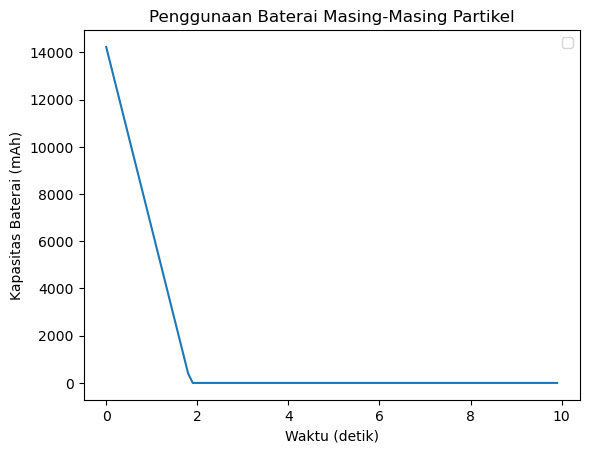

No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.


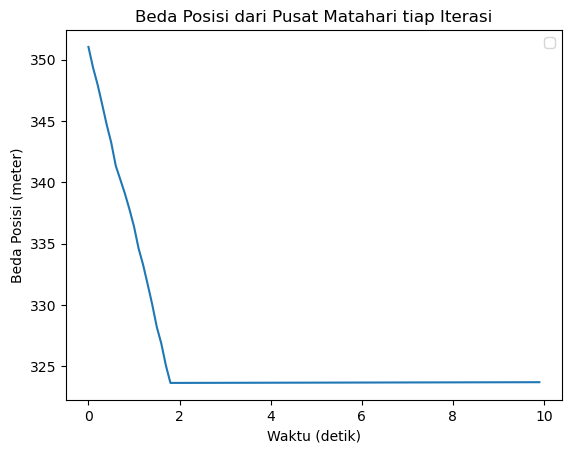

Posisi global terbaik: [382.68458564 521.2358507 ]
Kapasitas baterai akhir dan persentasenya: 
Drone 1: Kapasitas baterai = 0.0027475631917615105 mAh (1.8317087945076735e-05%)
Drone 2: Kapasitas baterai = 0.0027541633081537833 mAh (1.8361088721025222e-05%)
Drone 3: Kapasitas baterai = 0.002597382553132173 mAh (1.731588368754782e-05%)
Drone 4: Kapasitas baterai = 0.002390979289322708 mAh (1.593986192881805e-05%)
Drone 5: Kapasitas baterai = 0.002412307085290212 mAh (1.608204723526808e-05%)
Drone 6: Kapasitas baterai = 0.002464597042657117 mAh (1.643064695104745e-05%)
Drone 7: Kapasitas baterai = 0.002739663139980707 mAh (1.826442093320471e-05%)
Drone 8: Kapasitas baterai = 0.0026786830127052594 mAh (1.7857886751368398e-05%)
Drone 9: Kapasitas baterai = 0.002506051930439195 mAh (1.6707012869594633e-05%)
Drone 10: Kapasitas baterai = 0.0025038755807204457 mAh (1.669250387146964e-05%)
Drone 11: Kapasitas baterai = 0.002753644476902808 mAh (1.835762984601872e-05%)
Drone 12: Kapasitas batera

In [31]:
import os
import numpy as np
import matplotlib.pyplot as plt

def gauss_sun_intensity(x, y, sun_center, sun_std_dev):
    """Intensitas Gaussian berdasarkan jarak dari titik tengah."""
    return np.exp(-((x - sun_center[0])**2 + (y - sun_center[1])**2) / (2 * sun_std_dev**2))

def fitness_function(pos, sun_center, sun_std_dev, particles, index, min_distance, repulsion_factor):
    """Fitness function untuk memaksimalkan intensitas cahaya dan meminimalkan repulsi."""
    sun_intensity = gauss_sun_intensity(pos[0], pos[1], sun_center, sun_std_dev)

    repulsion = 0
    for j in range(len(particles)):
        if j != index:
            distance = np.linalg.norm(pos - particles[j])
            if distance < min_distance:
                repulsion += repulsion_factor / distance**2

    fitness = -sun_intensity + repulsion
    return fitness

def calculate_energy_consumption(mass, altitude, horizontal_distance, battery_voltage):
    """Menghitung parameter energi dari setiap drone."""
    drag_coefficient = 0.5
    frontal_area = 0.1  
    air_density = 1.225  
    horizontal_speed = 10.0  
    flight_efficiency = 0.8

    E_vertical_J = mass * 9.81 * altitude
    P_drag = 0.5 * drag_coefficient * frontal_area * air_density * horizontal_speed**2
    P_horizontal = (P_drag + mass * 9.81 * horizontal_speed) / flight_efficiency
    E_horizontal_J = P_horizontal * (horizontal_distance / horizontal_speed)
    E_total_J = E_vertical_J + E_horizontal_J
    E_total_Wh = E_total_J / 3600
    energy_consumed = (E_total_Wh * 1000) / battery_voltage
    return energy_consumed

def pso_drone_solar_chaser_with_battery():
    num_particles = 20
    num_iterations = 100
    dim = 2  
    c1 = 1.0
    c2 = 1.5  
    w = 0.1  
    timestep = 0.1  # seconds
    L = 1000  # meters

    drone_mass = 15.5 # massa baterai + massa panel surya (massa baterai yang dipakai yaitu variasi 7 kg dan massa panel surya variasi 5, 15, 30 ) 
    battery_capacity = 15000  
    solar_charge_rate = 100  
    altitude = 200  
    battery_voltage = 11.1  

    sun_center = np.array([L / 2, L / 2])  
    sun_std_dev = 1000  
    sun_speed = 1000 / 28800  # 1 km per 8 jam dalam meters per second

    min_distance = 3  
    repulsion_factor = 1000  

    particles = np.random.rand(num_particles, dim) * L  
    velocities = np.zeros((num_particles, dim))  
    personal_best_positions = particles.copy()
    global_best_position = particles[0, :].copy()
    global_best_fitness = float('inf')

    battery_levels = battery_capacity * np.ones(num_particles)  

    battery_levels_over_time = np.zeros((num_iterations, num_particles))
    position_diff_over_time = np.zeros((num_iterations, num_particles))

    # Folder untuk menyimpan hasil program
    folder_name = "Percobaan_413"
    if not os.path.exists(folder_name):
        os.makedirs(folder_name)

    for iter in range(num_iterations):
        for i in range(num_particles):
            fitness = fitness_function(particles[i, :], sun_center, sun_std_dev, particles, i, min_distance, repulsion_factor)
            if fitness < fitness_function(personal_best_positions[i, :], sun_center, sun_std_dev, particles, i, min_distance, repulsion_factor):
                personal_best_positions[i, :] = particles[i, :]
            if fitness < global_best_fitness:
                global_best_fitness = fitness
                global_best_position = particles[i, :]

        for i in range(num_particles):
            velocities[i, :] = (w * velocities[i, :] +
                                c1 * np.random.rand() * (personal_best_positions[i, :] - particles[i, :]) +
                                c2 * np.random.rand() * (global_best_position - particles[i, :]) / drone_mass * timestep)
            new_position = particles[i, :] + velocities[i, :]  
            new_position = np.clip(new_position, 0, L)
            horizontal_distance = np.linalg.norm(new_position - particles[i, :])
            energy_consumed = calculate_energy_consumption(drone_mass, altitude, horizontal_distance, battery_voltage)
            battery_levels[i] -= energy_consumed
            if battery_levels[i] > 0:
                particles[i, :] = new_position
            else:
                battery_levels[i] = 0

        for i in range(num_particles):
            solar_energy = (solar_charge_rate * 
                            max(0, gauss_sun_intensity(particles[i, 0], particles[i, 1], sun_center, sun_std_dev)) * 
                            timestep / 3600)
            battery_levels[i] = min(battery_levels[i] + solar_energy, battery_capacity)

        battery_levels_over_time[iter, :] = battery_levels
        position_diff_over_time[iter, :] = np.linalg.norm(particles - sun_center, axis=1)

        sun_center[0] += sun_speed * timestep  

        if sun_center[0] > L:
            sun_center[0] = 0

        X, Y = np.meshgrid(np.arange(0, L+1, 10), np.arange(0, L+1, 10))  
        Z = np.array([[gauss_sun_intensity(x, y, sun_center, sun_std_dev) for x in np.arange(0, L+1, 10)] for y in np.arange(0, L+1, 10)])
        
        plt.contourf(X, Y, Z)  
        plt.colorbar()
        plt.clim(0, 1)
        plt.title('Distribusi Matahari')
        plt.plot(particles[:, 0], particles[:, 1], '.r')
        plt.savefig(f'{folder_name}/frame_{iter+1}.png')  
        plt.clf()

        print(f'Iterasi ke-{iter + 1}: Global Best Fitness = {global_best_fitness}')

    time = np.arange(num_iterations) * timestep 
    
    plt.figure()
    for i in range(num_particles):
        plt.plot(time, battery_levels_over_time[:, i], label=f'Particle {i+1}')
    plt.title('Penggunaan Baterai Masing-Masing Partikel')
    plt.xlabel('Waktu (detik)')
    plt.ylabel('Kapasitas Baterai (mAh)')
    plt.legend(loc='best')
    plt.savefig(f'{folder_name}/Kapasitas Baterai Tiap Waktu.png')  
    plt.show()
    
    plt.figure()
    for i in range(num_particles):
        plt.plot(time, position_diff_over_time[:, i], label=f'Particle {i+1}')
    plt.title('Beda Posisi dari Pusat Matahari tiap Waktu')
    plt.xlabel('Waktu (detik)')
    plt.ylabel('Beda Posisi (meter)')
    plt.legend(loc='best')
    plt.savefig(f'{folder_name}/beda_posisi tiap waktu.png')  
    plt.show()

    print(f'Posisi global terbaik: {global_best_position}')
    print('Kapasitas baterai akhir dan persentasenya: ')
    for i in range(num_particles):
        battery_percentage = (battery_levels[i] / battery_capacity) * 100
        print(f'Drone {i + 1}: Kapasitas baterai = {battery_levels[i]} mAh ({battery_percentage}%)')

if __name__ == "__main__":
    pso_drone_solar_chaser_with_battery()


total massa 19,5 kg = massa panel surya (5 kg) + massa baterai (14,5 kg)
kapasitas 5000 mAH

Iterasi ke-1: Global Best Fitness = -0.9717211330380642
Iterasi ke-2: Global Best Fitness = -0.9717211330380642
Iterasi ke-3: Global Best Fitness = -0.9717211330380642
Iterasi ke-4: Global Best Fitness = -0.9717211330380642
Iterasi ke-5: Global Best Fitness = -0.9717211330380642
Iterasi ke-6: Global Best Fitness = -0.9717211330380642
Iterasi ke-7: Global Best Fitness = -0.9717211330380642
Iterasi ke-8: Global Best Fitness = -0.9717211330380642
Iterasi ke-9: Global Best Fitness = -0.9717211330380642
Iterasi ke-10: Global Best Fitness = -0.9717211330380642
Iterasi ke-11: Global Best Fitness = -0.9717211330380642
Iterasi ke-12: Global Best Fitness = -0.9717211330380642
Iterasi ke-13: Global Best Fitness = -0.9717211330380642
Iterasi ke-14: Global Best Fitness = -0.9717211330380642
Iterasi ke-15: Global Best Fitness = -0.9717211330380642
Iterasi ke-16: Global Best Fitness = -0.9717211330380642
Iterasi ke-17: Global Best Fitness = -0.9717211330380642
Iterasi ke-18: Global Best Fitness = -0.

No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.


Iterasi ke-99: Global Best Fitness = -0.9717211330380642
Iterasi ke-100: Global Best Fitness = -0.9717211330380642


<Figure size 640x480 with 0 Axes>

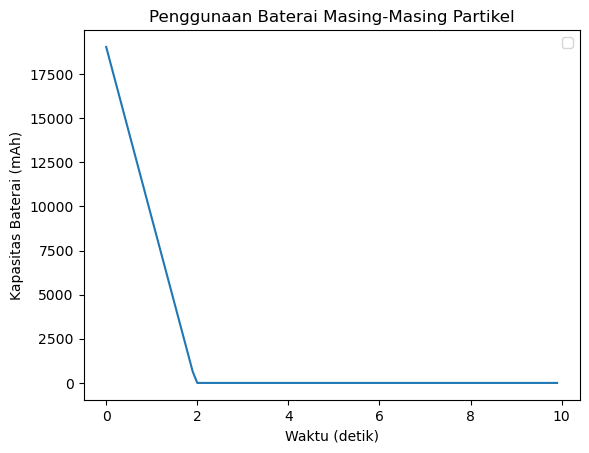

No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.


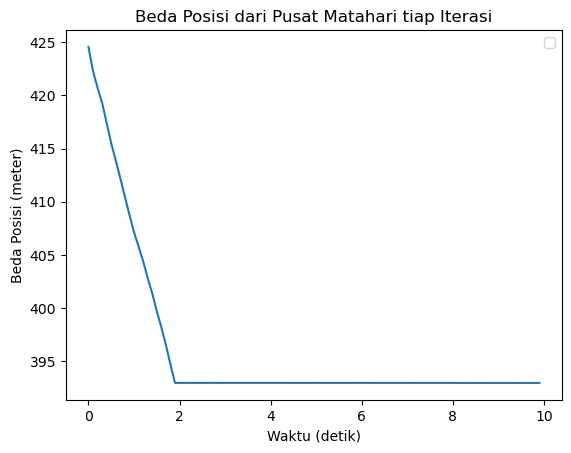

Posisi global terbaik: [372.10773233 702.52505913]
Kapasitas baterai akhir dan persentasenya: 
Drone 1: Kapasitas baterai = 0.0025541775336622385 mAh (1.2770887668311192e-05%)
Drone 2: Kapasitas baterai = 0.0024485077973029914 mAh (1.2242538986514958e-05%)
Drone 3: Kapasitas baterai = 0.002699106546734017 mAh (1.3495532733670087e-05%)
Drone 4: Kapasitas baterai = 0.0025677360538667415 mAh (1.2838680269333707e-05%)
Drone 5: Kapasitas baterai = 0.0026236289009764907 mAh (1.3118144504882453e-05%)
Drone 6: Kapasitas baterai = 0.0026677382916521337 mAh (1.333869145826067e-05%)
Drone 7: Kapasitas baterai = 0.002613187806753383 mAh (1.3065939033766914e-05%)
Drone 8: Kapasitas baterai = 0.0026405255097835634 mAh (1.3202627548917816e-05%)
Drone 9: Kapasitas baterai = 0.0025849613029641652 mAh (1.2924806514820827e-05%)
Drone 10: Kapasitas baterai = 0.002418285310447064 mAh (1.209142655223532e-05%)
Drone 11: Kapasitas baterai = 0.0025418816527349253 mAh (1.2709408263674627e-05%)
Drone 12: Kapasit

In [32]:
import os
import numpy as np
import matplotlib.pyplot as plt

def gauss_sun_intensity(x, y, sun_center, sun_std_dev):
    """Intensitas Gaussian berdasarkan jarak dari titik tengah."""
    return np.exp(-((x - sun_center[0])**2 + (y - sun_center[1])**2) / (2 * sun_std_dev**2))

def fitness_function(pos, sun_center, sun_std_dev, particles, index, min_distance, repulsion_factor):
    """Fitness function untuk memaksimalkan intensitas cahaya dan meminimalkan repulsi."""
    sun_intensity = gauss_sun_intensity(pos[0], pos[1], sun_center, sun_std_dev)

    repulsion = 0
    for j in range(len(particles)):
        if j != index:
            distance = np.linalg.norm(pos - particles[j])
            if distance < min_distance:
                repulsion += repulsion_factor / distance**2

    fitness = -sun_intensity + repulsion
    return fitness

def calculate_energy_consumption(mass, altitude, horizontal_distance, battery_voltage):
    """Menghitung parameter energi dari setiap drone."""
    drag_coefficient = 0.5
    frontal_area = 0.1  
    air_density = 1.225  
    horizontal_speed = 10.0  
    flight_efficiency = 0.8

    E_vertical_J = mass * 9.81 * altitude
    P_drag = 0.5 * drag_coefficient * frontal_area * air_density * horizontal_speed**2
    P_horizontal = (P_drag + mass * 9.81 * horizontal_speed) / flight_efficiency
    E_horizontal_J = P_horizontal * (horizontal_distance / horizontal_speed)
    E_total_J = E_vertical_J + E_horizontal_J
    E_total_Wh = E_total_J / 3600
    energy_consumed = (E_total_Wh * 1000) / battery_voltage
    return energy_consumed

def pso_drone_solar_chaser_with_battery():
    num_particles = 20
    num_iterations = 100
    dim = 2  
    c1 = 1.0
    c2 = 1.5  
    w = 0.1  
    timestep = 0.1  # seconds
    L = 1000  # meters

    drone_mass = 19.5 # massa baterai + massa panel surya (massa baterai yang dipakai yaitu variasi 7 kg dan massa panel surya variasi 5, 15, 30 ) 
    battery_capacity = 20000  
    solar_charge_rate = 100  
    altitude = 200  
    battery_voltage = 11.1  

    sun_center = np.array([L / 2, L / 2])  
    sun_std_dev = 1000  
    sun_speed = 1000 / 28800  # 1 km per 8 jam dalam meters per second

    min_distance = 3  
    repulsion_factor = 1000  

    particles = np.random.rand(num_particles, dim) * L  
    velocities = np.zeros((num_particles, dim))  
    personal_best_positions = particles.copy()
    global_best_position = particles[0, :].copy()
    global_best_fitness = float('inf')

    battery_levels = battery_capacity * np.ones(num_particles)  

    battery_levels_over_time = np.zeros((num_iterations, num_particles))
    position_diff_over_time = np.zeros((num_iterations, num_particles))

    # Folder untuk menyimpan hasil program
    folder_name = "Percobaan_414"
    if not os.path.exists(folder_name):
        os.makedirs(folder_name)

    for iter in range(num_iterations):
        for i in range(num_particles):
            fitness = fitness_function(particles[i, :], sun_center, sun_std_dev, particles, i, min_distance, repulsion_factor)
            if fitness < fitness_function(personal_best_positions[i, :], sun_center, sun_std_dev, particles, i, min_distance, repulsion_factor):
                personal_best_positions[i, :] = particles[i, :]
            if fitness < global_best_fitness:
                global_best_fitness = fitness
                global_best_position = particles[i, :]

        for i in range(num_particles):
            velocities[i, :] = (w * velocities[i, :] +
                                c1 * np.random.rand() * (personal_best_positions[i, :] - particles[i, :]) +
                                c2 * np.random.rand() * (global_best_position - particles[i, :]) / drone_mass * timestep)
            new_position = particles[i, :] + velocities[i, :]  
            new_position = np.clip(new_position, 0, L)
            horizontal_distance = np.linalg.norm(new_position - particles[i, :])
            energy_consumed = calculate_energy_consumption(drone_mass, altitude, horizontal_distance, battery_voltage)
            battery_levels[i] -= energy_consumed
            if battery_levels[i] > 0:
                particles[i, :] = new_position
            else:
                battery_levels[i] = 0

        for i in range(num_particles):
            solar_energy = (solar_charge_rate * 
                            max(0, gauss_sun_intensity(particles[i, 0], particles[i, 1], sun_center, sun_std_dev)) * 
                            timestep / 3600)
            battery_levels[i] = min(battery_levels[i] + solar_energy, battery_capacity)

        battery_levels_over_time[iter, :] = battery_levels
        position_diff_over_time[iter, :] = np.linalg.norm(particles - sun_center, axis=1)

        sun_center[0] += sun_speed * timestep  

        if sun_center[0] > L:
            sun_center[0] = 0

        X, Y = np.meshgrid(np.arange(0, L+1, 10), np.arange(0, L+1, 10))  
        Z = np.array([[gauss_sun_intensity(x, y, sun_center, sun_std_dev) for x in np.arange(0, L+1, 10)] for y in np.arange(0, L+1, 10)])
        
        plt.contourf(X, Y, Z)  
        plt.colorbar()
        plt.clim(0, 1)
        plt.title('Distribusi Matahari')
        plt.plot(particles[:, 0], particles[:, 1], '.r')
        plt.savefig(f'{folder_name}/frame_{iter+1}.png')  
        plt.clf()

        print(f'Iterasi ke-{iter + 1}: Global Best Fitness = {global_best_fitness}')

    time = np.arange(num_iterations) * timestep 
    
    plt.figure()
    for i in range(num_particles):
        plt.plot(time, battery_levels_over_time[:, i], label=f'Particle {i+1}')
    plt.title('Penggunaan Baterai Masing-Masing Partikel')
    plt.xlabel('Waktu (detik)')
    plt.ylabel('Kapasitas Baterai (mAh)')
    plt.legend(loc='best')
    plt.savefig(f'{folder_name}/Kapasitas Baterai Tiap Waktu.png')  
    plt.show()
    
    plt.figure()
    for i in range(num_particles):
        plt.plot(time, position_diff_over_time[:, i], label=f'Particle {i+1}')
    plt.title('Beda Posisi dari Pusat Matahari tiap Waktu')
    plt.xlabel('Waktu (detik)')
    plt.ylabel('Beda Posisi (meter)')
    plt.legend(loc='best')
    plt.savefig(f'{folder_name}/beda_posisi tiap waktu.png')  
    plt.show()

    print(f'Posisi global terbaik: {global_best_position}')
    print('Kapasitas baterai akhir dan persentasenya: ')
    for i in range(num_particles):
        battery_percentage = (battery_levels[i] / battery_capacity) * 100
        print(f'Drone {i + 1}: Kapasitas baterai = {battery_levels[i]} mAh ({battery_percentage}%)')

if __name__ == "__main__":
    pso_drone_solar_chaser_with_battery()


total massa 18,5 kg = massa panel surya (15 kg) + massa baterai (3,5 kg)
kapasitas 5000 mAH

Iterasi ke-1: Global Best Fitness = -0.9905541395494846
Iterasi ke-2: Global Best Fitness = -0.9905544883564548
Iterasi ke-3: Global Best Fitness = -0.9905548371516054
Iterasi ke-4: Global Best Fitness = -0.9905551859349364
Iterasi ke-5: Global Best Fitness = -0.9905555347064477
Iterasi ke-6: Global Best Fitness = -0.9905558834661393
Iterasi ke-7: Global Best Fitness = -0.9905562322140113
Iterasi ke-8: Global Best Fitness = -0.9905565809500636
Iterasi ke-9: Global Best Fitness = -0.9905569296742962
Iterasi ke-10: Global Best Fitness = -0.990557278386709
Iterasi ke-11: Global Best Fitness = -0.9905576270873022
Iterasi ke-12: Global Best Fitness = -0.9905579757760756
Iterasi ke-13: Global Best Fitness = -0.9905583244530293
Iterasi ke-14: Global Best Fitness = -0.9905586731181631
Iterasi ke-15: Global Best Fitness = -0.9905590217714773
Iterasi ke-16: Global Best Fitness = -0.9905593704129715
Iterasi ke-17: Global Best Fitness = -0.9905597190426461
Iterasi ke-18: Global Best Fitness = -0.9

No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.


Iterasi ke-100: Global Best Fitness = -0.9905886141005581


<Figure size 640x480 with 0 Axes>

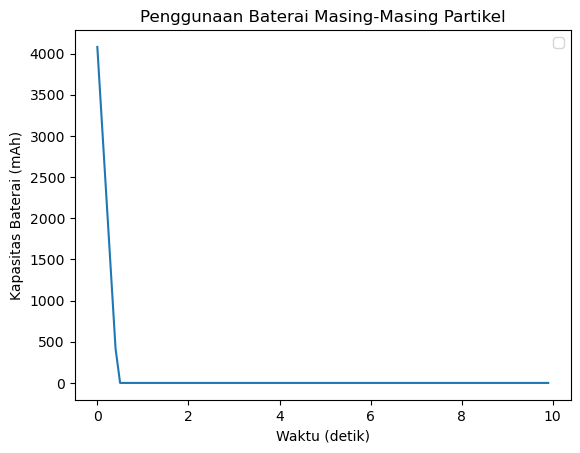

No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.


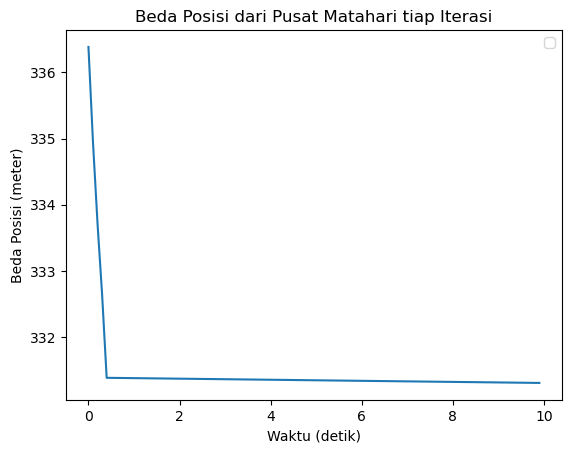

Posisi global terbaik: [601.41607151 406.74609125]
Kapasitas baterai akhir dan persentasenya: 
Drone 1: Kapasitas baterai = 0.002750859011391397 mAh (5.5017180227827933e-05%)
Drone 2: Kapasitas baterai = 0.002657591461461162 mAh (5.315182922922325e-05%)
Drone 3: Kapasitas baterai = 0.0026837916371831266 mAh (5.367583274366253e-05%)
Drone 4: Kapasitas baterai = 0.0025195609630173405 mAh (5.039121926034681e-05%)
Drone 5: Kapasitas baterai = 0.0027236103268964505 mAh (5.447220653792901e-05%)
Drone 6: Kapasitas baterai = 0.0025193698218801764 mAh (5.0387396437603526e-05%)
Drone 7: Kapasitas baterai = 0.0026715291427403423 mAh (5.343058285480684e-05%)
Drone 8: Kapasitas baterai = 0.0025591377706022196 mAh (5.1182755412044386e-05%)
Drone 9: Kapasitas baterai = 0.0023531867177872135 mAh (4.706373435574427e-05%)
Drone 10: Kapasitas baterai = 0.0026604002923923983 mAh (5.3208005847847966e-05%)
Drone 11: Kapasitas baterai = 0.002529938788653905 mAh (5.05987757730781e-05%)
Drone 12: Kapasitas bat

In [33]:
import os
import numpy as np
import matplotlib.pyplot as plt

def gauss_sun_intensity(x, y, sun_center, sun_std_dev):
    """Intensitas Gaussian berdasarkan jarak dari titik tengah."""
    return np.exp(-((x - sun_center[0])**2 + (y - sun_center[1])**2) / (2 * sun_std_dev**2))

def fitness_function(pos, sun_center, sun_std_dev, particles, index, min_distance, repulsion_factor):
    """Fitness function untuk memaksimalkan intensitas cahaya dan meminimalkan repulsi."""
    sun_intensity = gauss_sun_intensity(pos[0], pos[1], sun_center, sun_std_dev)

    repulsion = 0
    for j in range(len(particles)):
        if j != index:
            distance = np.linalg.norm(pos - particles[j])
            if distance < min_distance:
                repulsion += repulsion_factor / distance**2

    fitness = -sun_intensity + repulsion
    return fitness

def calculate_energy_consumption(mass, altitude, horizontal_distance, battery_voltage):
    """Menghitung parameter energi dari setiap drone."""
    drag_coefficient = 0.5
    frontal_area = 0.1  
    air_density = 1.225  
    horizontal_speed = 10.0  
    flight_efficiency = 0.8

    E_vertical_J = mass * 9.81 * altitude
    P_drag = 0.5 * drag_coefficient * frontal_area * air_density * horizontal_speed**2
    P_horizontal = (P_drag + mass * 9.81 * horizontal_speed) / flight_efficiency
    E_horizontal_J = P_horizontal * (horizontal_distance / horizontal_speed)
    E_total_J = E_vertical_J + E_horizontal_J
    E_total_Wh = E_total_J / 3600
    energy_consumed = (E_total_Wh * 1000) / battery_voltage
    return energy_consumed

def pso_drone_solar_chaser_with_battery():
    num_particles = 20
    num_iterations = 100
    dim = 2  
    c1 = 1.0
    c2 = 1.5  
    w = 0.1  
    timestep = 0.1  # seconds
    L = 1000  # meters

    drone_mass = 18.5 # massa baterai + massa panel surya (massa baterai yang dipakai yaitu variasi 7 kg dan massa panel surya variasi 5, 15, 30 ) 
    battery_capacity = 5000  
    solar_charge_rate = 100  
    altitude = 200  
    battery_voltage = 11.1  

    sun_center = np.array([L / 2, L / 2])  
    sun_std_dev = 1000  
    sun_speed = 1000 / 28800  # 1 km per 8 jam dalam meters per second

    min_distance = 3  
    repulsion_factor = 1000  

    particles = np.random.rand(num_particles, dim) * L  
    velocities = np.zeros((num_particles, dim))  
    personal_best_positions = particles.copy()
    global_best_position = particles[0, :].copy()
    global_best_fitness = float('inf')

    battery_levels = battery_capacity * np.ones(num_particles)  

    battery_levels_over_time = np.zeros((num_iterations, num_particles))
    position_diff_over_time = np.zeros((num_iterations, num_particles))

    # Folder untuk menyimpan hasil program
    folder_name = "Percobaan_421"
    if not os.path.exists(folder_name):
        os.makedirs(folder_name)

    for iter in range(num_iterations):
        for i in range(num_particles):
            fitness = fitness_function(particles[i, :], sun_center, sun_std_dev, particles, i, min_distance, repulsion_factor)
            if fitness < fitness_function(personal_best_positions[i, :], sun_center, sun_std_dev, particles, i, min_distance, repulsion_factor):
                personal_best_positions[i, :] = particles[i, :]
            if fitness < global_best_fitness:
                global_best_fitness = fitness
                global_best_position = particles[i, :]

        for i in range(num_particles):
            velocities[i, :] = (w * velocities[i, :] +
                                c1 * np.random.rand() * (personal_best_positions[i, :] - particles[i, :]) +
                                c2 * np.random.rand() * (global_best_position - particles[i, :]) / drone_mass * timestep)
            new_position = particles[i, :] + velocities[i, :]  
            new_position = np.clip(new_position, 0, L)
            horizontal_distance = np.linalg.norm(new_position - particles[i, :])
            energy_consumed = calculate_energy_consumption(drone_mass, altitude, horizontal_distance, battery_voltage)
            battery_levels[i] -= energy_consumed
            if battery_levels[i] > 0:
                particles[i, :] = new_position
            else:
                battery_levels[i] = 0

        for i in range(num_particles):
            solar_energy = (solar_charge_rate * 
                            max(0, gauss_sun_intensity(particles[i, 0], particles[i, 1], sun_center, sun_std_dev)) * 
                            timestep / 3600)
            battery_levels[i] = min(battery_levels[i] + solar_energy, battery_capacity)

        battery_levels_over_time[iter, :] = battery_levels
        position_diff_over_time[iter, :] = np.linalg.norm(particles - sun_center, axis=1)

        sun_center[0] += sun_speed * timestep  

        if sun_center[0] > L:
            sun_center[0] = 0

        X, Y = np.meshgrid(np.arange(0, L+1, 10), np.arange(0, L+1, 10))  
        Z = np.array([[gauss_sun_intensity(x, y, sun_center, sun_std_dev) for x in np.arange(0, L+1, 10)] for y in np.arange(0, L+1, 10)])
        
        plt.contourf(X, Y, Z)  
        plt.colorbar()
        plt.clim(0, 1)
        plt.title('Distribusi Matahari')
        plt.plot(particles[:, 0], particles[:, 1], '.r')
        plt.savefig(f'{folder_name}/frame_{iter+1}.png')  
        plt.clf()

        print(f'Iterasi ke-{iter + 1}: Global Best Fitness = {global_best_fitness}')

    time = np.arange(num_iterations) * timestep 
    
    plt.figure()
    for i in range(num_particles):
        plt.plot(time, battery_levels_over_time[:, i], label=f'Particle {i+1}')
    plt.title('Penggunaan Baterai Masing-Masing Partikel')
    plt.xlabel('Waktu (detik)')
    plt.ylabel('Kapasitas Baterai (mAh)')
    plt.legend(loc='best')
    plt.savefig(f'{folder_name}/Kapasitas Baterai Tiap Waktu.png')  
    plt.show()
    
    plt.figure()
    for i in range(num_particles):
        plt.plot(time, position_diff_over_time[:, i], label=f'Particle {i+1}')
    plt.title('Beda Posisi dari Pusat Matahari tiap Waktu')
    plt.xlabel('Waktu (detik)')
    plt.ylabel('Beda Posisi (meter)')
    plt.legend(loc='best')
    plt.savefig(f'{folder_name}/beda_posisi tiap waktu.png')  
    plt.show()

    print(f'Posisi global terbaik: {global_best_position}')
    print('Kapasitas baterai akhir dan persentasenya: ')
    for i in range(num_particles):
        battery_percentage = (battery_levels[i] / battery_capacity) * 100
        print(f'Drone {i + 1}: Kapasitas baterai = {battery_levels[i]} mAh ({battery_percentage}%)')

if __name__ == "__main__":
    pso_drone_solar_chaser_with_battery()


total massa 22 kg = massa panel surya (15 kg) + massa baterai (7 kg)
kapasitas 10000 mAH

Iterasi ke-1: Global Best Fitness = -0.9958383938635902
Iterasi ke-2: Global Best Fitness = -0.9958383938635902
Iterasi ke-3: Global Best Fitness = -0.9958383938635902
Iterasi ke-4: Global Best Fitness = -0.9958383938635902
Iterasi ke-5: Global Best Fitness = -0.9958383938635902
Iterasi ke-6: Global Best Fitness = -0.9958383938635902
Iterasi ke-7: Global Best Fitness = -0.9958383938635902
Iterasi ke-8: Global Best Fitness = -0.9958383938635902
Iterasi ke-9: Global Best Fitness = -0.9958383938635902
Iterasi ke-10: Global Best Fitness = -0.9958383938635902
Iterasi ke-11: Global Best Fitness = -0.9958383938635902
Iterasi ke-12: Global Best Fitness = -0.9958383938635902
Iterasi ke-13: Global Best Fitness = -0.9958383938635902
Iterasi ke-14: Global Best Fitness = -0.9958383938635902
Iterasi ke-15: Global Best Fitness = -0.9958383938635902
Iterasi ke-16: Global Best Fitness = -0.9958383938635902
Iterasi ke-17: Global Best Fitness = -0.9958383938635902
Iterasi ke-18: Global Best Fitness = -0.

No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.


Iterasi ke-100: Global Best Fitness = -0.9958383938635902


<Figure size 640x480 with 0 Axes>

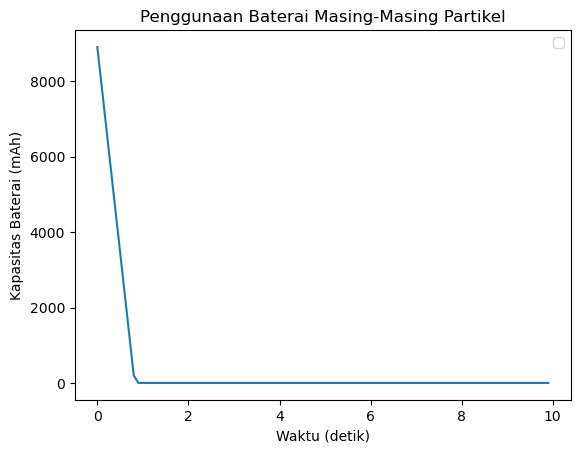

No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.


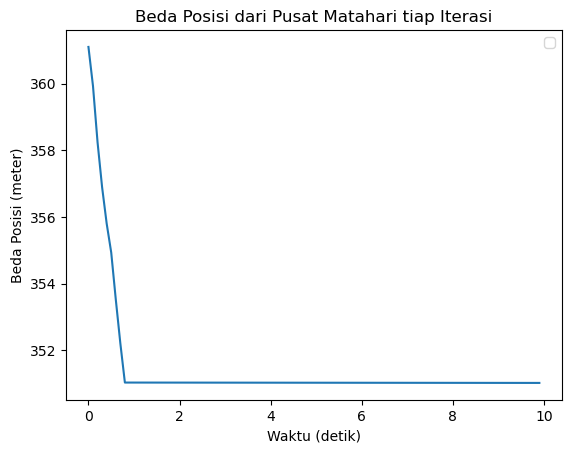

Posisi global terbaik: [460.49864349 417.6578949 ]
Kapasitas baterai akhir dan persentasenya: 
Drone 1: Kapasitas baterai = 0.0024957921661434095 mAh (2.4957921661434094e-05%)
Drone 2: Kapasitas baterai = 0.002661697021953414 mAh (2.661697021953414e-05%)
Drone 3: Kapasitas baterai = 0.0023954856201882893 mAh (2.3954856201882893e-05%)
Drone 4: Kapasitas baterai = 0.002343910319274512 mAh (2.343910319274512e-05%)
Drone 5: Kapasitas baterai = 0.0027545553285151453 mAh (2.7545553285151454e-05%)
Drone 6: Kapasitas baterai = 0.0025136258321207606 mAh (2.513625832120761e-05%)
Drone 7: Kapasitas baterai = 0.002766180036215248 mAh (2.7661800362152477e-05%)
Drone 8: Kapasitas baterai = 0.0024660745161503754 mAh (2.4660745161503754e-05%)
Drone 9: Kapasitas baterai = 0.0027264239345209467 mAh (2.7264239345209466e-05%)
Drone 10: Kapasitas baterai = 0.0027265906811450033 mAh (2.7265906811450034e-05%)
Drone 11: Kapasitas baterai = 0.0027098378601049643 mAh (2.709837860104964e-05%)
Drone 12: Kapasitas

In [34]:
import os
import numpy as np
import matplotlib.pyplot as plt

def gauss_sun_intensity(x, y, sun_center, sun_std_dev):
    """Intensitas Gaussian berdasarkan jarak dari titik tengah."""
    return np.exp(-((x - sun_center[0])**2 + (y - sun_center[1])**2) / (2 * sun_std_dev**2))

def fitness_function(pos, sun_center, sun_std_dev, particles, index, min_distance, repulsion_factor):
    """Fitness function untuk memaksimalkan intensitas cahaya dan meminimalkan repulsi."""
    sun_intensity = gauss_sun_intensity(pos[0], pos[1], sun_center, sun_std_dev)

    repulsion = 0
    for j in range(len(particles)):
        if j != index:
            distance = np.linalg.norm(pos - particles[j])
            if distance < min_distance:
                repulsion += repulsion_factor / distance**2

    fitness = -sun_intensity + repulsion
    return fitness

def calculate_energy_consumption(mass, altitude, horizontal_distance, battery_voltage):
    """Menghitung parameter energi dari setiap drone."""
    drag_coefficient = 0.5
    frontal_area = 0.1  
    air_density = 1.225  
    horizontal_speed = 10.0  
    flight_efficiency = 0.8

    E_vertical_J = mass * 9.81 * altitude
    P_drag = 0.5 * drag_coefficient * frontal_area * air_density * horizontal_speed**2
    P_horizontal = (P_drag + mass * 9.81 * horizontal_speed) / flight_efficiency
    E_horizontal_J = P_horizontal * (horizontal_distance / horizontal_speed)
    E_total_J = E_vertical_J + E_horizontal_J
    E_total_Wh = E_total_J / 3600
    energy_consumed = (E_total_Wh * 1000) / battery_voltage
    return energy_consumed

def pso_drone_solar_chaser_with_battery():
    num_particles = 20
    num_iterations = 100
    dim = 2  
    c1 = 1.0
    c2 = 1.5  
    w = 0.1  
    timestep = 0.1  # seconds
    L = 1000  # meters

    drone_mass = 22 # massa baterai + massa panel surya (massa baterai yang dipakai yaitu variasi 7 kg dan massa panel surya variasi 5, 15, 30 ) 
    battery_capacity = 10000  
    solar_charge_rate = 100  
    altitude = 200  
    battery_voltage = 11.1  

    sun_center = np.array([L / 2, L / 2])  
    sun_std_dev = 1000  
    sun_speed = 1000 / 28800  # 1 km per 8 jam dalam meters per second

    min_distance = 3  
    repulsion_factor = 1000  

    particles = np.random.rand(num_particles, dim) * L  
    velocities = np.zeros((num_particles, dim))  
    personal_best_positions = particles.copy()
    global_best_position = particles[0, :].copy()
    global_best_fitness = float('inf')

    battery_levels = battery_capacity * np.ones(num_particles)  

    battery_levels_over_time = np.zeros((num_iterations, num_particles))
    position_diff_over_time = np.zeros((num_iterations, num_particles))

    # Folder untuk menyimpan hasil program
    folder_name = "Percobaan_422"
    if not os.path.exists(folder_name):
        os.makedirs(folder_name)

    for iter in range(num_iterations):
        for i in range(num_particles):
            fitness = fitness_function(particles[i, :], sun_center, sun_std_dev, particles, i, min_distance, repulsion_factor)
            if fitness < fitness_function(personal_best_positions[i, :], sun_center, sun_std_dev, particles, i, min_distance, repulsion_factor):
                personal_best_positions[i, :] = particles[i, :]
            if fitness < global_best_fitness:
                global_best_fitness = fitness
                global_best_position = particles[i, :]

        for i in range(num_particles):
            velocities[i, :] = (w * velocities[i, :] +
                                c1 * np.random.rand() * (personal_best_positions[i, :] - particles[i, :]) +
                                c2 * np.random.rand() * (global_best_position - particles[i, :]) / drone_mass * timestep)
            new_position = particles[i, :] + velocities[i, :]  
            new_position = np.clip(new_position, 0, L)
            horizontal_distance = np.linalg.norm(new_position - particles[i, :])
            energy_consumed = calculate_energy_consumption(drone_mass, altitude, horizontal_distance, battery_voltage)
            battery_levels[i] -= energy_consumed
            if battery_levels[i] > 0:
                particles[i, :] = new_position
            else:
                battery_levels[i] = 0

        for i in range(num_particles):
            solar_energy = (solar_charge_rate * 
                            max(0, gauss_sun_intensity(particles[i, 0], particles[i, 1], sun_center, sun_std_dev)) * 
                            timestep / 3600)
            battery_levels[i] = min(battery_levels[i] + solar_energy, battery_capacity)

        battery_levels_over_time[iter, :] = battery_levels
        position_diff_over_time[iter, :] = np.linalg.norm(particles - sun_center, axis=1)

        sun_center[0] += sun_speed * timestep  

        if sun_center[0] > L:
            sun_center[0] = 0

        X, Y = np.meshgrid(np.arange(0, L+1, 10), np.arange(0, L+1, 10))  
        Z = np.array([[gauss_sun_intensity(x, y, sun_center, sun_std_dev) for x in np.arange(0, L+1, 10)] for y in np.arange(0, L+1, 10)])
        
        plt.contourf(X, Y, Z)  
        plt.colorbar()
        plt.clim(0, 1)
        plt.title('Distribusi Matahari')
        plt.plot(particles[:, 0], particles[:, 1], '.r')
        plt.savefig(f'{folder_name}/frame_{iter+1}.png')  
        plt.clf()

        print(f'Iterasi ke-{iter + 1}: Global Best Fitness = {global_best_fitness}')

    time = np.arange(num_iterations) * timestep 
    
    plt.figure()
    for i in range(num_particles):
        plt.plot(time, battery_levels_over_time[:, i], label=f'Particle {i+1}')
    plt.title('Penggunaan Baterai Masing-Masing Partikel')
    plt.xlabel('Waktu (detik)')
    plt.ylabel('Kapasitas Baterai (mAh)')
    plt.legend(loc='best')
    plt.savefig(f'{folder_name}/Kapasitas Baterai Tiap Waktu.png')  
    plt.show()
    
    plt.figure()
    for i in range(num_particles):
        plt.plot(time, position_diff_over_time[:, i], label=f'Particle {i+1}')
    plt.title('Beda Posisi dari Pusat Matahari tiap Waktu')
    plt.xlabel('Waktu (detik)')
    plt.ylabel('Beda Posisi (meter)')
    plt.legend(loc='best')
    plt.savefig(f'{folder_name}/beda_posisi tiap waktu.png')  
    plt.show()

    print(f'Posisi global terbaik: {global_best_position}')
    print('Kapasitas baterai akhir dan persentasenya: ')
    for i in range(num_particles):
        battery_percentage = (battery_levels[i] / battery_capacity) * 100
        print(f'Drone {i + 1}: Kapasitas baterai = {battery_levels[i]} mAh ({battery_percentage}%)')

if __name__ == "__main__":
    pso_drone_solar_chaser_with_battery()


total massa 25,5 kg = massa panel surya (15 kg) + massa baterai (10,5 kg)
kapasitas 15000 mAH

Iterasi ke-1: Global Best Fitness = -0.9892936647988172
Iterasi ke-2: Global Best Fitness = -0.9892936647988172
Iterasi ke-3: Global Best Fitness = -0.9892936647988172
Iterasi ke-4: Global Best Fitness = -0.9892936647988172
Iterasi ke-5: Global Best Fitness = -0.9892936647988172
Iterasi ke-6: Global Best Fitness = -0.9892936647988172
Iterasi ke-7: Global Best Fitness = -0.9892936647988172
Iterasi ke-8: Global Best Fitness = -0.9892936647988172
Iterasi ke-9: Global Best Fitness = -0.9892936647988172
Iterasi ke-10: Global Best Fitness = -0.9892936647988172
Iterasi ke-11: Global Best Fitness = -0.9892936647988172
Iterasi ke-12: Global Best Fitness = -0.9892936647988172
Iterasi ke-13: Global Best Fitness = -0.9892936647988172
Iterasi ke-14: Global Best Fitness = -0.9892936647988172
Iterasi ke-15: Global Best Fitness = -0.9892936647988172
Iterasi ke-16: Global Best Fitness = -0.9892936647988172
Iterasi ke-17: Global Best Fitness = -0.9892936647988172
Iterasi ke-18: Global Best Fitness = -0.

No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.


Iterasi ke-100: Global Best Fitness = -0.9892936647988172


<Figure size 640x480 with 0 Axes>

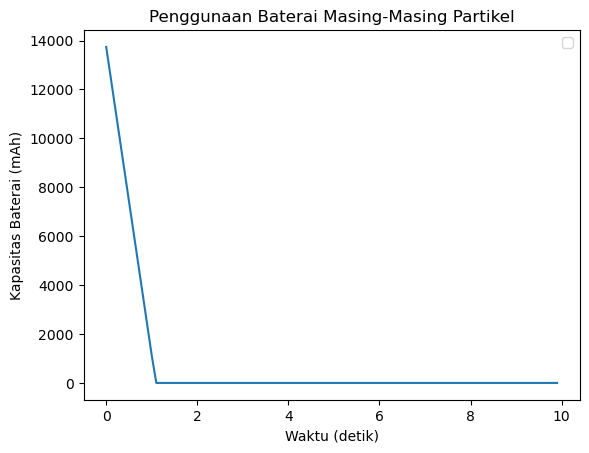

No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.


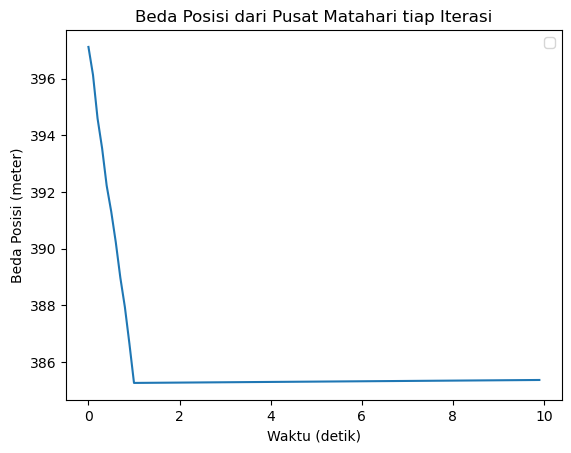

Posisi global terbaik: [418.87513268 622.25741978]
Kapasitas baterai akhir dan persentasenya: 
Drone 1: Kapasitas baterai = 0.002507226252380661 mAh (1.671484168253774e-05%)
Drone 2: Kapasitas baterai = 0.0027479611628515683 mAh (1.8319741085677124e-05%)
Drone 3: Kapasitas baterai = 0.002593723717514158 mAh (1.7291491450094386e-05%)
Drone 4: Kapasitas baterai = 0.002456986696436974 mAh (1.6379911309579828e-05%)
Drone 5: Kapasitas baterai = 0.0027035988621498994 mAh (1.802399241433266e-05%)
Drone 6: Kapasitas baterai = 0.0027219798434849115 mAh (1.814653228989941e-05%)
Drone 7: Kapasitas baterai = 0.002738111096002508 mAh (1.8254073973350054e-05%)
Drone 8: Kapasitas baterai = 0.002376712341876634 mAh (1.584474894584423e-05%)
Drone 9: Kapasitas baterai = 0.002667351391040514 mAh (1.7782342606936758e-05%)
Drone 10: Kapasitas baterai = 0.0027047393628944153 mAh (1.8031595752629436e-05%)
Drone 11: Kapasitas baterai = 0.002609634499231423 mAh (1.7397563328209488e-05%)
Drone 12: Kapasitas bat

In [35]:
import os
import numpy as np
import matplotlib.pyplot as plt

def gauss_sun_intensity(x, y, sun_center, sun_std_dev):
    """Intensitas Gaussian berdasarkan jarak dari titik tengah."""
    return np.exp(-((x - sun_center[0])**2 + (y - sun_center[1])**2) / (2 * sun_std_dev**2))

def fitness_function(pos, sun_center, sun_std_dev, particles, index, min_distance, repulsion_factor):
    """Fitness function untuk memaksimalkan intensitas cahaya dan meminimalkan repulsi."""
    sun_intensity = gauss_sun_intensity(pos[0], pos[1], sun_center, sun_std_dev)

    repulsion = 0
    for j in range(len(particles)):
        if j != index:
            distance = np.linalg.norm(pos - particles[j])
            if distance < min_distance:
                repulsion += repulsion_factor / distance**2

    fitness = -sun_intensity + repulsion
    return fitness

def calculate_energy_consumption(mass, altitude, horizontal_distance, battery_voltage):
    """Menghitung parameter energi dari setiap drone."""
    drag_coefficient = 0.5
    frontal_area = 0.1  
    air_density = 1.225  
    horizontal_speed = 10.0  
    flight_efficiency = 0.8

    E_vertical_J = mass * 9.81 * altitude
    P_drag = 0.5 * drag_coefficient * frontal_area * air_density * horizontal_speed**2
    P_horizontal = (P_drag + mass * 9.81 * horizontal_speed) / flight_efficiency
    E_horizontal_J = P_horizontal * (horizontal_distance / horizontal_speed)
    E_total_J = E_vertical_J + E_horizontal_J
    E_total_Wh = E_total_J / 3600
    energy_consumed = (E_total_Wh * 1000) / battery_voltage
    return energy_consumed

def pso_drone_solar_chaser_with_battery():
    num_particles = 20
    num_iterations = 100
    dim = 2  
    c1 = 1.0
    c2 = 1.5  
    w = 0.1  
    timestep = 0.1  # seconds
    L = 1000  # meters

    drone_mass = 25.5 # massa baterai + massa panel surya (massa baterai yang dipakai yaitu variasi 7 kg dan massa panel surya variasi 5, 15, 30 ) 
    battery_capacity = 15000  
    solar_charge_rate = 100  
    altitude = 200  
    battery_voltage = 11.1  

    sun_center = np.array([L / 2, L / 2])  
    sun_std_dev = 1000  
    sun_speed = 1000 / 28800  # 1 km per 8 jam dalam meters per second

    min_distance = 3  
    repulsion_factor = 1000  

    particles = np.random.rand(num_particles, dim) * L  
    velocities = np.zeros((num_particles, dim))  
    personal_best_positions = particles.copy()
    global_best_position = particles[0, :].copy()
    global_best_fitness = float('inf')

    battery_levels = battery_capacity * np.ones(num_particles)  

    battery_levels_over_time = np.zeros((num_iterations, num_particles))
    position_diff_over_time = np.zeros((num_iterations, num_particles))

    # Folder untuk menyimpan hasil program
    folder_name = "Percobaan_423"
    if not os.path.exists(folder_name):
        os.makedirs(folder_name)

    for iter in range(num_iterations):
        for i in range(num_particles):
            fitness = fitness_function(particles[i, :], sun_center, sun_std_dev, particles, i, min_distance, repulsion_factor)
            if fitness < fitness_function(personal_best_positions[i, :], sun_center, sun_std_dev, particles, i, min_distance, repulsion_factor):
                personal_best_positions[i, :] = particles[i, :]
            if fitness < global_best_fitness:
                global_best_fitness = fitness
                global_best_position = particles[i, :]

        for i in range(num_particles):
            velocities[i, :] = (w * velocities[i, :] +
                                c1 * np.random.rand() * (personal_best_positions[i, :] - particles[i, :]) +
                                c2 * np.random.rand() * (global_best_position - particles[i, :]) / drone_mass * timestep)
            new_position = particles[i, :] + velocities[i, :]  
            new_position = np.clip(new_position, 0, L)
            horizontal_distance = np.linalg.norm(new_position - particles[i, :])
            energy_consumed = calculate_energy_consumption(drone_mass, altitude, horizontal_distance, battery_voltage)
            battery_levels[i] -= energy_consumed
            if battery_levels[i] > 0:
                particles[i, :] = new_position
            else:
                battery_levels[i] = 0

        for i in range(num_particles):
            solar_energy = (solar_charge_rate * 
                            max(0, gauss_sun_intensity(particles[i, 0], particles[i, 1], sun_center, sun_std_dev)) * 
                            timestep / 3600)
            battery_levels[i] = min(battery_levels[i] + solar_energy, battery_capacity)

        battery_levels_over_time[iter, :] = battery_levels
        position_diff_over_time[iter, :] = np.linalg.norm(particles - sun_center, axis=1)

        sun_center[0] += sun_speed * timestep  

        if sun_center[0] > L:
            sun_center[0] = 0

        X, Y = np.meshgrid(np.arange(0, L+1, 10), np.arange(0, L+1, 10))  
        Z = np.array([[gauss_sun_intensity(x, y, sun_center, sun_std_dev) for x in np.arange(0, L+1, 10)] for y in np.arange(0, L+1, 10)])
        
        plt.contourf(X, Y, Z)  
        plt.colorbar()
        plt.clim(0, 1)
        plt.title('Distribusi Matahari')
        plt.plot(particles[:, 0], particles[:, 1], '.r')
        plt.savefig(f'{folder_name}/frame_{iter+1}.png')  
        plt.clf()

        print(f'Iterasi ke-{iter + 1}: Global Best Fitness = {global_best_fitness}')

    time = np.arange(num_iterations) * timestep 
    
    plt.figure()
    for i in range(num_particles):
        plt.plot(time, battery_levels_over_time[:, i], label=f'Particle {i+1}')
    plt.title('Penggunaan Baterai Masing-Masing Partikel')
    plt.xlabel('Waktu (detik)')
    plt.ylabel('Kapasitas Baterai (mAh)')
    plt.legend(loc='best')
    plt.savefig(f'{folder_name}/Kapasitas Baterai Tiap Waktu.png')  
    plt.show()
    
    plt.figure()
    for i in range(num_particles):
        plt.plot(time, position_diff_over_time[:, i], label=f'Particle {i+1}')
    plt.title('Beda Posisi dari Pusat Matahari tiap Waktu')
    plt.xlabel('Waktu (detik)')
    plt.ylabel('Beda Posisi (meter)')
    plt.legend(loc='best')
    plt.savefig(f'{folder_name}/beda_posisi tiap waktu.png')  
    plt.show()

    print(f'Posisi global terbaik: {global_best_position}')
    print('Kapasitas baterai akhir dan persentasenya: ')
    for i in range(num_particles):
        battery_percentage = (battery_levels[i] / battery_capacity) * 100
        print(f'Drone {i + 1}: Kapasitas baterai = {battery_levels[i]} mAh ({battery_percentage}%)')

if __name__ == "__main__":
    pso_drone_solar_chaser_with_battery()


total massa 29,5 kg = massa panel surya (15 kg) + massa baterai (14,5 kg)
kapasitas 20000 mAH

Iterasi ke-1: Global Best Fitness = -0.9924707752718358
Iterasi ke-2: Global Best Fitness = -0.9924707752718358
Iterasi ke-3: Global Best Fitness = -0.9924707752718358
Iterasi ke-4: Global Best Fitness = -0.9924707752718358
Iterasi ke-5: Global Best Fitness = -0.9924707752718358
Iterasi ke-6: Global Best Fitness = -0.9924707752718358
Iterasi ke-7: Global Best Fitness = -0.9924707752718358
Iterasi ke-8: Global Best Fitness = -0.9924707752718358
Iterasi ke-9: Global Best Fitness = -0.9924707752718358
Iterasi ke-10: Global Best Fitness = -0.9924707752718358
Iterasi ke-11: Global Best Fitness = -0.9924707752718358
Iterasi ke-12: Global Best Fitness = -0.9924707752718358
Iterasi ke-13: Global Best Fitness = -0.9924707752718358
Iterasi ke-14: Global Best Fitness = -0.9924707752718358
Iterasi ke-15: Global Best Fitness = -0.9924707752718358
Iterasi ke-16: Global Best Fitness = -0.9924707752718358
Iterasi ke-17: Global Best Fitness = -0.9924707752718358
Iterasi ke-18: Global Best Fitness = -0.

No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.


Iterasi ke-99: Global Best Fitness = -0.9924707752718358
Iterasi ke-100: Global Best Fitness = -0.9924707752718358


<Figure size 640x480 with 0 Axes>

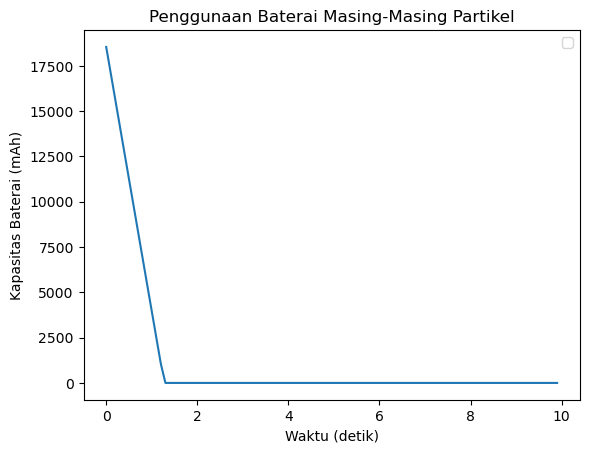

No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.


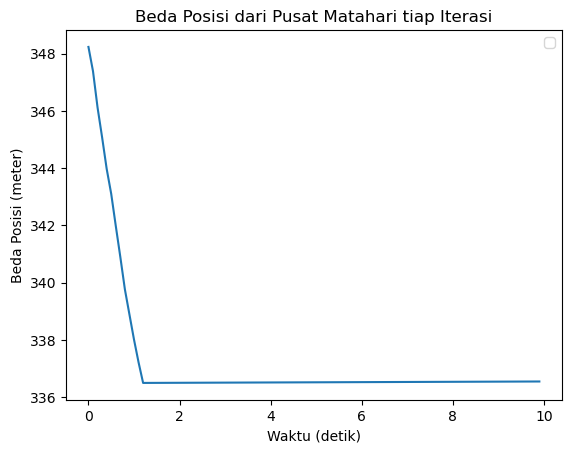

Posisi global terbaik: [405.53767622 421.30886813]
Kapasitas baterai akhir dan persentasenya: 
Drone 1: Kapasitas baterai = 0.0027385556706346196 mAh (1.3692778353173096e-05%)
Drone 2: Kapasitas baterai = 0.0027465774186530467 mAh (1.3732887093265234e-05%)
Drone 3: Kapasitas baterai = 0.002382566364314385 mAh (1.1912831821571925e-05%)
Drone 4: Kapasitas baterai = 0.0024310587365529448 mAh (1.2155293682764723e-05%)
Drone 5: Kapasitas baterai = 0.002724359838229537 mAh (1.3621799191147685e-05%)
Drone 6: Kapasitas baterai = 0.0027000952404522653 mAh (1.3500476202261325e-05%)
Drone 7: Kapasitas baterai = 0.002655510543679198 mAh (1.3277552718395988e-05%)
Drone 8: Kapasitas baterai = 0.0024766604113208293 mAh (1.2383302056604145e-05%)
Drone 9: Kapasitas baterai = 0.0026334498299595424 mAh (1.3167249149797713e-05%)
Drone 10: Kapasitas baterai = 0.002606232467406383 mAh (1.3031162337031914e-05%)
Drone 11: Kapasitas baterai = 0.002721707195029687 mAh (1.3608535975148435e-05%)
Drone 12: Kapasit

In [36]:
import os
import numpy as np
import matplotlib.pyplot as plt

def gauss_sun_intensity(x, y, sun_center, sun_std_dev):
    """Intensitas Gaussian berdasarkan jarak dari titik tengah."""
    return np.exp(-((x - sun_center[0])**2 + (y - sun_center[1])**2) / (2 * sun_std_dev**2))

def fitness_function(pos, sun_center, sun_std_dev, particles, index, min_distance, repulsion_factor):
    """Fitness function untuk memaksimalkan intensitas cahaya dan meminimalkan repulsi."""
    sun_intensity = gauss_sun_intensity(pos[0], pos[1], sun_center, sun_std_dev)

    repulsion = 0
    for j in range(len(particles)):
        if j != index:
            distance = np.linalg.norm(pos - particles[j])
            if distance < min_distance:
                repulsion += repulsion_factor / distance**2

    fitness = -sun_intensity + repulsion
    return fitness

def calculate_energy_consumption(mass, altitude, horizontal_distance, battery_voltage):
    """Menghitung parameter energi dari setiap drone."""
    drag_coefficient = 0.5
    frontal_area = 0.1  
    air_density = 1.225  
    horizontal_speed = 10.0  
    flight_efficiency = 0.8

    E_vertical_J = mass * 9.81 * altitude
    P_drag = 0.5 * drag_coefficient * frontal_area * air_density * horizontal_speed**2
    P_horizontal = (P_drag + mass * 9.81 * horizontal_speed) / flight_efficiency
    E_horizontal_J = P_horizontal * (horizontal_distance / horizontal_speed)
    E_total_J = E_vertical_J + E_horizontal_J
    E_total_Wh = E_total_J / 3600
    energy_consumed = (E_total_Wh * 1000) / battery_voltage
    return energy_consumed

def pso_drone_solar_chaser_with_battery():
    num_particles = 20
    num_iterations = 100
    dim = 2  
    c1 = 1.0
    c2 = 1.5  
    w = 0.1  
    timestep = 0.1  # seconds
    L = 1000  # meters

    drone_mass = 29.5 # massa baterai + massa panel surya (massa baterai yang dipakai yaitu variasi 7 kg dan massa panel surya variasi 5, 15, 30 ) 
    battery_capacity = 20000  
    solar_charge_rate = 100  
    altitude = 200  
    battery_voltage = 11.1  

    sun_center = np.array([L / 2, L / 2])  
    sun_std_dev = 1000  
    sun_speed = 1000 / 28800  # 1 km per 8 jam dalam meters per second

    min_distance = 3  
    repulsion_factor = 1000  

    particles = np.random.rand(num_particles, dim) * L  
    velocities = np.zeros((num_particles, dim))  
    personal_best_positions = particles.copy()
    global_best_position = particles[0, :].copy()
    global_best_fitness = float('inf')

    battery_levels = battery_capacity * np.ones(num_particles)  

    battery_levels_over_time = np.zeros((num_iterations, num_particles))
    position_diff_over_time = np.zeros((num_iterations, num_particles))

    # Folder untuk menyimpan hasil program
    folder_name = "Percobaan_424"
    if not os.path.exists(folder_name):
        os.makedirs(folder_name)

    for iter in range(num_iterations):
        for i in range(num_particles):
            fitness = fitness_function(particles[i, :], sun_center, sun_std_dev, particles, i, min_distance, repulsion_factor)
            if fitness < fitness_function(personal_best_positions[i, :], sun_center, sun_std_dev, particles, i, min_distance, repulsion_factor):
                personal_best_positions[i, :] = particles[i, :]
            if fitness < global_best_fitness:
                global_best_fitness = fitness
                global_best_position = particles[i, :]

        for i in range(num_particles):
            velocities[i, :] = (w * velocities[i, :] +
                                c1 * np.random.rand() * (personal_best_positions[i, :] - particles[i, :]) +
                                c2 * np.random.rand() * (global_best_position - particles[i, :]) / drone_mass * timestep)
            new_position = particles[i, :] + velocities[i, :]  
            new_position = np.clip(new_position, 0, L)
            horizontal_distance = np.linalg.norm(new_position - particles[i, :])
            energy_consumed = calculate_energy_consumption(drone_mass, altitude, horizontal_distance, battery_voltage)
            battery_levels[i] -= energy_consumed
            if battery_levels[i] > 0:
                particles[i, :] = new_position
            else:
                battery_levels[i] = 0

        for i in range(num_particles):
            solar_energy = (solar_charge_rate * 
                            max(0, gauss_sun_intensity(particles[i, 0], particles[i, 1], sun_center, sun_std_dev)) * 
                            timestep / 3600)
            battery_levels[i] = min(battery_levels[i] + solar_energy, battery_capacity)

        battery_levels_over_time[iter, :] = battery_levels
        position_diff_over_time[iter, :] = np.linalg.norm(particles - sun_center, axis=1)

        sun_center[0] += sun_speed * timestep  

        if sun_center[0] > L:
            sun_center[0] = 0

        X, Y = np.meshgrid(np.arange(0, L+1, 10), np.arange(0, L+1, 10))  
        Z = np.array([[gauss_sun_intensity(x, y, sun_center, sun_std_dev) for x in np.arange(0, L+1, 10)] for y in np.arange(0, L+1, 10)])
        
        plt.contourf(X, Y, Z)  
        plt.colorbar()
        plt.clim(0, 1)
        plt.title('Distribusi Matahari')
        plt.plot(particles[:, 0], particles[:, 1], '.r')
        plt.savefig(f'{folder_name}/frame_{iter+1}.png')  
        plt.clf()

        print(f'Iterasi ke-{iter + 1}: Global Best Fitness = {global_best_fitness}')

    time = np.arange(num_iterations) * timestep 
    
    plt.figure()
    for i in range(num_particles):
        plt.plot(time, battery_levels_over_time[:, i], label=f'Particle {i+1}')
    plt.title('Penggunaan Baterai Masing-Masing Partikel')
    plt.xlabel('Waktu (detik)')
    plt.ylabel('Kapasitas Baterai (mAh)')
    plt.legend(loc='best')
    plt.savefig(f'{folder_name}/Kapasitas Baterai Tiap Waktu.png')  
    plt.show()
    
    plt.figure()
    for i in range(num_particles):
        plt.plot(time, position_diff_over_time[:, i], label=f'Particle {i+1}')
    plt.title('Beda Posisi dari Pusat Matahari tiap Waktu')
    plt.xlabel('Waktu (detik)')
    plt.ylabel('Beda Posisi (meter)')
    plt.legend(loc='best')
    plt.savefig(f'{folder_name}/beda_posisi tiap waktu.png')  
    plt.show()

    print(f'Posisi global terbaik: {global_best_position}')
    print('Kapasitas baterai akhir dan persentasenya: ')
    for i in range(num_particles):
        battery_percentage = (battery_levels[i] / battery_capacity) * 100
        print(f'Drone {i + 1}: Kapasitas baterai = {battery_levels[i]} mAh ({battery_percentage}%)')

if __name__ == "__main__":
    pso_drone_solar_chaser_with_battery()


Iterasi ke-1: Global Best Fitness = -0.9985049404849057
Iterasi ke-2: Global Best Fitness = -0.9985049404849057
Iterasi ke-3: Global Best Fitness = -0.9985049404849057
Iterasi ke-4: Global Best Fitness = -0.9985049404849057
Iterasi ke-5: Global Best Fitness = -0.9985049404849057
Iterasi ke-6: Global Best Fitness = -0.9985049404849057
Iterasi ke-7: Global Best Fitness = -0.9985049404849057
Iterasi ke-8: Global Best Fitness = -0.9985049404849057
Iterasi ke-9: Global Best Fitness = -0.9985049404849057
Iterasi ke-10: Global Best Fitness = -0.9985049404849057
Iterasi ke-11: Global Best Fitness = -0.9985049404849057
Iterasi ke-12: Global Best Fitness = -0.9985049404849057
Iterasi ke-13: Global Best Fitness = -0.9985049404849057
Iterasi ke-14: Global Best Fitness = -0.9985049404849057
Iterasi ke-15: Global Best Fitness = -0.999270970807429
Iterasi ke-16: Global Best Fitness = -0.9995155644917885
Iterasi ke-17: Global Best Fitness = -0.9996292538099215
Iterasi ke-18: Global Best Fitness = -0.9

<Figure size 640x480 with 0 Axes>

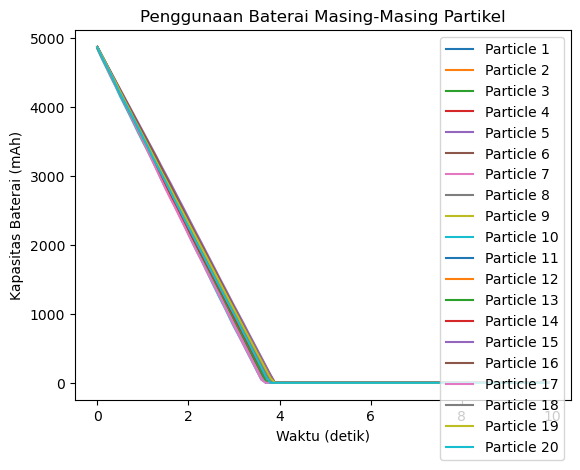

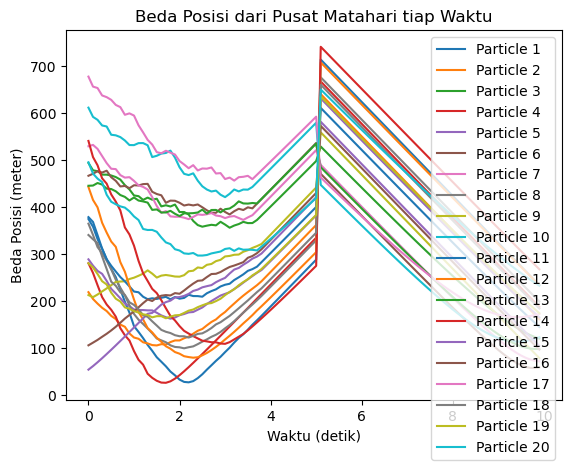

Posisi global terbaik: [666.19079951 473.48009954]
Kapasitas baterai akhir dan persentasenya: 
Drone 1: Kapasitas baterai = 0.0027027106508548068 mAh (5.405421301709613e-05%)
Drone 2: Kapasitas baterai = 0.0027416414264388386 mAh (5.483282852877677e-05%)
Drone 3: Kapasitas baterai = 0.0027575988006391756 mAh (5.515197601278351e-05%)
Drone 4: Kapasitas baterai = 0.0027290841809446973 mAh (5.458168361889395e-05%)
Drone 5: Kapasitas baterai = 0.0027398071754665635 mAh (5.479614350933127e-05%)
Drone 6: Kapasitas baterai = 0.002772865613526144 mAh (5.545731227052288e-05%)
Drone 7: Kapasitas baterai = 0.002770509295896398 mAh (5.541018591792796e-05%)
Drone 8: Kapasitas baterai = 0.002723095862528692 mAh (5.446191725057384e-05%)
Drone 9: Kapasitas baterai = 0.00276907819824863 mAh (5.53815639649726e-05%)
Drone 10: Kapasitas baterai = 0.002756582312374543 mAh (5.513164624749086e-05%)
Drone 11: Kapasitas baterai = 0.0027485631344353815 mAh (5.497126268870763e-05%)
Drone 12: Kapasitas baterai = 

In [16]:
import os
import numpy as np
import matplotlib.pyplot as plt

def gauss_sun_intensity(x, y, sun_center, sun_std_dev):
    """Intensitas Gaussian berdasarkan jarak dari titik tengah."""
    return np.exp(-((x - sun_center[0])**2 + (y - sun_center[1])**2) / (2 * sun_std_dev**2))

def fitness_function(pos, sun_center, sun_std_dev, particles, index, min_distance, repulsion_factor):
    """Fitness function untuk memaksimalkan intensitas cahaya dan meminimalkan repulsi."""
    sun_intensity = gauss_sun_intensity(pos[0], pos[1], sun_center, sun_std_dev)

    repulsion = 0
    for j in range(len(particles)):
        if j != index:
            distance = np.linalg.norm(pos - particles[j])
            if distance < min_distance:
                repulsion += repulsion_factor / distance**2

    fitness = -sun_intensity + repulsion
    return fitness

def calculate_energy_consumption(mass, altitude, horizontal_distance, battery_voltage):
    """Menghitung parameter energi dari setiap drone."""
    drag_coefficient = 0.5
    frontal_area = 0.1  
    air_density = 1.225  
    horizontal_speed = 10.0  
    flight_efficiency = 0.8

    E_vertical_J = mass * 9.81 * altitude
    P_drag = 0.5 * drag_coefficient * frontal_area * air_density * horizontal_speed**2
    P_horizontal = (P_drag + mass * 9.81 * horizontal_speed) / flight_efficiency
    E_horizontal_J = P_horizontal * (horizontal_distance / horizontal_speed)
    E_total_J = E_vertical_J + E_horizontal_J
    E_total_Wh = E_total_J / 3600
    energy_consumed = (E_total_Wh * 1000) / battery_voltage
    return energy_consumed

def pso_drone_solar_chaser_with_battery():
    num_particles = 20
    num_iterations = 100
    dim = 2  
    c1 = 1.0
    c2 = 1.5  
    w = 0.1  
    timestep = 0.1  # seconds
    L = 1000  # meters

    drone_mass = 2.5 # massa baterai + massa panel surya (massa baterai yang dipakai yaitu variasi 7 kg dan massa panel surya variasi 5, 15, 30 ) 
    battery_capacity = 5000  
    solar_charge_rate = 100  
    altitude = 200  
    battery_voltage = 11.1  

    sun_center = np.array([L / 2, L / 2])  
    sun_std_dev = 1000  
    sun_speed = 100  # 1 km per 8 jam dalam meters per second

    min_distance = 3  
    repulsion_factor = 1000  

    particles = np.random.rand(num_particles, dim) * L  
    velocities = np.zeros((num_particles, dim))  
    personal_best_positions = particles.copy()
    global_best_position = particles[0, :].copy()
    global_best_fitness = float('inf')

    battery_levels = battery_capacity * np.ones(num_particles)  

    battery_levels_over_time = np.zeros((num_iterations, num_particles))
    position_diff_over_time = np.zeros((num_iterations, num_particles))

    # Folder untuk menyimpan hasil program
    folder_name = "Percobaan_Matahari_Bergerak"
    if not os.path.exists(folder_name):
        os.makedirs(folder_name)

    for iter in range(num_iterations):
        for i in range(num_particles):
            fitness = fitness_function(particles[i, :], sun_center, sun_std_dev, particles, i, min_distance, repulsion_factor)
            if fitness < fitness_function(personal_best_positions[i, :], sun_center, sun_std_dev, particles, i, min_distance, repulsion_factor):
                personal_best_positions[i, :] = particles[i, :]
            if fitness < global_best_fitness:
                global_best_fitness = fitness
                global_best_position = particles[i, :]

        for i in range(num_particles):
            velocities[i, :] = (w * velocities[i, :] +
                                c1 * np.random.rand() * (personal_best_positions[i, :] - particles[i, :]) +
                                c2 * np.random.rand() * (global_best_position - particles[i, :]) / drone_mass * timestep)
            new_position = particles[i, :] + velocities[i, :]  
            new_position = np.clip(new_position, 0, L)
            horizontal_distance = np.linalg.norm(new_position - particles[i, :])
            energy_consumed = calculate_energy_consumption(drone_mass, altitude, horizontal_distance, battery_voltage)
            battery_levels[i] -= energy_consumed
            if battery_levels[i] > 0:
                particles[i, :] = new_position
            else:
                battery_levels[i] = 0

        for i in range(num_particles):
            solar_energy = (solar_charge_rate * 
                            max(0, gauss_sun_intensity(particles[i, 0], particles[i, 1], sun_center, sun_std_dev)) * 
                            timestep / 3600)
            battery_levels[i] = min(battery_levels[i] + solar_energy, battery_capacity)

        battery_levels_over_time[iter, :] = battery_levels
        position_diff_over_time[iter, :] = np.linalg.norm(particles - sun_center, axis=1)

        sun_center[0] += sun_speed * timestep  

        if sun_center[0] > L:
            sun_center[0] = 0

        X, Y = np.meshgrid(np.arange(0, L+1, 10), np.arange(0, L+1, 10))  
        Z = np.array([[gauss_sun_intensity(x, y, sun_center, sun_std_dev) for x in np.arange(0, L+1, 10)] for y in np.arange(0, L+1, 10)])
        
        plt.contourf(X, Y, Z)  
        plt.colorbar()
        plt.clim(0, 1)
        plt.title('Distribusi Matahari')
        plt.plot(particles[:, 0], particles[:, 1], '.r')
        plt.savefig(f'{folder_name}/frame_{iter+1}.png')  
        plt.clf()

        print(f'Iterasi ke-{iter + 1}: Global Best Fitness = {global_best_fitness}')

    time = np.arange(num_iterations) * timestep 
    
    plt.figure()
    for i in range(num_particles):
        plt.plot(time, battery_levels_over_time[:, i], label=f'Particle {i+1}')
    plt.title('Penggunaan Baterai Masing-Masing Partikel')
    plt.xlabel('Waktu (detik)')
    plt.ylabel('Kapasitas Baterai (mAh)')
    plt.legend(loc='best')
    plt.savefig(f'{folder_name}/Kapasitas Baterai Tiap Waktu.png')  
    plt.show()
    
    plt.figure()
    for i in range(num_particles):
        plt.plot(time, position_diff_over_time[:, i], label=f'Particle {i+1}')
    plt.title('Beda Posisi dari Pusat Matahari tiap Waktu')
    plt.xlabel('Waktu (detik)')
    plt.ylabel('Beda Posisi (meter)')
    plt.legend(loc='best')
    plt.savefig(f'{folder_name}/beda_posisi tiap waktu.png')  
    plt.show()

    print(f'Posisi global terbaik: {global_best_position}')
    print('Kapasitas baterai akhir dan persentasenya: ')
    for i in range(num_particles):
        battery_percentage = (battery_levels[i] / battery_capacity) * 100
        print(f'Drone {i + 1}: Kapasitas baterai = {battery_levels[i]} mAh ({battery_percentage}%)')

if __name__ == "__main__":
    pso_drone_solar_chaser_with_battery()


### Variasi Jarak
Variasi jarak terdiri dari variasi jarak-jarak dua dimensi:
- 1000 x 1000
- 500 x 500 (511)
- 250 x 250 (512)
- 125 x 125 (513)

Iterasi ke-1: Global Best Fitness = -0.9988290833298045
Iterasi ke-2: Global Best Fitness = -0.9988290833298045
Iterasi ke-3: Global Best Fitness = -0.9988290833298045
Iterasi ke-4: Global Best Fitness = -0.9988290833298045
Iterasi ke-5: Global Best Fitness = -0.9988290833298045
Iterasi ke-6: Global Best Fitness = -0.9988290833298045
Iterasi ke-7: Global Best Fitness = -0.9988290833298045
Iterasi ke-8: Global Best Fitness = -0.9988290833298045
Iterasi ke-9: Global Best Fitness = -0.9988290833298045
Iterasi ke-10: Global Best Fitness = -0.9988290833298045
Iterasi ke-11: Global Best Fitness = -0.9988290833298045
Iterasi ke-12: Global Best Fitness = -0.9988290833298045
Iterasi ke-13: Global Best Fitness = -0.9988290833298045
Iterasi ke-14: Global Best Fitness = -0.9988290833298045
Iterasi ke-15: Global Best Fitness = -0.9988290833298045
Iterasi ke-16: Global Best Fitness = -0.9988290833298045
Iterasi ke-17: Global Best Fitness = -0.9988290833298045
Iterasi ke-18: Global Best Fitness = -0.

No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.


Iterasi ke-100: Global Best Fitness = -0.9996006217940233


<Figure size 640x480 with 0 Axes>

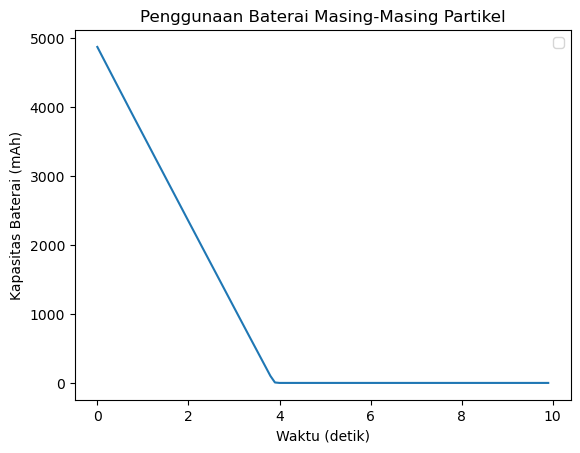

No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.


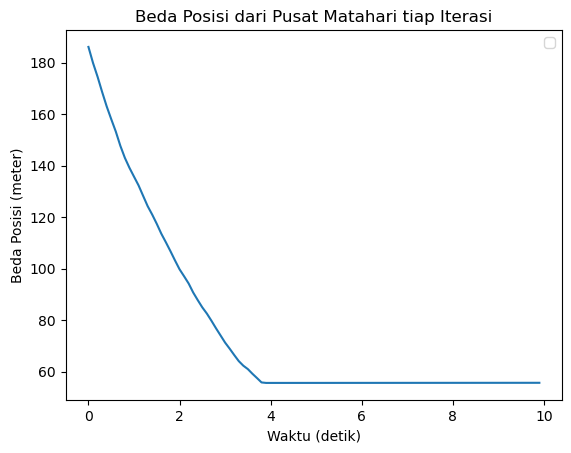

Posisi global terbaik: [221.90632975 248.64406417]
Kapasitas baterai akhir dan persentasenya: 
Drone 1: Kapasitas baterai = 0.0027660636961643528 mAh (5.5321273923287056e-05%)
Drone 2: Kapasitas baterai = 0.0027747353985788535 mAh (5.549470797157707e-05%)
Drone 3: Kapasitas baterai = 0.0027713101678615362 mAh (5.542620335723073e-05%)
Drone 4: Kapasitas baterai = 0.0027722343816530223 mAh (5.544468763306044e-05%)
Drone 5: Kapasitas baterai = 0.0027684521522692326 mAh (5.536904304538465e-05%)
Drone 6: Kapasitas baterai = 0.002776653568358399 mAh (5.553307136716798e-05%)
Drone 7: Kapasitas baterai = 0.0027737524134999973 mAh (5.547504826999995e-05%)
Drone 8: Kapasitas baterai = 0.002775643386591133 mAh (5.551286773182266e-05%)
Drone 9: Kapasitas baterai = 0.0027743428496452404 mAh (5.5486856992904806e-05%)
Drone 10: Kapasitas baterai = 0.002775814298586681 mAh (5.551628597173363e-05%)
Drone 11: Kapasitas baterai = 0.002770536008436742 mAh (5.541072016873484e-05%)
Drone 12: Kapasitas bater

In [38]:
import os
import numpy as np
import matplotlib.pyplot as plt

def gauss_sun_intensity(x, y, sun_center, sun_std_dev):
    """Intensitas Gaussian berdasarkan jarak dari titik tengah."""
    return np.exp(-((x - sun_center[0])**2 + (y - sun_center[1])**2) / (2 * sun_std_dev**2))

def fitness_function(pos, sun_center, sun_std_dev, particles, index, min_distance, repulsion_factor):
    """Fitness function untuk memaksimalkan intensitas cahaya dan meminimalkan repulsi."""
    sun_intensity = gauss_sun_intensity(pos[0], pos[1], sun_center, sun_std_dev)

    repulsion = 0
    for j in range(len(particles)):
        if j != index:
            distance = np.linalg.norm(pos - particles[j])
            if distance < min_distance:
                repulsion += repulsion_factor / distance**2

    fitness = -sun_intensity + repulsion
    return fitness

def calculate_energy_consumption(mass, altitude, horizontal_distance, battery_voltage):
    """Menghitung parameter energi dari setiap drone."""
    drag_coefficient = 0.5
    frontal_area = 0.1  
    air_density = 1.225  
    horizontal_speed = 10.0  
    flight_efficiency = 0.8

    E_vertical_J = mass * 9.81 * altitude
    P_drag = 0.5 * drag_coefficient * frontal_area * air_density * horizontal_speed**2
    P_horizontal = (P_drag + mass * 9.81 * horizontal_speed) / flight_efficiency
    E_horizontal_J = P_horizontal * (horizontal_distance / horizontal_speed)
    E_total_J = E_vertical_J + E_horizontal_J
    E_total_Wh = E_total_J / 3600
    energy_consumed = (E_total_Wh * 1000) / battery_voltage
    return energy_consumed

def pso_drone_solar_chaser_with_battery():
    num_particles = 30
    num_iterations = 100
    dim = 2  
    c1 = 1.0
    c2 = 1.5  
    w = 0.1  
    timestep = 0.1  # seconds
    L = 500  # meters

    drone_mass = 2.5 # massa baterai + massa panel surya (massa baterai yang dipakai yaitu variasi 7 kg dan massa panel surya variasi 5, 15, 30 ) 
    battery_capacity = 5000  
    solar_charge_rate = 100  
    altitude = 200  
    battery_voltage = 11.1  

    sun_center = np.array([L / 2, L / 2])  
    sun_std_dev = 1000  
    sun_speed = 1000 / 28800  # 1 km per 8 jam dalam meters per second

    min_distance = 3  
    repulsion_factor = 1000  

    particles = np.random.rand(num_particles, dim) * L  
    velocities = np.zeros((num_particles, dim))  
    personal_best_positions = particles.copy()
    global_best_position = particles[0, :].copy()
    global_best_fitness = float('inf')

    battery_levels = battery_capacity * np.ones(num_particles)  

    battery_levels_over_time = np.zeros((num_iterations, num_particles))
    position_diff_over_time = np.zeros((num_iterations, num_particles))

    # Folder untuk menyimpan hasil program
    folder_name = "Percobaan_511"
    if not os.path.exists(folder_name):
        os.makedirs(folder_name)

    for iter in range(num_iterations):
        for i in range(num_particles):
            fitness = fitness_function(particles[i, :], sun_center, sun_std_dev, particles, i, min_distance, repulsion_factor)
            if fitness < fitness_function(personal_best_positions[i, :], sun_center, sun_std_dev, particles, i, min_distance, repulsion_factor):
                personal_best_positions[i, :] = particles[i, :]
            if fitness < global_best_fitness:
                global_best_fitness = fitness
                global_best_position = particles[i, :]

        for i in range(num_particles):
            velocities[i, :] = (w * velocities[i, :] +
                                c1 * np.random.rand() * (personal_best_positions[i, :] - particles[i, :]) +
                                c2 * np.random.rand() * (global_best_position - particles[i, :]) / drone_mass * timestep)
            new_position = particles[i, :] + velocities[i, :]  
            new_position = np.clip(new_position, 0, L)
            horizontal_distance = np.linalg.norm(new_position - particles[i, :])
            energy_consumed = calculate_energy_consumption(drone_mass, altitude, horizontal_distance, battery_voltage)
            battery_levels[i] -= energy_consumed
            if battery_levels[i] > 0:
                particles[i, :] = new_position
            else:
                battery_levels[i] = 0

        for i in range(num_particles):
            solar_energy = (solar_charge_rate * 
                            max(0, gauss_sun_intensity(particles[i, 0], particles[i, 1], sun_center, sun_std_dev)) * 
                            timestep / 3600)
            battery_levels[i] = min(battery_levels[i] + solar_energy, battery_capacity)

        battery_levels_over_time[iter, :] = battery_levels
        position_diff_over_time[iter, :] = np.linalg.norm(particles - sun_center, axis=1)

        sun_center[0] += sun_speed * timestep  

        if sun_center[0] > L:
            sun_center[0] = 0

        X, Y = np.meshgrid(np.arange(0, L+1, 10), np.arange(0, L+1, 10))  
        Z = np.array([[gauss_sun_intensity(x, y, sun_center, sun_std_dev) for x in np.arange(0, L+1, 10)] for y in np.arange(0, L+1, 10)])
        
        plt.contourf(X, Y, Z)  
        plt.colorbar()
        plt.clim(0, 1)
        plt.title('Distribusi Matahari')
        plt.plot(particles[:, 0], particles[:, 1], '.r')
        plt.savefig(f'{folder_name}/frame_{iter+1}.png')  
        plt.clf()

        print(f'Iterasi ke-{iter + 1}: Global Best Fitness = {global_best_fitness}')

    time = np.arange(num_iterations) * timestep 
    
    plt.figure()
    for i in range(num_particles):
        plt.plot(time, battery_levels_over_time[:, i], label=f'Particle {i+1}')
    plt.title('Penggunaan Baterai Masing-Masing Partikel')
    plt.xlabel('Waktu (detik)')
    plt.ylabel('Kapasitas Baterai (mAh)')
    plt.legend(loc='best')
    plt.savefig(f'{folder_name}/Kapasitas Baterai Tiap Waktu.png')  
    plt.show()
    
    plt.figure()
    for i in range(num_particles):
        plt.plot(time, position_diff_over_time[:, i], label=f'Particle {i+1}')
    plt.title('Beda Posisi dari Pusat Matahari tiap Waktu')
    plt.xlabel('Waktu (detik)')
    plt.ylabel('Beda Posisi (meter)')
    plt.legend(loc='best')
    plt.savefig(f'{folder_name}/beda_posisi tiap waktu.png')  
    plt.show()

    print(f'Posisi global terbaik: {global_best_position}')
    print('Kapasitas baterai akhir dan persentasenya: ')
    for i in range(num_particles):
        battery_percentage = (battery_levels[i] / battery_capacity) * 100
        print(f'Drone {i + 1}: Kapasitas baterai = {battery_levels[i]} mAh ({battery_percentage}%)')

if __name__ == "__main__":
    pso_drone_solar_chaser_with_battery()


Iterasi ke-1: Global Best Fitness = -0.9998376067063177
Iterasi ke-2: Global Best Fitness = -0.9998376623960635
Iterasi ke-3: Global Best Fitness = -0.9998377180737581
Iterasi ke-4: Global Best Fitness = -0.9998377737394013
Iterasi ke-5: Global Best Fitness = -0.9998378293929934
Iterasi ke-6: Global Best Fitness = -0.9998472072742087
Iterasi ke-7: Global Best Fitness = -0.9998590018152351
Iterasi ke-8: Global Best Fitness = -0.9998610710738451
Iterasi ke-9: Global Best Fitness = -0.9998723031785143
Iterasi ke-10: Global Best Fitness = -0.999873571981345
Iterasi ke-11: Global Best Fitness = -0.9998895964803741
Iterasi ke-12: Global Best Fitness = -0.9998919701777113
Iterasi ke-13: Global Best Fitness = -0.9998922453039878
Iterasi ke-14: Global Best Fitness = -0.9998923121387217
Iterasi ke-15: Global Best Fitness = -0.9998999124580423
Iterasi ke-16: Global Best Fitness = -0.9999014428567328
Iterasi ke-17: Global Best Fitness = -0.9999166052273116
Iterasi ke-18: Global Best Fitness = -0.9

No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.


Iterasi ke-100: Global Best Fitness = -0.9999832075813029


<Figure size 640x480 with 0 Axes>

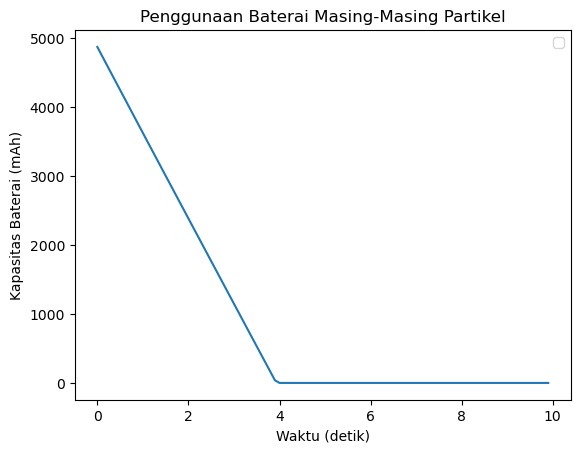

No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.


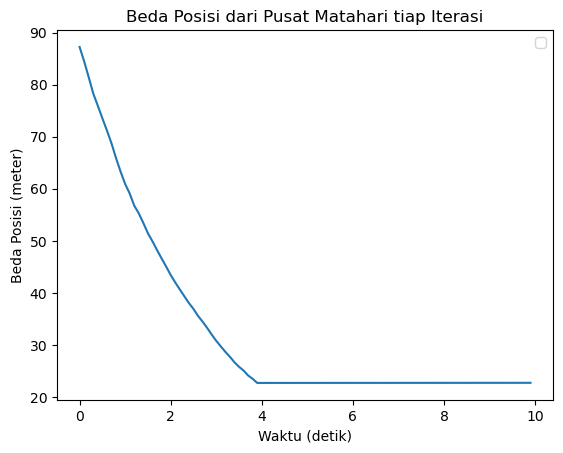

Posisi global terbaik: [130.69152676 122.76697445]
Kapasitas baterai akhir dan persentasenya: 
Drone 1: Kapasitas baterai = 0.002777605983542638 mAh (5.5552119670852756e-05%)
Drone 2: Kapasitas baterai = 0.00277729411334652 mAh (5.5545882266930396e-05%)
Drone 3: Kapasitas baterai = 0.0027774312601027886 mAh (5.554862520205577e-05%)
Drone 4: Kapasitas baterai = 0.0027769541443449894 mAh (5.553908288689979e-05%)
Drone 5: Kapasitas baterai = 0.0027735027447478825 mAh (5.547005489495765e-05%)
Drone 6: Kapasitas baterai = 0.0027773198609257776 mAh (5.554639721851555e-05%)
Drone 7: Kapasitas baterai = 0.0027772511682715812 mAh (5.5545023365431624e-05%)
Drone 8: Kapasitas baterai = 0.00277685479433559 mAh (5.55370958867118e-05%)
Drone 9: Kapasitas baterai = 0.0027772870204336633 mAh (5.554574040867327e-05%)
Drone 10: Kapasitas baterai = 0.0027751574020987136 mAh (5.5503148041974276e-05%)
Drone 11: Kapasitas baterai = 0.0027769240135916582 mAh (5.553848027183316e-05%)
Drone 12: Kapasitas bater

In [39]:
import os
import numpy as np
import matplotlib.pyplot as plt

def gauss_sun_intensity(x, y, sun_center, sun_std_dev):
    """Intensitas Gaussian berdasarkan jarak dari titik tengah."""
    return np.exp(-((x - sun_center[0])**2 + (y - sun_center[1])**2) / (2 * sun_std_dev**2))

def fitness_function(pos, sun_center, sun_std_dev, particles, index, min_distance, repulsion_factor):
    """Fitness function untuk memaksimalkan intensitas cahaya dan meminimalkan repulsi."""
    sun_intensity = gauss_sun_intensity(pos[0], pos[1], sun_center, sun_std_dev)

    repulsion = 0
    for j in range(len(particles)):
        if j != index:
            distance = np.linalg.norm(pos - particles[j])
            if distance < min_distance:
                repulsion += repulsion_factor / distance**2

    fitness = -sun_intensity + repulsion
    return fitness

def calculate_energy_consumption(mass, altitude, horizontal_distance, battery_voltage):
    """Menghitung parameter energi dari setiap drone."""
    drag_coefficient = 0.5
    frontal_area = 0.1  
    air_density = 1.225  
    horizontal_speed = 10.0  
    flight_efficiency = 0.8

    E_vertical_J = mass * 9.81 * altitude
    P_drag = 0.5 * drag_coefficient * frontal_area * air_density * horizontal_speed**2
    P_horizontal = (P_drag + mass * 9.81 * horizontal_speed) / flight_efficiency
    E_horizontal_J = P_horizontal * (horizontal_distance / horizontal_speed)
    E_total_J = E_vertical_J + E_horizontal_J
    E_total_Wh = E_total_J / 3600
    energy_consumed = (E_total_Wh * 1000) / battery_voltage
    return energy_consumed

def pso_drone_solar_chaser_with_battery():
    num_particles = 30
    num_iterations = 100
    dim = 2  
    c1 = 1.0
    c2 = 1.5  
    w = 0.1  
    timestep = 0.1  # seconds
    L = 250  # meters

    drone_mass = 2.5 # massa baterai + massa panel surya (massa baterai yang dipakai yaitu variasi 7 kg dan massa panel surya variasi 5, 15, 30 ) 
    battery_capacity = 5000  
    solar_charge_rate = 100  
    altitude = 200  
    battery_voltage = 11.1  

    sun_center = np.array([L / 2, L / 2])  
    sun_std_dev = 1000  
    sun_speed = 1000 / 28800  # 1 km per 8 jam dalam meters per second

    min_distance = 3  
    repulsion_factor = 1000  

    particles = np.random.rand(num_particles, dim) * L  
    velocities = np.zeros((num_particles, dim))  
    personal_best_positions = particles.copy()
    global_best_position = particles[0, :].copy()
    global_best_fitness = float('inf')

    battery_levels = battery_capacity * np.ones(num_particles)  

    battery_levels_over_time = np.zeros((num_iterations, num_particles))
    position_diff_over_time = np.zeros((num_iterations, num_particles))

    # Folder untuk menyimpan hasil program
    folder_name = "Percobaan_512"
    if not os.path.exists(folder_name):
        os.makedirs(folder_name)

    for iter in range(num_iterations):
        for i in range(num_particles):
            fitness = fitness_function(particles[i, :], sun_center, sun_std_dev, particles, i, min_distance, repulsion_factor)
            if fitness < fitness_function(personal_best_positions[i, :], sun_center, sun_std_dev, particles, i, min_distance, repulsion_factor):
                personal_best_positions[i, :] = particles[i, :]
            if fitness < global_best_fitness:
                global_best_fitness = fitness
                global_best_position = particles[i, :]

        for i in range(num_particles):
            velocities[i, :] = (w * velocities[i, :] +
                                c1 * np.random.rand() * (personal_best_positions[i, :] - particles[i, :]) +
                                c2 * np.random.rand() * (global_best_position - particles[i, :]) / drone_mass * timestep)
            new_position = particles[i, :] + velocities[i, :]  
            new_position = np.clip(new_position, 0, L)
            horizontal_distance = np.linalg.norm(new_position - particles[i, :])
            energy_consumed = calculate_energy_consumption(drone_mass, altitude, horizontal_distance, battery_voltage)
            battery_levels[i] -= energy_consumed
            if battery_levels[i] > 0:
                particles[i, :] = new_position
            else:
                battery_levels[i] = 0

        for i in range(num_particles):
            solar_energy = (solar_charge_rate * 
                            max(0, gauss_sun_intensity(particles[i, 0], particles[i, 1], sun_center, sun_std_dev)) * 
                            timestep / 3600)
            battery_levels[i] = min(battery_levels[i] + solar_energy, battery_capacity)

        battery_levels_over_time[iter, :] = battery_levels
        position_diff_over_time[iter, :] = np.linalg.norm(particles - sun_center, axis=1)

        sun_center[0] += sun_speed * timestep  

        if sun_center[0] > L:
            sun_center[0] = 0

        X, Y = np.meshgrid(np.arange(0, L+1, 10), np.arange(0, L+1, 10))  
        Z = np.array([[gauss_sun_intensity(x, y, sun_center, sun_std_dev) for x in np.arange(0, L+1, 10)] for y in np.arange(0, L+1, 10)])
        
        plt.contourf(X, Y, Z)  
        plt.colorbar()
        plt.clim(0, 1)
        plt.title('Distribusi Matahari')
        plt.plot(particles[:, 0], particles[:, 1], '.r')
        plt.savefig(f'{folder_name}/frame_{iter+1}.png')  
        plt.clf()

        print(f'Iterasi ke-{iter + 1}: Global Best Fitness = {global_best_fitness}')

    time = np.arange(num_iterations) * timestep 
    
    plt.figure()
    for i in range(num_particles):
        plt.plot(time, battery_levels_over_time[:, i], label=f'Particle {i+1}')
    plt.title('Penggunaan Baterai Masing-Masing Partikel')
    plt.xlabel('Waktu (detik)')
    plt.ylabel('Kapasitas Baterai (mAh)')
    plt.legend(loc='best')
    plt.savefig(f'{folder_name}/Kapasitas Baterai Tiap Waktu.png')  
    plt.show()
    
    plt.figure()
    for i in range(num_particles):
        plt.plot(time, position_diff_over_time[:, i], label=f'Particle {i+1}')
    plt.title('Beda Posisi dari Pusat Matahari tiap Waktu')
    plt.xlabel('Waktu (detik)')
    plt.ylabel('Beda Posisi (meter)')
    plt.legend(loc='best')
    plt.savefig(f'{folder_name}/beda_posisi tiap waktu.png')  
    plt.show()

    print(f'Posisi global terbaik: {global_best_position}')
    print('Kapasitas baterai akhir dan persentasenya: ')
    for i in range(num_particles):
        battery_percentage = (battery_levels[i] / battery_capacity) * 100
        print(f'Drone {i + 1}: Kapasitas baterai = {battery_levels[i]} mAh ({battery_percentage}%)')

if __name__ == "__main__":
    pso_drone_solar_chaser_with_battery()


Iterasi ke-1: Global Best Fitness = -0.9999625887105481
Iterasi ke-2: Global Best Fitness = -0.9999626141507897
Iterasi ke-3: Global Best Fitness = -0.999962639578976
Iterasi ke-4: Global Best Fitness = -0.999962664995107
Iterasi ke-5: Global Best Fitness = -0.9999626903991828
Iterasi ke-6: Global Best Fitness = -0.9999627157912034
Iterasi ke-7: Global Best Fitness = -0.9999627411711688
Iterasi ke-8: Global Best Fitness = -0.9999627665390789
Iterasi ke-9: Global Best Fitness = -0.9999627918949339
Iterasi ke-10: Global Best Fitness = -0.9999628172387335
Iterasi ke-11: Global Best Fitness = -0.9999649402482194
Iterasi ke-12: Global Best Fitness = -0.9999652529496056
Iterasi ke-13: Global Best Fitness = -0.999965276710507
Iterasi ke-14: Global Best Fitness = -0.999970580650564
Iterasi ke-15: Global Best Fitness = -0.9999713636920976
Iterasi ke-16: Global Best Fitness = -0.9999752912004921
Iterasi ke-17: Global Best Fitness = -0.9999756885436308
Iterasi ke-18: Global Best Fitness = -0.9999

No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.


Iterasi ke-100: Global Best Fitness = -0.9999964522020319


<Figure size 640x480 with 0 Axes>

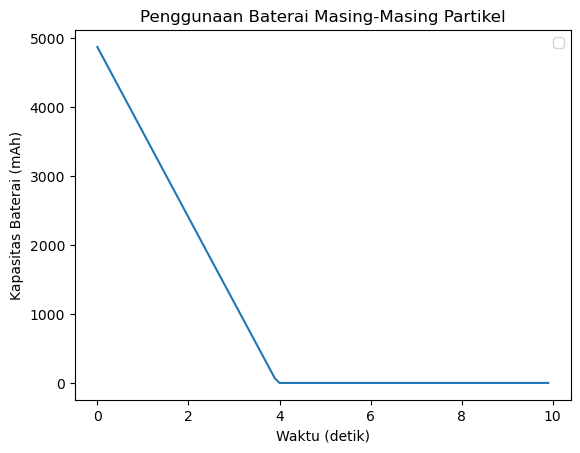

No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.


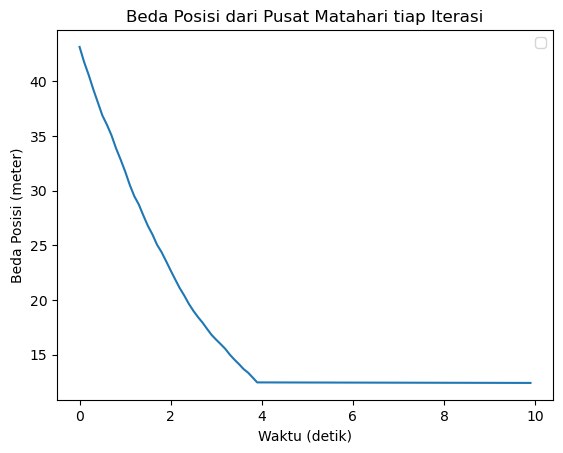

Posisi global terbaik: [61.81794235 65.03409852]
Kapasitas baterai akhir dan persentasenya: 
Drone 1: Kapasitas baterai = 0.002777767397329623 mAh (5.5555347946592456e-05%)
Drone 2: Kapasitas baterai = 0.0027768858867951588 mAh (5.5537717735903175e-05%)
Drone 3: Kapasitas baterai = 0.002777633147484863 mAh (5.555266294969726e-05%)
Drone 4: Kapasitas baterai = 0.002777768101015603 mAh (5.5555362020312056e-05%)
Drone 5: Kapasitas baterai = 0.002777696383674543 mAh (5.555392767349086e-05%)
Drone 6: Kapasitas baterai = 0.00277743855331576 mAh (5.5548771066315205e-05%)
Drone 7: Kapasitas baterai = 0.002777276761145833 mAh (5.5545535222916664e-05%)
Drone 8: Kapasitas baterai = 0.002777384166319939 mAh (5.554768332639878e-05%)
Drone 9: Kapasitas baterai = 0.0027777556566533196 mAh (5.55551131330664e-05%)
Drone 10: Kapasitas baterai = 0.0027774000498134964 mAh (5.5548000996269925e-05%)
Drone 11: Kapasitas baterai = 0.002777574848262791 mAh (5.555149696525582e-05%)
Drone 12: Kapasitas baterai =

In [40]:
import os
import numpy as np
import matplotlib.pyplot as plt

def gauss_sun_intensity(x, y, sun_center, sun_std_dev):
    """Intensitas Gaussian berdasarkan jarak dari titik tengah."""
    return np.exp(-((x - sun_center[0])**2 + (y - sun_center[1])**2) / (2 * sun_std_dev**2))

def fitness_function(pos, sun_center, sun_std_dev, particles, index, min_distance, repulsion_factor):
    """Fitness function untuk memaksimalkan intensitas cahaya dan meminimalkan repulsi."""
    sun_intensity = gauss_sun_intensity(pos[0], pos[1], sun_center, sun_std_dev)

    repulsion = 0
    for j in range(len(particles)):
        if j != index:
            distance = np.linalg.norm(pos - particles[j])
            if distance < min_distance:
                repulsion += repulsion_factor / distance**2

    fitness = -sun_intensity + repulsion
    return fitness

def calculate_energy_consumption(mass, altitude, horizontal_distance, battery_voltage):
    """Menghitung parameter energi dari setiap drone."""
    drag_coefficient = 0.5
    frontal_area = 0.1  
    air_density = 1.225  
    horizontal_speed = 10.0  
    flight_efficiency = 0.8

    E_vertical_J = mass * 9.81 * altitude
    P_drag = 0.5 * drag_coefficient * frontal_area * air_density * horizontal_speed**2
    P_horizontal = (P_drag + mass * 9.81 * horizontal_speed) / flight_efficiency
    E_horizontal_J = P_horizontal * (horizontal_distance / horizontal_speed)
    E_total_J = E_vertical_J + E_horizontal_J
    E_total_Wh = E_total_J / 3600
    energy_consumed = (E_total_Wh * 1000) / battery_voltage
    return energy_consumed

def pso_drone_solar_chaser_with_battery():
    num_particles = 30
    num_iterations = 100
    dim = 2  
    c1 = 1.0
    c2 = 1.5  
    w = 0.1  
    timestep = 0.1  # seconds
    L = 125  # meters

    drone_mass = 2.5 # massa baterai + massa panel surya (massa baterai yang dipakai yaitu variasi 7 kg dan massa panel surya variasi 5, 15, 30 ) 
    battery_capacity = 5000  
    solar_charge_rate = 100  
    altitude = 200  
    battery_voltage = 11.1  

    sun_center = np.array([L / 2, L / 2])  
    sun_std_dev = 1000  
    sun_speed = 1000 / 28800  # 1 km per 8 jam dalam meters per second

    min_distance = 3  
    repulsion_factor = 1000  

    particles = np.random.rand(num_particles, dim) * L  
    velocities = np.zeros((num_particles, dim))  
    personal_best_positions = particles.copy()
    global_best_position = particles[0, :].copy()
    global_best_fitness = float('inf')

    battery_levels = battery_capacity * np.ones(num_particles)  

    battery_levels_over_time = np.zeros((num_iterations, num_particles))
    position_diff_over_time = np.zeros((num_iterations, num_particles))

    # Folder untuk menyimpan hasil program
    folder_name = "Percobaan_513"
    if not os.path.exists(folder_name):
        os.makedirs(folder_name)

    for iter in range(num_iterations):
        for i in range(num_particles):
            fitness = fitness_function(particles[i, :], sun_center, sun_std_dev, particles, i, min_distance, repulsion_factor)
            if fitness < fitness_function(personal_best_positions[i, :], sun_center, sun_std_dev, particles, i, min_distance, repulsion_factor):
                personal_best_positions[i, :] = particles[i, :]
            if fitness < global_best_fitness:
                global_best_fitness = fitness
                global_best_position = particles[i, :]

        for i in range(num_particles):
            velocities[i, :] = (w * velocities[i, :] +
                                c1 * np.random.rand() * (personal_best_positions[i, :] - particles[i, :]) +
                                c2 * np.random.rand() * (global_best_position - particles[i, :]) / drone_mass * timestep)
            new_position = particles[i, :] + velocities[i, :]  
            new_position = np.clip(new_position, 0, L)
            horizontal_distance = np.linalg.norm(new_position - particles[i, :])
            energy_consumed = calculate_energy_consumption(drone_mass, altitude, horizontal_distance, battery_voltage)
            battery_levels[i] -= energy_consumed
            if battery_levels[i] > 0:
                particles[i, :] = new_position
            else:
                battery_levels[i] = 0

        for i in range(num_particles):
            solar_energy = (solar_charge_rate * 
                            max(0, gauss_sun_intensity(particles[i, 0], particles[i, 1], sun_center, sun_std_dev)) * 
                            timestep / 3600)
            battery_levels[i] = min(battery_levels[i] + solar_energy, battery_capacity)

        battery_levels_over_time[iter, :] = battery_levels
        position_diff_over_time[iter, :] = np.linalg.norm(particles - sun_center, axis=1)

        sun_center[0] += sun_speed * timestep  

        if sun_center[0] > L:
            sun_center[0] = 0

        X, Y = np.meshgrid(np.arange(0, L+1, 10), np.arange(0, L+1, 10))  
        Z = np.array([[gauss_sun_intensity(x, y, sun_center, sun_std_dev) for x in np.arange(0, L+1, 10)] for y in np.arange(0, L+1, 10)])
        
        plt.contourf(X, Y, Z)  
        plt.colorbar()
        plt.clim(0, 1)
        plt.title('Distribusi Matahari')
        plt.plot(particles[:, 0], particles[:, 1], '.r')
        plt.savefig(f'{folder_name}/frame_{iter+1}.png')  
        plt.clf()

        print(f'Iterasi ke-{iter + 1}: Global Best Fitness = {global_best_fitness}')

    time = np.arange(num_iterations) * timestep 
    
    plt.figure()
    for i in range(num_particles):
        plt.plot(time, battery_levels_over_time[:, i], label=f'Particle {i+1}')
    plt.title('Penggunaan Baterai Masing-Masing Partikel')
    plt.xlabel('Waktu (detik)')
    plt.ylabel('Kapasitas Baterai (mAh)')
    plt.legend(loc='best')
    plt.savefig(f'{folder_name}/Kapasitas Baterai Tiap Waktu.png')  
    plt.show()
    
    plt.figure()
    for i in range(num_particles):
        plt.plot(time, position_diff_over_time[:, i], label=f'Particle {i+1}')
    plt.title('Beda Posisi dari Pusat Matahari tiap Waktu')
    plt.xlabel('Waktu (detik)')
    plt.ylabel('Beda Posisi (meter)')
    plt.legend(loc='best')
    plt.savefig(f'{folder_name}/beda_posisi tiap waktu.png')  
    plt.show()

    print(f'Posisi global terbaik: {global_best_position}')
    print('Kapasitas baterai akhir dan persentasenya: ')
    for i in range(num_particles):
        battery_percentage = (battery_levels[i] / battery_capacity) * 100
        print(f'Drone {i + 1}: Kapasitas baterai = {battery_levels[i]} mAh ({battery_percentage}%)')

if __name__ == "__main__":
    pso_drone_solar_chaser_with_battery()


Iterasi ke-1: Global Best Fitness = -0.9995503704581523
Iterasi ke-2: Global Best Fitness = -0.999550383050936
Iterasi ke-3: Global Best Fitness = -0.9995503956316689
Iterasi ke-4: Global Best Fitness = -0.9995504082003511
Iterasi ke-5: Global Best Fitness = -0.9995504207569826
Iterasi ke-6: Global Best Fitness = -0.9995504333015633
Iterasi ke-7: Global Best Fitness = -0.9995504458340932
Iterasi ke-8: Global Best Fitness = -0.9995504583545725
Iterasi ke-9: Global Best Fitness = -0.9995504708630009
Iterasi ke-10: Global Best Fitness = -0.9995504833593786
Iterasi ke-11: Global Best Fitness = -0.9995504958437055
Iterasi ke-12: Global Best Fitness = -0.9995505083159817
Iterasi ke-13: Global Best Fitness = -0.9995505207762071
Iterasi ke-14: Global Best Fitness = -0.9995505332243818
Iterasi ke-15: Global Best Fitness = -0.9995505456605057
Iterasi ke-16: Global Best Fitness = -0.9995505580845789
Iterasi ke-17: Global Best Fitness = -0.9995505704966013
Iterasi ke-18: Global Best Fitness = -0.9

<Figure size 640x480 with 0 Axes>

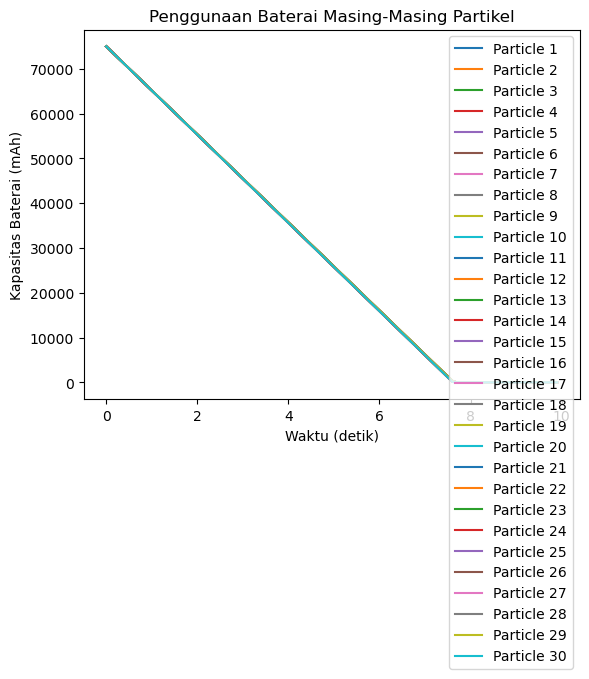

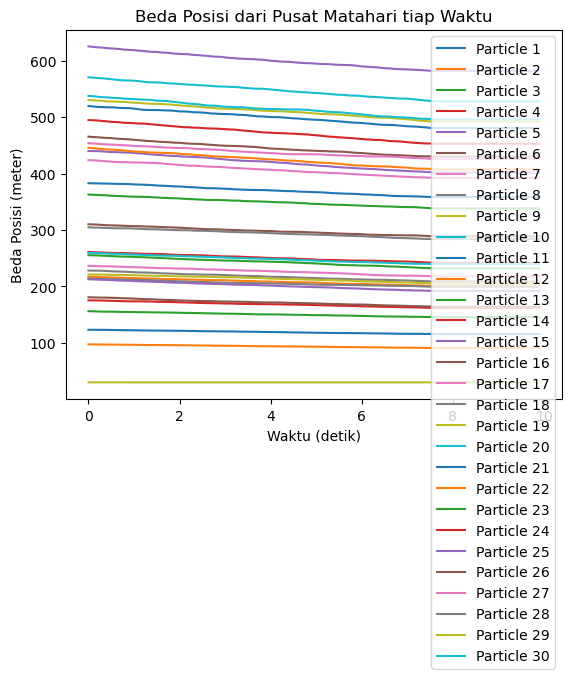

Posisi global terbaik: [503.63008921 529.77051836]
Kapasitas baterai akhir dan persentasenya: 
Drone 1: Kapasitas baterai = 0.0024747273612839536 mAh (3.2562202122157286e-06%)
Drone 2: Kapasitas baterai = 0.002766332009348124 mAh (3.6399105386159526e-06%)
Drone 3: Kapasitas baterai = 0.0027484506505174827 mAh (3.616382434891425e-06%)
Drone 4: Kapasitas baterai = 0.0027415710094047066 mAh (3.6073302755325084e-06%)
Drone 5: Kapasitas baterai = 0.0025623788039601824 mAh (3.3715510578423453e-06%)
Drone 6: Kapasitas baterai = 0.0027406288404652653 mAh (3.6060905795595596e-06%)
Drone 7: Kapasitas baterai = 0.002712651101361246 mAh (3.569277764949008e-06%)
Drone 8: Kapasitas baterai = 0.0027177960408617595 mAh (3.5760474221865256e-06%)
Drone 9: Kapasitas baterai = 0.0024610128539307454 mAh (3.2381748078036123e-06%)
Drone 10: Kapasitas baterai = 0.002456142767456435 mAh (3.2317667992847823e-06%)
Drone 11: Kapasitas baterai = 0.002759303514679942 mAh (3.6306625193157132e-06%)
Drone 12: Kapasita

In [7]:
import os
import numpy as np
import matplotlib.pyplot as plt

def gauss_sun_intensity(x, y, sun_center, sun_std_dev):
    """Intensitas Gaussian berdasarkan jarak dari titik tengah."""
    return np.exp(-((x - sun_center[0])**2 + (y - sun_center[1])**2) / (2 * sun_std_dev**2))

def fitness_function(pos, sun_center, sun_std_dev, particles, index, min_distance, repulsion_factor):
    """Fitness function untuk memaksimalkan intensitas cahaya dan meminimalkan repulsi."""
    sun_intensity = gauss_sun_intensity(pos[0], pos[1], sun_center, sun_std_dev)

    repulsion = 0
    for j in range(len(particles)):
        if j != index:
            distance = np.linalg.norm(pos - particles[j])
            if distance < min_distance:
                repulsion += repulsion_factor / distance**2

    fitness = -sun_intensity + repulsion
    return fitness

def calculate_energy_consumption(mass, altitude, horizontal_distance, battery_voltage):
    """Menghitung parameter energi dari setiap drone."""
    drag_coefficient = 0.5
    frontal_area = 0.1  
    air_density = 1.225  
    horizontal_speed = 10.0  
    flight_efficiency = 0.8

    E_vertical_J = mass * 9.81 * altitude
    P_drag = 0.5 * drag_coefficient * frontal_area * air_density * horizontal_speed**2
    P_horizontal = (P_drag + mass * 9.81 * horizontal_speed) / flight_efficiency
    E_horizontal_J = P_horizontal * (horizontal_distance / horizontal_speed)
    E_total_J = E_vertical_J + E_horizontal_J
    E_total_Wh = E_total_J / 3600
    energy_consumed = (E_total_Wh * 1000) / battery_voltage
    return energy_consumed

def pso_drone_solar_chaser_with_battery():
    num_particles = 30
    num_iterations = 100
    dim = 2  
    c1 = 1.0
    c2 = 1.5  
    w = 0.1  
    timestep = 0.1  # seconds
    L = 1000  # meters

    drone_mass = 80.0 # massa baterai + massa panel surya (massa baterai yang dipakai yaitu variasi 7 kg dan massa panel surya variasi 5, 15, 30 ) 
    battery_capacity = 2*38000
    solar_charge_rate = 100  
    altitude = 200  
    battery_voltage = 44.4 

    sun_center = np.array([L / 2, L / 2])  
    sun_std_dev = 1000  
    sun_speed = 1000 / 28800  # 1 km per 8 jam dalam meters per second

    min_distance = 3  
    repulsion_factor = 1000  

    particles = np.random.rand(num_particles, dim) * L  
    velocities = np.zeros((num_particles, dim))  
    personal_best_positions = particles.copy()
    global_best_position = particles[0, :].copy()
    global_best_fitness = float('inf')

    battery_levels = battery_capacity * np.ones(num_particles)  

    battery_levels_over_time = np.zeros((num_iterations, num_particles))
    position_diff_over_time = np.zeros((num_iterations, num_particles))

    # Folder untuk menyimpan hasil program
    folder_name = "Percobaan_dji flycart 30"
    if not os.path.exists(folder_name):
        os.makedirs(folder_name)

    for iter in range(num_iterations):
        for i in range(num_particles):
            fitness = fitness_function(particles[i, :], sun_center, sun_std_dev, particles, i, min_distance, repulsion_factor)
            if fitness < fitness_function(personal_best_positions[i, :], sun_center, sun_std_dev, particles, i, min_distance, repulsion_factor):
                personal_best_positions[i, :] = particles[i, :]
            if fitness < global_best_fitness:
                global_best_fitness = fitness
                global_best_position = particles[i, :]

        for i in range(num_particles):
            velocities[i, :] = (w * velocities[i, :] +
                                c1 * np.random.rand() * (personal_best_positions[i, :] - particles[i, :]) +
                                c2 * np.random.rand() * (global_best_position - particles[i, :]) / drone_mass * timestep)
            new_position = particles[i, :] + velocities[i, :]  
            new_position = np.clip(new_position, 0, L)
            horizontal_distance = np.linalg.norm(new_position - particles[i, :])
            energy_consumed = calculate_energy_consumption(drone_mass, altitude, horizontal_distance, battery_voltage)
            battery_levels[i] -= energy_consumed
            if battery_levels[i] > 0:
                particles[i, :] = new_position
            else:
                battery_levels[i] = 0

        for i in range(num_particles):
            solar_energy = (solar_charge_rate * 
                            max(0, gauss_sun_intensity(particles[i, 0], particles[i, 1], sun_center, sun_std_dev)) * 
                            timestep / 3600)
            battery_levels[i] = min(battery_levels[i] + solar_energy, battery_capacity)

        battery_levels_over_time[iter, :] = battery_levels
        position_diff_over_time[iter, :] = np.linalg.norm(particles - sun_center, axis=1)

        sun_center[0] += sun_speed * timestep  

        if sun_center[0] > L:
            sun_center[0] = 0

        X, Y = np.meshgrid(np.arange(0, L+1, 10), np.arange(0, L+1, 10))  
        Z = np.array([[gauss_sun_intensity(x, y, sun_center, sun_std_dev) for x in np.arange(0, L+1, 10)] for y in np.arange(0, L+1, 10)])
        
        plt.contourf(X, Y, Z)  
        plt.colorbar()
        plt.clim(0, 1)
        plt.title('Distribusi Matahari')
        plt.plot(particles[:, 0], particles[:, 1], '.r')
        plt.savefig(f'{folder_name}/frame_{iter+1}.png')  
        plt.clf()

        print(f'Iterasi ke-{iter + 1}: Global Best Fitness = {global_best_fitness}')

    time = np.arange(num_iterations) * timestep 
    
    plt.figure()
    for i in range(num_particles):
        plt.plot(time, battery_levels_over_time[:, i], label=f'Particle {i+1}')
    plt.title('Penggunaan Baterai Masing-Masing Partikel')
    plt.xlabel('Waktu (detik)')
    plt.ylabel('Kapasitas Baterai (mAh)')
    plt.legend(loc='best')
    plt.savefig(f'{folder_name}/Kapasitas Baterai Tiap Waktu.png')  
    plt.show()
    
    plt.figure()
    for i in range(num_particles):
        plt.plot(time, position_diff_over_time[:, i], label=f'Particle {i+1}')
    plt.title('Beda Posisi dari Pusat Matahari tiap Waktu')
    plt.xlabel('Waktu (detik)')
    plt.ylabel('Beda Posisi (meter)')
    plt.legend(loc='best')
    plt.savefig(f'{folder_name}/beda_posisi tiap waktu.png')  
    plt.show()


    print(f'Posisi global terbaik: {global_best_position}')
    print('Kapasitas baterai akhir dan persentasenya: ')
    for i in range(num_particles):
        battery_percentage = (battery_levels[i] / battery_capacity) * 100
        print(f'Drone {i + 1}: Kapasitas baterai = {battery_levels[i]} mAh ({battery_percentage}%)')

if __name__ == "__main__":
    pso_drone_solar_chaser_with_battery()


Iterasi ke-1: Global Best Fitness = -0.9919691870191137
Iterasi ke-2: Global Best Fitness = -0.9919691870191137
Iterasi ke-3: Global Best Fitness = -0.9919691870191137
Iterasi ke-4: Global Best Fitness = -0.9919691870191137
Iterasi ke-5: Global Best Fitness = -0.9919691870191137
Iterasi ke-6: Global Best Fitness = -0.9919691870191137
Iterasi ke-7: Global Best Fitness = -0.9919691870191137
Iterasi ke-8: Global Best Fitness = -0.9919691870191137
Iterasi ke-9: Global Best Fitness = -0.9919691870191137
Iterasi ke-10: Global Best Fitness = -0.9919691870191137
Iterasi ke-11: Global Best Fitness = -0.9919691870191137
Iterasi ke-12: Global Best Fitness = -0.9919691870191137
Iterasi ke-13: Global Best Fitness = -0.9919691870191137
Iterasi ke-14: Global Best Fitness = -0.9919691870191137
Iterasi ke-15: Global Best Fitness = -0.9919691870191137
Iterasi ke-16: Global Best Fitness = -0.9919691870191137
Iterasi ke-17: Global Best Fitness = -0.9919691870191137
Iterasi ke-18: Global Best Fitness = -0.

<Figure size 640x480 with 0 Axes>

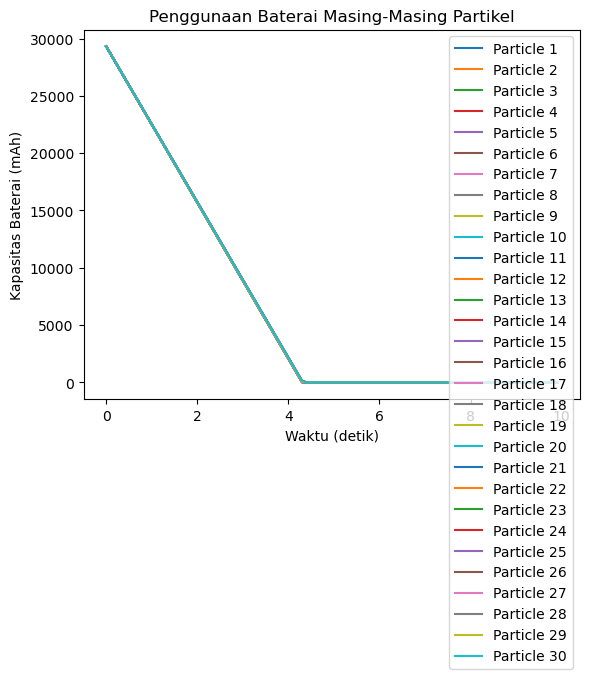

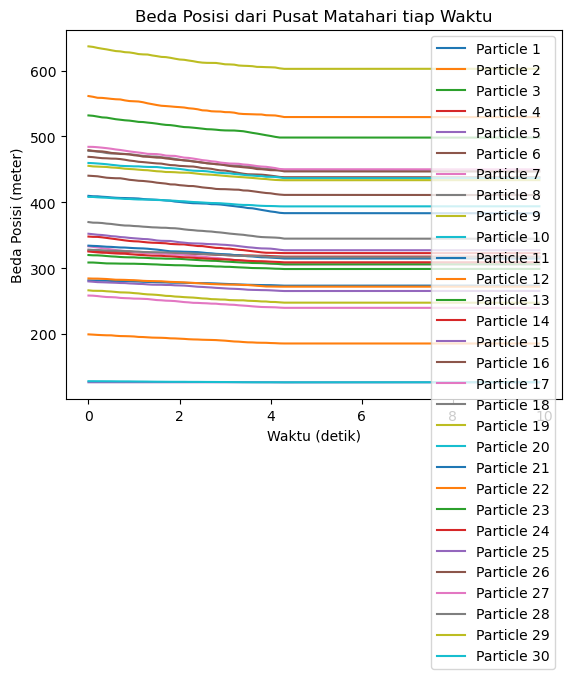

Posisi global terbaik: [392.58707989 567.23662858]
Kapasitas baterai akhir dan persentasenya: 
Drone 1: Kapasitas baterai = 0.0026756129822774494 mAh (8.918709940924831e-06%)
Drone 2: Kapasitas baterai = 0.0024146474325022274 mAh (8.048824775007424e-06%)
Drone 3: Kapasitas baterai = 0.0026563469293939966 mAh (8.854489764646655e-06%)
Drone 4: Kapasitas baterai = 0.0026409934683403716 mAh (8.803311561134573e-06%)
Drone 5: Kapasitas baterai = 0.002755461977402353 mAh (9.184873258007844e-06%)
Drone 6: Kapasitas baterai = 0.00252361906744234 mAh (8.412063558141133e-06%)
Drone 7: Kapasitas baterai = 0.0026989842685028525 mAh (8.996614228342842e-06%)
Drone 8: Kapasitas baterai = 0.0025124649007875633 mAh (8.374883002625211e-06%)
Drone 9: Kapasitas baterai = 0.002316455754063414 mAh (7.72151918021138e-06%)
Drone 10: Kapasitas baterai = 0.0025252454715835528 mAh (8.417484905278509e-06%)
Drone 11: Kapasitas baterai = 0.002580917968654454 mAh (8.603059895514847e-06%)
Drone 12: Kapasitas baterai =

In [8]:
import os
import numpy as np
import matplotlib.pyplot as plt

def gauss_sun_intensity(x, y, sun_center, sun_std_dev):
    """Intensitas Gaussian berdasarkan jarak dari titik tengah."""
    return np.exp(-((x - sun_center[0])**2 + (y - sun_center[1])**2) / (2 * sun_std_dev**2))

def fitness_function(pos, sun_center, sun_std_dev, particles, index, min_distance, repulsion_factor):
    """Fitness function untuk memaksimalkan intensitas cahaya dan meminimalkan repulsi."""
    sun_intensity = gauss_sun_intensity(pos[0], pos[1], sun_center, sun_std_dev)

    repulsion = 0
    for j in range(len(particles)):
        if j != index:
            distance = np.linalg.norm(pos - particles[j])
            if distance < min_distance:
                repulsion += repulsion_factor / distance**2

    fitness = -sun_intensity + repulsion
    return fitness

def calculate_energy_consumption(mass, altitude, horizontal_distance, battery_voltage):
    """Menghitung parameter energi dari setiap drone."""
    drag_coefficient = 0.5
    frontal_area = 0.1  
    air_density = 1.225  
    horizontal_speed = 10.0  
    flight_efficiency = 0.8

    E_vertical_J = mass * 9.81 * altitude
    P_drag = 0.5 * drag_coefficient * frontal_area * air_density * horizontal_speed**2
    P_horizontal = (P_drag + mass * 9.81 * horizontal_speed) / flight_efficiency
    E_horizontal_J = P_horizontal * (horizontal_distance / horizontal_speed)
    E_total_J = E_vertical_J + E_horizontal_J
    E_total_Wh = E_total_J / 3600
    energy_consumed = (E_total_Wh * 1000) / battery_voltage
    return energy_consumed

def pso_drone_solar_chaser_with_battery():
    num_particles = 30
    num_iterations = 100
    dim = 2  
    c1 = 1.0
    c2 = 1.5  
    w = 0.1  
    timestep = 0.1  # seconds
    L = 1000  # meters

    drone_mass = 65.0 # massa baterai + massa panel surya (massa baterai yang dipakai yaitu variasi 7 kg dan massa panel surya variasi 5, 15, 30 ) 
    battery_capacity = 30000
    solar_charge_rate = 100  
    altitude = 200  
    battery_voltage = 52.22

    sun_center = np.array([L / 2, L / 2])  
    sun_std_dev = 1000  
    sun_speed = 1000 / 28800  # 1 km per 8 jam dalam meters per second

    min_distance = 3  
    repulsion_factor = 1000  

    particles = np.random.rand(num_particles, dim) * L  
    velocities = np.zeros((num_particles, dim))  
    personal_best_positions = particles.copy()
    global_best_position = particles[0, :].copy()
    global_best_fitness = float('inf')

    battery_levels = battery_capacity * np.ones(num_particles)  

    battery_levels_over_time = np.zeros((num_iterations, num_particles))
    position_diff_over_time = np.zeros((num_iterations, num_particles))

    # Folder untuk menyimpan hasil program
    folder_name = "Percobaan_dji agras t40"
    if not os.path.exists(folder_name):
        os.makedirs(folder_name)

    for iter in range(num_iterations):
        for i in range(num_particles):
            fitness = fitness_function(particles[i, :], sun_center, sun_std_dev, particles, i, min_distance, repulsion_factor)
            if fitness < fitness_function(personal_best_positions[i, :], sun_center, sun_std_dev, particles, i, min_distance, repulsion_factor):
                personal_best_positions[i, :] = particles[i, :]
            if fitness < global_best_fitness:
                global_best_fitness = fitness
                global_best_position = particles[i, :]

        for i in range(num_particles):
            velocities[i, :] = (w * velocities[i, :] +
                                c1 * np.random.rand() * (personal_best_positions[i, :] - particles[i, :]) +
                                c2 * np.random.rand() * (global_best_position - particles[i, :]) / drone_mass * timestep)
            new_position = particles[i, :] + velocities[i, :]  
            new_position = np.clip(new_position, 0, L)
            horizontal_distance = np.linalg.norm(new_position - particles[i, :])
            energy_consumed = calculate_energy_consumption(drone_mass, altitude, horizontal_distance, battery_voltage)
            battery_levels[i] -= energy_consumed
            if battery_levels[i] > 0:
                particles[i, :] = new_position
            else:
                battery_levels[i] = 0

        for i in range(num_particles):
            solar_energy = (solar_charge_rate * 
                            max(0, gauss_sun_intensity(particles[i, 0], particles[i, 1], sun_center, sun_std_dev)) * 
                            timestep / 3600)
            battery_levels[i] = min(battery_levels[i] + solar_energy, battery_capacity)

        battery_levels_over_time[iter, :] = battery_levels
        position_diff_over_time[iter, :] = np.linalg.norm(particles - sun_center, axis=1)

        sun_center[0] += sun_speed * timestep  

        if sun_center[0] > L:
            sun_center[0] = 0

        X, Y = np.meshgrid(np.arange(0, L+1, 10), np.arange(0, L+1, 10))  
        Z = np.array([[gauss_sun_intensity(x, y, sun_center, sun_std_dev) for x in np.arange(0, L+1, 10)] for y in np.arange(0, L+1, 10)])
        
        plt.contourf(X, Y, Z)  
        plt.colorbar()
        plt.clim(0, 1)
        plt.title('Distribusi Matahari')
        plt.plot(particles[:, 0], particles[:, 1], '.r')
        plt.savefig(f'{folder_name}/frame_{iter+1}.png')  
        plt.clf()

        print(f'Iterasi ke-{iter + 1}: Global Best Fitness = {global_best_fitness}')

    time = np.arange(num_iterations) * timestep 
    
    plt.figure()
    for i in range(num_particles):
        plt.plot(time, battery_levels_over_time[:, i], label=f'Particle {i+1}')
    plt.title('Penggunaan Baterai Masing-Masing Partikel')
    plt.xlabel('Waktu (detik)')
    plt.ylabel('Kapasitas Baterai (mAh)')
    plt.legend(loc='best')
    plt.savefig(f'{folder_name}/Kapasitas Baterai Tiap Waktu.png')  
    plt.show()
    
    plt.figure()
    for i in range(num_particles):
        plt.plot(time, position_diff_over_time[:, i], label=f'Particle {i+1}')
    plt.title('Beda Posisi dari Pusat Matahari tiap Waktu')
    plt.xlabel('Waktu (detik)')
    plt.ylabel('Beda Posisi (meter)')
    plt.legend(loc='best')
    plt.savefig(f'{folder_name}/beda_posisi tiap waktu.png')  
    plt.show()


    print(f'Posisi global terbaik: {global_best_position}')
    print('Kapasitas baterai akhir dan persentasenya: ')
    for i in range(num_particles):
        battery_percentage = (battery_levels[i] / battery_capacity) * 100
        print(f'Drone {i + 1}: Kapasitas baterai = {battery_levels[i]} mAh ({battery_percentage}%)')

if __name__ == "__main__":
    pso_drone_solar_chaser_with_battery()


Iterasi ke-1: Global Best Fitness = -0.9975966091070921
Iterasi ke-2: Global Best Fitness = -0.9975966091070921
Iterasi ke-3: Global Best Fitness = -0.9975966091070921
Iterasi ke-4: Global Best Fitness = -0.9975966091070921
Iterasi ke-5: Global Best Fitness = -0.9975966091070921
Iterasi ke-6: Global Best Fitness = -0.9975966091070921
Iterasi ke-7: Global Best Fitness = -0.9975966091070921
Iterasi ke-8: Global Best Fitness = -0.9975966091070921
Iterasi ke-9: Global Best Fitness = -0.9975966091070921
Iterasi ke-10: Global Best Fitness = -0.9975966091070921
Iterasi ke-11: Global Best Fitness = -0.9975966091070921
Iterasi ke-12: Global Best Fitness = -0.9975966091070921
Iterasi ke-13: Global Best Fitness = -0.9975966091070921
Iterasi ke-14: Global Best Fitness = -0.9975966091070921
Iterasi ke-15: Global Best Fitness = -0.9975966091070921
Iterasi ke-16: Global Best Fitness = -0.9975966091070921
Iterasi ke-17: Global Best Fitness = -0.9975966091070921
Iterasi ke-18: Global Best Fitness = -0.

<Figure size 640x480 with 0 Axes>

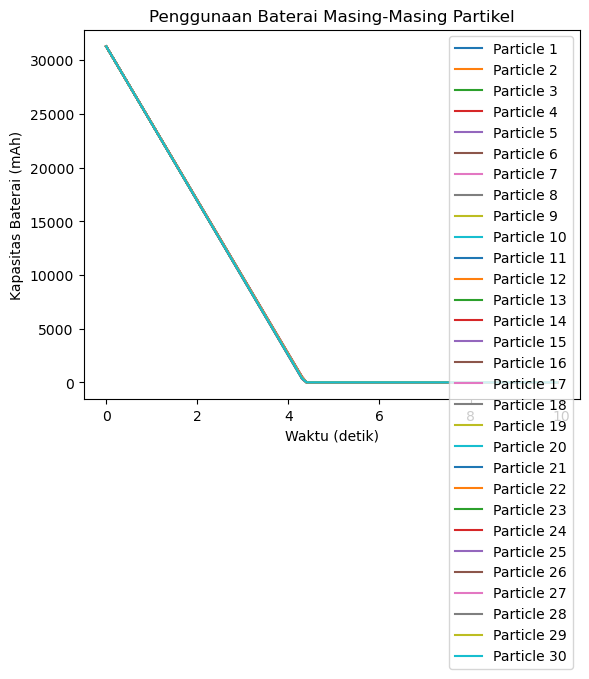

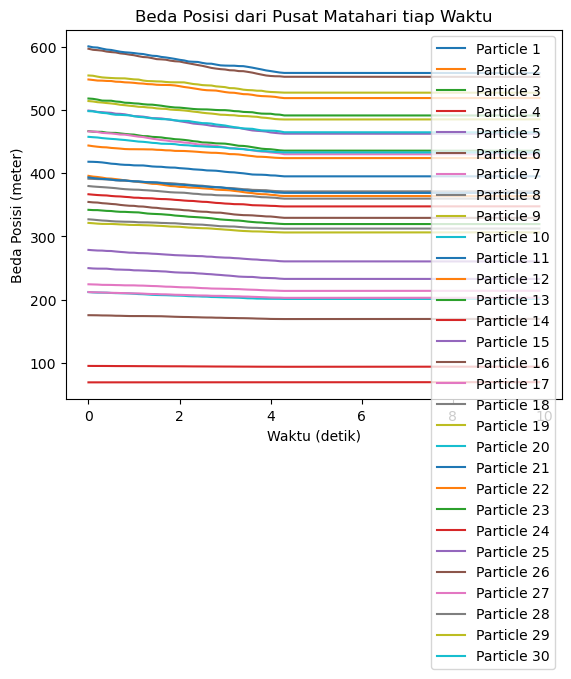

Posisi global terbaik: [431.8836481  486.85732334]
Kapasitas baterai akhir dan persentasenya: 
Drone 1: Kapasitas baterai = 0.0025692479064244106 mAh (8.028899707576283e-06%)
Drone 2: Kapasitas baterai = 0.002599922003547579 mAh (8.124756261086185e-06%)
Drone 3: Kapasitas baterai = 0.0025263988660775005 mAh (7.894996456492188e-06%)
Drone 4: Kapasitas baterai = 0.0026149218755082333 mAh (8.17163086096323e-06%)
Drone 5: Kapasitas baterai = 0.0026851094995225654 mAh (8.390967186008016e-06%)
Drone 6: Kapasitas baterai = 0.0023848663151911703 mAh (7.452707234972408e-06%)
Drone 7: Kapasitas baterai = 0.0027148409670845848 mAh (8.483878022139327e-06%)
Drone 8: Kapasitas baterai = 0.002645360738316808 mAh (8.266752307240026e-06%)
Drone 9: Kapasitas baterai = 0.0024694692540978115 mAh (7.71709141905566e-06%)
Drone 10: Kapasitas baterai = 0.0027220894199853156 mAh (8.506529437454111e-06%)
Drone 11: Kapasitas baterai = 0.002376847504110942 mAh (7.427648450346694e-06%)
Drone 12: Kapasitas baterai 

In [9]:
import os
import numpy as np
import matplotlib.pyplot as plt

def gauss_sun_intensity(x, y, sun_center, sun_std_dev):
    """Intensitas Gaussian berdasarkan jarak dari titik tengah."""
    return np.exp(-((x - sun_center[0])**2 + (y - sun_center[1])**2) / (2 * sun_std_dev**2))

def fitness_function(pos, sun_center, sun_std_dev, particles, index, min_distance, repulsion_factor):
    """Fitness function untuk memaksimalkan intensitas cahaya dan meminimalkan repulsi."""
    sun_intensity = gauss_sun_intensity(pos[0], pos[1], sun_center, sun_std_dev)

    repulsion = 0
    for j in range(len(particles)):
        if j != index:
            distance = np.linalg.norm(pos - particles[j])
            if distance < min_distance:
                repulsion += repulsion_factor / distance**2

    fitness = -sun_intensity + repulsion
    return fitness

def calculate_energy_consumption(mass, altitude, horizontal_distance, battery_voltage):
    """Menghitung parameter energi dari setiap drone."""
    drag_coefficient = 0.5
    frontal_area = 0.1  
    air_density = 1.225  
    horizontal_speed = 10.0  
    flight_efficiency = 0.8

    E_vertical_J = mass * 9.81 * altitude
    P_drag = 0.5 * drag_coefficient * frontal_area * air_density * horizontal_speed**2
    P_horizontal = (P_drag + mass * 9.81 * horizontal_speed) / flight_efficiency
    E_horizontal_J = P_horizontal * (horizontal_distance / horizontal_speed)
    E_total_J = E_vertical_J + E_horizontal_J
    E_total_Wh = E_total_J / 3600
    energy_consumed = (E_total_Wh * 1000) / battery_voltage
    return energy_consumed

def pso_drone_solar_chaser_with_battery():
    num_particles = 30
    num_iterations = 100
    dim = 2  
    c1 = 1.0
    c2 = 1.5  
    w = 0.1  
    timestep = 0.1  # seconds
    L = 1000  # meters

    drone_mass = 58.28 # massa baterai + massa panel surya (massa baterai yang dipakai yaitu variasi 7 kg dan massa panel surya variasi 5, 15, 30 ) 
    battery_capacity = 2*16000
    solar_charge_rate = 100  
    altitude = 200  
    battery_voltage = 44.4

    sun_center = np.array([L / 2, L / 2])  
    sun_std_dev = 1000  
    sun_speed = 1000 / 28800  # 1 km per 8 jam dalam meters per second

    min_distance = 3  
    repulsion_factor = 1000  

    particles = np.random.rand(num_particles, dim) * L  
    velocities = np.zeros((num_particles, dim))  
    personal_best_positions = particles.copy()
    global_best_position = particles[0, :].copy()
    global_best_fitness = float('inf')

    battery_levels = battery_capacity * np.ones(num_particles)  

    battery_levels_over_time = np.zeros((num_iterations, num_particles))
    position_diff_over_time = np.zeros((num_iterations, num_particles))

    # Folder untuk menyimpan hasil program
    folder_name = "Percobaan_free fly alta x"
    if not os.path.exists(folder_name):
        os.makedirs(folder_name)

    for iter in range(num_iterations):
        for i in range(num_particles):
            fitness = fitness_function(particles[i, :], sun_center, sun_std_dev, particles, i, min_distance, repulsion_factor)
            if fitness < fitness_function(personal_best_positions[i, :], sun_center, sun_std_dev, particles, i, min_distance, repulsion_factor):
                personal_best_positions[i, :] = particles[i, :]
            if fitness < global_best_fitness:
                global_best_fitness = fitness
                global_best_position = particles[i, :]

        for i in range(num_particles):
            velocities[i, :] = (w * velocities[i, :] +
                                c1 * np.random.rand() * (personal_best_positions[i, :] - particles[i, :]) +
                                c2 * np.random.rand() * (global_best_position - particles[i, :]) / drone_mass * timestep)
            new_position = particles[i, :] + velocities[i, :]  
            new_position = np.clip(new_position, 0, L)
            horizontal_distance = np.linalg.norm(new_position - particles[i, :])
            energy_consumed = calculate_energy_consumption(drone_mass, altitude, horizontal_distance, battery_voltage)
            battery_levels[i] -= energy_consumed
            if battery_levels[i] > 0:
                particles[i, :] = new_position
            else:
                battery_levels[i] = 0

        for i in range(num_particles):
            solar_energy = (solar_charge_rate * 
                            max(0, gauss_sun_intensity(particles[i, 0], particles[i, 1], sun_center, sun_std_dev)) * 
                            timestep / 3600)
            battery_levels[i] = min(battery_levels[i] + solar_energy, battery_capacity)

        battery_levels_over_time[iter, :] = battery_levels
        position_diff_over_time[iter, :] = np.linalg.norm(particles - sun_center, axis=1)

        sun_center[0] += sun_speed * timestep  

        if sun_center[0] > L:
            sun_center[0] = 0

        X, Y = np.meshgrid(np.arange(0, L+1, 10), np.arange(0, L+1, 10))  
        Z = np.array([[gauss_sun_intensity(x, y, sun_center, sun_std_dev) for x in np.arange(0, L+1, 10)] for y in np.arange(0, L+1, 10)])
        
        plt.contourf(X, Y, Z)  
        plt.colorbar()
        plt.clim(0, 1)
        plt.title('Distribusi Matahari')
        plt.plot(particles[:, 0], particles[:, 1], '.r')
        plt.savefig(f'{folder_name}/frame_{iter+1}.png')  
        plt.clf()

        print(f'Iterasi ke-{iter + 1}: Global Best Fitness = {global_best_fitness}')

    time = np.arange(num_iterations) * timestep 
    
    plt.figure()
    for i in range(num_particles):
        plt.plot(time, battery_levels_over_time[:, i], label=f'Particle {i+1}')
    plt.title('Penggunaan Baterai Masing-Masing Partikel')
    plt.xlabel('Waktu (detik)')
    plt.ylabel('Kapasitas Baterai (mAh)')
    plt.legend(loc='best')
    plt.savefig(f'{folder_name}/Kapasitas Baterai Tiap Waktu.png')  
    plt.show()
    
    plt.figure()
    for i in range(num_particles):
        plt.plot(time, position_diff_over_time[:, i], label=f'Particle {i+1}')
    plt.title('Beda Posisi dari Pusat Matahari tiap Waktu')
    plt.xlabel('Waktu (detik)')
    plt.ylabel('Beda Posisi (meter)')
    plt.legend(loc='best')
    plt.savefig(f'{folder_name}/beda_posisi tiap waktu.png')  
    plt.show()


    print(f'Posisi global terbaik: {global_best_position}')
    print('Kapasitas baterai akhir dan persentasenya: ')
    for i in range(num_particles):
        battery_percentage = (battery_levels[i] / battery_capacity) * 100
        print(f'Drone {i + 1}: Kapasitas baterai = {battery_levels[i]} mAh ({battery_percentage}%)')

if __name__ == "__main__":
    pso_drone_solar_chaser_with_battery()


Iterasi ke-1: Global Best Fitness = -0.9943637076526118
Iterasi ke-2: Global Best Fitness = -0.9943637076526118
Iterasi ke-3: Global Best Fitness = -0.9943637076526118
Iterasi ke-4: Global Best Fitness = -0.9943637076526118
Iterasi ke-5: Global Best Fitness = -0.9943637076526118
Iterasi ke-6: Global Best Fitness = -0.9943637076526118
Iterasi ke-7: Global Best Fitness = -0.9943637076526118
Iterasi ke-8: Global Best Fitness = -0.9943637076526118
Iterasi ke-9: Global Best Fitness = -0.9943637076526118
Iterasi ke-10: Global Best Fitness = -0.9943637076526118
Iterasi ke-11: Global Best Fitness = -0.9943637076526118
Iterasi ke-12: Global Best Fitness = -0.9943637076526118
Iterasi ke-13: Global Best Fitness = -0.9943637076526118
Iterasi ke-14: Global Best Fitness = -0.9943637076526118
Iterasi ke-15: Global Best Fitness = -0.9943637076526118
Iterasi ke-16: Global Best Fitness = -0.9943637076526118
Iterasi ke-17: Global Best Fitness = -0.9943637076526118
Iterasi ke-18: Global Best Fitness = -0.

<Figure size 640x480 with 0 Axes>

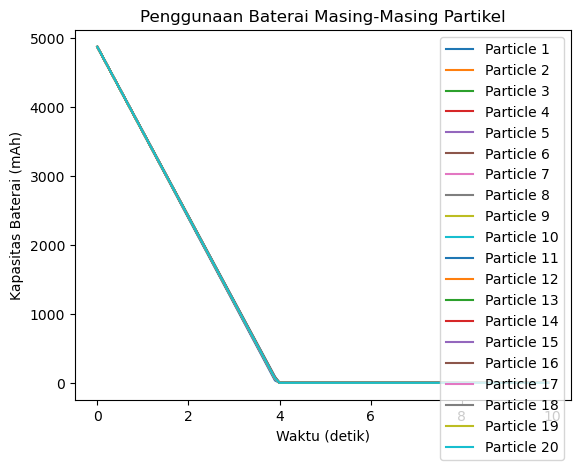

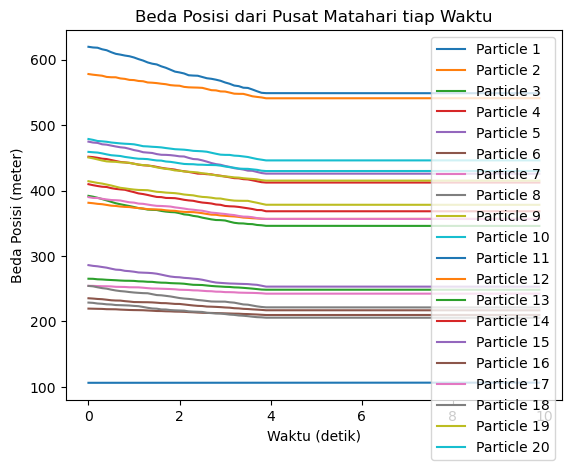

Posisi global terbaik: [417.37655981 433.0833392 ]
Kapasitas baterai akhir dan persentasenya: 
Drone 1: Kapasitas baterai = 0.0027620427988323155 mAh (5.524085597664631e-05%)
Drone 2: Kapasitas baterai = 0.0023995306509006567 mAh (4.7990613018013135e-05%)
Drone 3: Kapasitas baterai = 0.0026164428733562437 mAh (5.232885746712487e-05%)
Drone 4: Kapasitas baterai = 0.0025515598286098016 mAh (5.103119657219603e-05%)
Drone 5: Kapasitas baterai = 0.0026901620243010064 mAh (5.380324048602012e-05%)
Drone 6: Kapasitas baterai = 0.0027131220515242784 mAh (5.4262441030485566e-05%)
Drone 7: Kapasitas baterai = 0.002697276960552095 mAh (5.3945539211041905e-05%)
Drone 8: Kapasitas baterai = 0.0027105253480972677 mAh (5.4210506961945355e-05%)
Drone 9: Kapasitas baterai = 0.002548455882152614 mAh (5.0969117643052275e-05%)
Drone 10: Kapasitas baterai = 0.0025147253423492104 mAh (5.0294506846984206e-05%)
Drone 11: Kapasitas baterai = 0.0023896747999475115 mAh (4.7793495998950226e-05%)
Drone 12: Kapasita

In [13]:
import os
import numpy as np
import matplotlib.pyplot as plt

def gauss_sun_intensity(x, y, sun_center, sun_std_dev):
    """Intensitas Gaussian berdasarkan jarak dari titik tengah."""
    return np.exp(-((x - sun_center[0])**2 + (y - sun_center[1])**2) / (2 * sun_std_dev**2))

def fitness_function(pos, sun_center, sun_std_dev, particles, index, min_distance, repulsion_factor):
    """Fitness function untuk memaksimalkan intensitas cahaya dan meminimalkan repulsi."""
    sun_intensity = gauss_sun_intensity(pos[0], pos[1], sun_center, sun_std_dev)

    repulsion = 0
    for j in range(len(particles)):
        if j != index:
            distance = np.linalg.norm(pos - particles[j])
            if distance < min_distance:
                repulsion += repulsion_factor / distance**2

    fitness = -sun_intensity + repulsion
    return fitness

def calculate_energy_consumption(mass, altitude, horizontal_distance, battery_voltage):
    """Menghitung parameter energi dari setiap drone."""
    drag_coefficient = 0.5
    frontal_area = 0.1  
    air_density = 1.225  
    horizontal_speed = 10.0  
    flight_efficiency = 0.8

    E_vertical_J = mass * 9.81 * altitude
    P_drag = 0.5 * drag_coefficient * frontal_area * air_density * horizontal_speed**2
    P_horizontal = (P_drag + mass * 9.81 * horizontal_speed) / flight_efficiency
    E_horizontal_J = P_horizontal * (horizontal_distance / horizontal_speed)
    E_total_J = E_vertical_J + E_horizontal_J
    E_total_Wh = E_total_J / 3600
    energy_consumed = (E_total_Wh * 1000) / battery_voltage
    return energy_consumed

def pso_drone_solar_chaser_with_battery():
    num_particles = 20
    num_iterations = 100
    dim = 2  
    c1 = 1.0
    c2 = 0.1  
    w = 0.1  
    timestep = 0.1  # seconds
    L = 1000  # meters

    drone_mass = 2.5 # massa baterai + massa panel surya (massa baterai yang dipakai yaitu variasi 7 kg dan massa panel surya variasi 5, 15, 30 ) 
    battery_capacity = 5000  
    solar_charge_rate = 100  
    altitude = 200  
    battery_voltage = 11.1  

    sun_center = np.array([L / 2, L / 2])  
    sun_std_dev = 1000  
    sun_speed = 1000 / 28800  # 1 km per 8 jam dalam meters per second

    min_distance = 3  
    repulsion_factor = 1000  

    particles = np.random.rand(num_particles, dim) * L  
    velocities = np.zeros((num_particles, dim))  
    personal_best_positions = particles.copy()
    global_best_position = particles[0, :].copy()
    global_best_fitness = float('inf')

    battery_levels = battery_capacity * np.ones(num_particles)  

    battery_levels_over_time = np.zeros((num_iterations, num_particles))
    position_diff_over_time = np.zeros((num_iterations, num_particles))

    # Folder untuk menyimpan hasil program
    folder_name = "Percobaan_c1_c2_w"
    if not os.path.exists(folder_name):
        os.makedirs(folder_name)

    for iter in range(num_iterations):
        for i in range(num_particles):
            fitness = fitness_function(particles[i, :], sun_center, sun_std_dev, particles, i, min_distance, repulsion_factor)
            if fitness < fitness_function(personal_best_positions[i, :], sun_center, sun_std_dev, particles, i, min_distance, repulsion_factor):
                personal_best_positions[i, :] = particles[i, :]
            if fitness < global_best_fitness:
                global_best_fitness = fitness
                global_best_position = particles[i, :]

        for i in range(num_particles):
            velocities[i, :] = (w * velocities[i, :] +
                                c1 * np.random.rand() * (personal_best_positions[i, :] - particles[i, :]) +
                                c2 * np.random.rand() * (global_best_position - particles[i, :]) / drone_mass * timestep)
            new_position = particles[i, :] + velocities[i, :]  
            new_position = np.clip(new_position, 0, L)
            horizontal_distance = np.linalg.norm(new_position - particles[i, :])
            energy_consumed = calculate_energy_consumption(drone_mass, altitude, horizontal_distance, battery_voltage)
            battery_levels[i] -= energy_consumed
            if battery_levels[i] > 0:
                particles[i, :] = new_position
            else:
                battery_levels[i] = 0

        for i in range(num_particles):
            solar_energy = (solar_charge_rate * 
                            max(0, gauss_sun_intensity(particles[i, 0], particles[i, 1], sun_center, sun_std_dev)) * 
                            timestep / 3600)
            battery_levels[i] = min(battery_levels[i] + solar_energy, battery_capacity)

        battery_levels_over_time[iter, :] = battery_levels
        position_diff_over_time[iter, :] = np.linalg.norm(particles - sun_center, axis=1)

        sun_center[0] += sun_speed * timestep  

        if sun_center[0] > L:
            sun_center[0] = 0

        X, Y = np.meshgrid(np.arange(0, L+1, 10), np.arange(0, L+1, 10))  
        Z = np.array([[gauss_sun_intensity(x, y, sun_center, sun_std_dev) for x in np.arange(0, L+1, 10)] for y in np.arange(0, L+1, 10)])
        
        plt.contourf(X, Y, Z)  
        plt.colorbar()
        plt.clim(0, 1)
        plt.title('Distribusi Matahari')
        plt.plot(particles[:, 0], particles[:, 1], '.r')
        plt.savefig(f'{folder_name}/frame_{iter+1}.png')  
        plt.clf()

        print(f'Iterasi ke-{iter + 1}: Global Best Fitness = {global_best_fitness}')

    time = np.arange(num_iterations) * timestep 
    
    plt.figure()
    for i in range(num_particles):
        plt.plot(time, battery_levels_over_time[:, i], label=f'Particle {i+1}')
    plt.title('Penggunaan Baterai Masing-Masing Partikel')
    plt.xlabel('Waktu (detik)')
    plt.ylabel('Kapasitas Baterai (mAh)')
    plt.legend(loc='best')
    plt.savefig(f'{folder_name}/Kapasitas Baterai Tiap Waktu.png')  
    plt.show()
    
    plt.figure()
    for i in range(num_particles):
        plt.plot(time, position_diff_over_time[:, i], label=f'Particle {i+1}')
    plt.title('Beda Posisi dari Pusat Matahari tiap Waktu')
    plt.xlabel('Waktu (detik)')
    plt.ylabel('Beda Posisi (meter)')
    plt.legend(loc='best')
    plt.savefig(f'{folder_name}/beda_posisi tiap waktu.png')  
    plt.show()

    print(f'Posisi global terbaik: {global_best_position}')
    print('Kapasitas baterai akhir dan persentasenya: ')
    for i in range(num_particles):
        battery_percentage = (battery_levels[i] / battery_capacity) * 100
        print(f'Drone {i + 1}: Kapasitas baterai = {battery_levels[i]} mAh ({battery_percentage}%)')

if __name__ == "__main__":
    pso_drone_solar_chaser_with_battery()


Variasi drone jenis T-Drones MX860 dengan massa 15 kg dan kapasitas 60000 mAh

Iterasi ke-1: Global Best Fitness = -0.9969291080871331
Iterasi ke-2: Global Best Fitness = -0.9969293719611874
Iterasi ke-3: Global Best Fitness = -0.9969296358232921
Iterasi ke-4: Global Best Fitness = -0.9969298996734474
Iterasi ke-5: Global Best Fitness = -0.9969301635116532
Iterasi ke-6: Global Best Fitness = -0.9969304273379095
Iterasi ke-7: Global Best Fitness = -0.9969306911522162
Iterasi ke-8: Global Best Fitness = -0.9969309549545735
Iterasi ke-9: Global Best Fitness = -0.9969312187449813
Iterasi ke-10: Global Best Fitness = -0.9969314825234395
Iterasi ke-11: Global Best Fitness = -0.9969317462899482
Iterasi ke-12: Global Best Fitness = -0.9969320100445074
Iterasi ke-13: Global Best Fitness = -0.9969322737871169
Iterasi ke-14: Global Best Fitness = -0.9969325375177769
Iterasi ke-15: Global Best Fitness = -0.9969328012364873
Iterasi ke-16: Global Best Fitness = -0.9969330649432482
Iterasi ke-17: Global Best Fitness = -0.9969333286380594
Iterasi ke-18: Global Best Fitness = -0.

<Figure size 640x480 with 0 Axes>

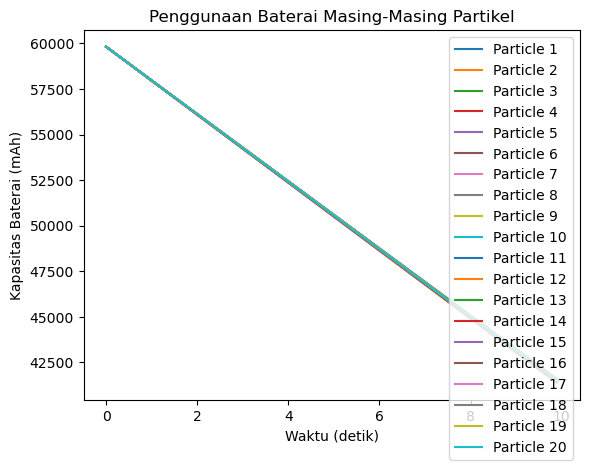

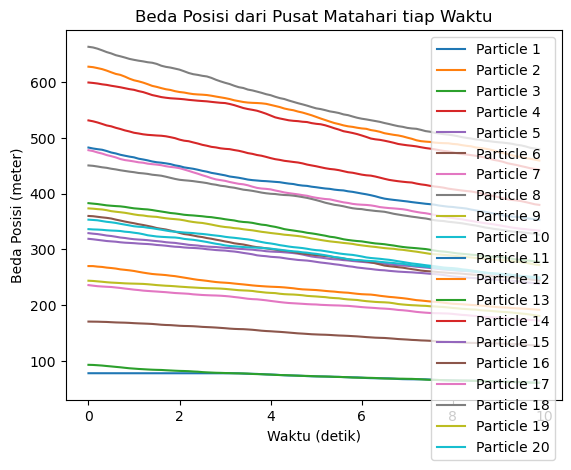

Posisi global terbaik: [439.78493786 510.36124544]
Kapasitas baterai akhir dan persentasenya: 
Drone 1: Kapasitas baterai = 41568.7340527349 mAh (69.28122342122484%)
Drone 2: Kapasitas baterai = 41495.79487929137 mAh (69.15965813215227%)
Drone 3: Kapasitas baterai = 41466.24412596954 mAh (69.1104068766159%)
Drone 4: Kapasitas baterai = 41406.96122549651 mAh (69.01160204249418%)
Drone 5: Kapasitas baterai = 41490.789058170754 mAh (69.15131509695127%)
Drone 6: Kapasitas baterai = 41453.98689410811 mAh (69.08997815684684%)
Drone 7: Kapasitas baterai = 41420.40817497553 mAh (69.03401362495921%)
Drone 8: Kapasitas baterai = 41375.05690592198 mAh (68.95842817653663%)
Drone 9: Kapasitas baterai = 41469.111016554496 mAh (69.11518502759083%)
Drone 10: Kapasitas baterai = 41466.81360359054 mAh (69.11135600598423%)
Drone 11: Kapasitas baterai = 41437.47016363832 mAh (69.06245027273053%)
Drone 12: Kapasitas baterai = 41392.275934331374 mAh (68.98712655721896%)
Drone 13: Kapasitas baterai = 41550.6

In [1]:
import os
import numpy as np
import matplotlib.pyplot as plt

def gauss_sun_intensity(x, y, sun_center, sun_std_dev):
    """Intensitas Gaussian berdasarkan jarak dari titik tengah."""
    return np.exp(-((x - sun_center[0])**2 + (y - sun_center[1])**2) / (2 * sun_std_dev**2))

def fitness_function(pos, sun_center, sun_std_dev, particles, index, min_distance, repulsion_factor):
    """Fitness function untuk memaksimalkan intensitas cahaya dan meminimalkan repulsi."""
    sun_intensity = gauss_sun_intensity(pos[0], pos[1], sun_center, sun_std_dev)

    repulsion = 0
    for j in range(len(particles)):
        if j != index:
            distance = np.linalg.norm(pos - particles[j])
            if distance < min_distance:
                repulsion += repulsion_factor / distance**2

    fitness = -sun_intensity + repulsion
    return fitness

def calculate_energy_consumption(mass, altitude, horizontal_distance, battery_voltage):
    """Menghitung parameter energi dari setiap drone."""
    drag_coefficient = 0.5
    frontal_area = 0.1  
    air_density = 1.225  
    horizontal_speed = 10.0  
    flight_efficiency = 0.8

    E_vertical_J = mass * 9.81 * altitude
    P_drag = 0.5 * drag_coefficient * frontal_area * air_density * horizontal_speed**2
    P_horizontal = (P_drag + mass * 9.81 * horizontal_speed) / flight_efficiency
    E_horizontal_J = P_horizontal * (horizontal_distance / horizontal_speed)
    E_total_J = E_vertical_J + E_horizontal_J
    E_total_Wh = E_total_J / 3600
    energy_consumed = (E_total_Wh * 1000) / battery_voltage
    return energy_consumed

def pso_drone_solar_chaser_with_battery():
    num_particles = 20
    num_iterations = 100
    dim = 2  
    c1 = 1.0
    c2 = 0.5  
    w = 0.5  
    timestep = 0.1  # seconds
    L = 1000  # meters

    drone_mass = 15 # massa baterai + massa panel surya (massa baterai yang dipakai yaitu variasi 7 kg dan massa panel surya variasi 5, 15, 30 ) 
    battery_capacity = 60000  
    solar_charge_rate = 100  
    altitude = 200  
    battery_voltage = 44.4  

    sun_center = np.array([L / 2, L / 2])  
    sun_std_dev = 1000  
    sun_speed = 1000 / 28800  # 1 km per 8 jam dalam meters per second

    min_distance = 3  
    repulsion_factor = 1000  

    particles = np.random.rand(num_particles, dim) * L  
    velocities = np.zeros((num_particles, dim))  
    personal_best_positions = particles.copy()
    global_best_position = particles[0, :].copy()
    global_best_fitness = float('inf')

    battery_levels = battery_capacity * np.ones(num_particles)  

    battery_levels_over_time = np.zeros((num_iterations, num_particles))
    position_diff_over_time = np.zeros((num_iterations, num_particles))

    # Folder untuk menyimpan hasil program
    folder_name = "Percobaan_T-Drones MX860"
    if not os.path.exists(folder_name):
        os.makedirs(folder_name)

    for iter in range(num_iterations):
        for i in range(num_particles):
            fitness = fitness_function(particles[i, :], sun_center, sun_std_dev, particles, i, min_distance, repulsion_factor)
            if fitness < fitness_function(personal_best_positions[i, :], sun_center, sun_std_dev, particles, i, min_distance, repulsion_factor):
                personal_best_positions[i, :] = particles[i, :]
            if fitness < global_best_fitness:
                global_best_fitness = fitness
                global_best_position = particles[i, :]

        for i in range(num_particles):
            velocities[i, :] = (w * velocities[i, :] +
                                c1 * np.random.rand() * (personal_best_positions[i, :] - particles[i, :]) +
                                c2 * np.random.rand() * (global_best_position - particles[i, :]) / drone_mass * timestep)
            new_position = particles[i, :] + velocities[i, :]  
            new_position = np.clip(new_position, 0, L)
            horizontal_distance = np.linalg.norm(new_position - particles[i, :])
            energy_consumed = calculate_energy_consumption(drone_mass, altitude, horizontal_distance, battery_voltage)
            battery_levels[i] -= energy_consumed
            if battery_levels[i] > 0:
                particles[i, :] = new_position
            else:
                battery_levels[i] = 0

        for i in range(num_particles):
            solar_energy = (solar_charge_rate * 
                            max(0, gauss_sun_intensity(particles[i, 0], particles[i, 1], sun_center, sun_std_dev)) * 
                            timestep / 3600)
            battery_levels[i] = min(battery_levels[i] + solar_energy, battery_capacity)

        battery_levels_over_time[iter, :] = battery_levels
        position_diff_over_time[iter, :] = np.linalg.norm(particles - sun_center, axis=1)

        sun_center[0] += sun_speed * timestep  

        if sun_center[0] > L:
            sun_center[0] = 0

        X, Y = np.meshgrid(np.arange(0, L+1, 10), np.arange(0, L+1, 10))  
        Z = np.array([[gauss_sun_intensity(x, y, sun_center, sun_std_dev) for x in np.arange(0, L+1, 10)] for y in np.arange(0, L+1, 10)])
        
        plt.contourf(X, Y, Z)  
        plt.colorbar()
        plt.clim(0, 1)
        plt.title('Distribusi Matahari')
        plt.plot(particles[:, 0], particles[:, 1], '.r')
        plt.savefig(f'{folder_name}/frame_{iter+1}.png')  
        plt.clf()

        print(f'Iterasi ke-{iter + 1}: Global Best Fitness = {global_best_fitness}')

    time = np.arange(num_iterations) * timestep 
    
    plt.figure()
    for i in range(num_particles):
        plt.plot(time, battery_levels_over_time[:, i], label=f'Particle {i+1}')
    plt.title('Penggunaan Baterai Masing-Masing Partikel')
    plt.xlabel('Waktu (detik)')
    plt.ylabel('Kapasitas Baterai (mAh)')
    plt.legend(loc='best')
    plt.savefig(f'{folder_name}/Kapasitas Baterai Tiap Waktu.png')  
    plt.show()
    
    plt.figure()
    for i in range(num_particles):
        plt.plot(time, position_diff_over_time[:, i], label=f'Particle {i+1}')
    plt.title('Beda Posisi dari Pusat Matahari tiap Waktu')
    plt.xlabel('Waktu (detik)')
    plt.ylabel('Beda Posisi (meter)')
    plt.legend(loc='best')
    plt.savefig(f'{folder_name}/beda_posisi tiap waktu.png')  
    plt.show()

    print(f'Posisi global terbaik: {global_best_position}')
    print('Kapasitas baterai akhir dan persentasenya: ')
    for i in range(num_particles):
        battery_percentage = (battery_levels[i] / battery_capacity) * 100
        print(f'Drone {i + 1}: Kapasitas baterai = {battery_levels[i]} mAh ({battery_percentage}%)')

if __name__ == "__main__":
    pso_drone_solar_chaser_with_battery()
